# FOL-Triage: screening a three-layer, gold-free checker for NL→FOL translations

This notebook is a runnable demo of **experiment A (iteration 1)**: a *wide screen* of **FOL-Triage**, a checker that
predicts whether a candidate first-order-logic (FOL) formula is faithful to its English sentence **without a gold
formula, ontology or domain knowledge**. The checker has three layers, fused by a logistic regression:

| layer | function | what it measures | cost |
|---|---|---|---|
| **L1** lint | `fol_lint(fol)` | text-free formula *smells* (∃x(A→B), ∀x(A∧B), free/dangling variables, vacuous predicates, valid/unsat formulas via z3, arity clashes) | CPU |
| **L2-bow** | `content_accounting(text, fol)` | predicates no text word anchors (ADD) and text content words no predicate carries (DROP) | CPU |
| **L2-role** | `role_accounting(text, fol)` | spaCy roles of text words (condition / asserted / exception, negation) vs the **exact z3 monotonicity** of the predicates they align to; argument order of binary predicates | CPU |
| **L3** | `role_questionnaire` + `formula_role_profile` + `l3_compare` | a small LLM reads **only the sentence** and fills a frozen schema (concepts, role, polarity, quantifier force, claims); z3 answers the same questions **exactly** on the formula; per-field mismatch | ≈ $0.0002 / sentence |

**Data (the frozen shared screen).** *Track L* = real Logic-LM outputs of gpt-3.5-turbo / gpt-4 / text-davinci-003 on
FOLIO-dev, labelled CORRECT / ERROR / UNCERTAIN / UNPARSEABLE by prover-checked equivalence to the *corrected* gold of
the DSAVlab curated FOLIO release. *Track H* = the curated original gold vs its corrected version (human errors).
*HREF* = the corrected gold used as its own candidate (known-correct). The fusion model is fitted on track H + HREF with a
sentence-leak guard and frozen in `prereg.json` **before** any track-L label is looked at.

**Full-run headline (753 track-L items, 477 in the primary ERROR-vs-CORRECT set):** fused AUROC **0.759**
[0.695, 0.825]; L2-bow 0.737; L3 0.756; L2-role 0.557; L1 0.508 (lint does not transfer to LLM outputs). The
rewrite-false-alarm gate fails (0.275), and 59% of the ERROR labels are pure vocabulary substitutions (ADD+DROP).

**What this demo does.** It runs the *original* `method.py` stages 3–7 (CPU layers → pre-registration → calibration →
scoring with labels hidden → invariance → decomposed-judge ablation → contamination check → analysis) on a curated
**97-item subset** (46 track-L, 31 track-H, 20 HREF) plus 75 meaning-preserving rewrite rows (40 of which apply). The LLM calls
(gemini-2.5-flash-lite, qwen3-30b, the local Qwen2.5-1.5B fallback) are replayed from the run's response cache shipped in
`mini_demo_data.json`, so **no API key is needed**. All z3 / spaCy / WordNet computations run live. With ~40 items, the
AUROCs below are noisy illustrations, not the paper's numbers.

In [1]:
%%capture
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# z3-solver, loguru, spaCy English model — NOT pre-installed on Colab, always install
_pip('z3-solver==5.1.0.0', 'loguru==0.7.3')
_pip('https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl')

# numpy, pandas, sklearn, scipy, matplotlib, nltk, spacy, aiohttp — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0',
         'nltk==3.9.1', 'spacy==3.8.11', 'aiohttp==3.13.3')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports
The original `method.py` import block, unchanged, plus `os`/`shutil` and matplotlib for the notebook's data set-up and
final plots.

In [2]:
from __future__ import annotations

import asyncio
import hashlib
import json
import math
import pickle
import resource
import sys
import time
from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
from loguru import logger

# notebook additions
import os
import shutil
import matplotlib.pyplot as plt

## Load the demo data
`mini_demo_data.json` holds the curated screen subset (`screen_items` with their labels, `href_items`,
`invariance_set`, `screen_meta`) and `llm_cache`, the cached LLM responses for exactly the calls this subset needs.
It is fetched from GitHub, with a local-file fallback.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_Jhw6i0bFXdo3/round-1/experiment-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print({k: len(v) for k, v in data.items() if isinstance(v, list)})
print(Counter((x["track"], x["label"]) for x in data["screen_items"]))

{'screen_items': 77, 'href_items': 20, 'invariance_set': 75, 'llm_cache': 331}
Counter({('L', 'ERROR'): 20, ('L', 'CORRECT'): 20, ('H', 'CORRECT'): 17, ('H', 'ERROR'): 10, ('L', 'UNCERTAIN'): 4, ('H', 'UNCERTAIN'): 3, ('L', 'UNPARSEABLE'): 2, ('H', 'UNPARSEABLE'): 1})


## Configuration
All tunable parameters. The original run used the whole screen (753 track-L + 302 track-H items, 302 HREF, 750
rewrites) and `B_BOOT = 2000` cluster-bootstrap resamples; the demo data holds 46 / 31 / 20 items. The `N_*` values take
the first N items of each track from the demo file (the demo file's order interleaves labels).

In [5]:
N_L = 46          # track-L items (Logic-LM outputs) to score; demo file holds 46 (original: 753)
N_H = 31          # track-H items (original human gold vs corrected); demo file holds 31 (original: 302)
N_HREF = 20       # HREF items (corrected gold as candidate); demo file holds 20 (original: 302)
B_BOOT = 2000      # sentence-clustered bootstrap resamples in the analysis (original: 2000)
LLM_LIVE = "0"   # "0" = replay the cached LLM answers; "1" = call OpenRouter live (needs OPENROUTER_API_KEY, costs money)

## The released functions and pipeline modules (verbatim copies of `src/*.py`)
`method.py` imports its layers from the artifact's `src/` package. The next cells write those files, **unchanged**,
into `fol_triage_run/src/` so that the imports (and the spawn-based worker processes of the CPU stage) work exactly as in
the original repository:

- `fol.py` — FOL parser (∀ ∃ ¬ ∧ ∨ → ↔ ⊕), z3 translation, validity / monotonicity profile, equivalence.
- `lint_smells.py` — the L1 smell detectors.
- `content_accounting.py` — the L2 bag-of-words accounting (Porter stems + WordNet links).
- `fol_triage.py` — **the released API**: `fol_lint`, `content_accounting`, `role_accounting`, `formula_role_profile`,
  `role_questionnaire`, `l3_compare`, `l3_score`, the decomposed-judge prompt and the error-code map.
- `llm.py` — OpenRouter client with a persistent response cache (`CachedLLM` replays it).
- `pipeline.py` — label-free scoring view, cached/parallel CPU layers, async questionnaire runners.
- `screen.py` — screen construction (only `norm` is used here).
- `disguise.py` — nonce-word disguise of sentence and formula for the contamination check.
- `analysis.py`, `output.py` — STAGE 7: the only place labels are joined to scores; metrics and `method_out.json`.

In [6]:
Path("fol_triage_run/src").mkdir(parents=True, exist_ok=True)

In [7]:
%%writefile fol_triage_run/src/fol.py
"""Unicode FOL (FOLIO/MALLS notation) -> AST -> z3; semantic monotonicity profile per predicate.

Grammar (lowest to highest precedence): ↔  <  →  <  ∨ / ⊕  <  ∧  <  ¬, quantifiers, atoms.
A quantifier binds the immediately following parenthesised group, atom, negation or quantifier
(FOLIO/MALLS convention: '∀x (A(x)) ∧ ∀y (B(y))' is two sentences).
"""
import re
import z3

TOK = re.compile(r"\s*(∀|∃|¬|∧|∨|→|↔|⊕|\(|\)|,|[A-Za-z_][A-Za-z0-9_'\-]*)")
OPS = {"↔": "iff", "⊕": "xor", "→": "imp", "∨": "or", "∧": "and"}
# PRECEDENCE_FIX (iter-1 exp A): iter-3 had xor=1 (below ->), which mis-bracketed "A ⊕ B → C".
# ⊕ now binds like ∨, tighter than →.
PREC = {"iff": 1, "imp": 2, "xor": 3, "or": 3, "and": 4}


def tokenize(s: str) -> list[str]:
    s = s.replace("⇒", "→").replace("->", "→").replace("<->", "↔").replace("&", "∧").replace("|", "∨")
    s = s.replace("~", "¬").replace("!", "¬").replace("¬", "¬").replace("−", "-")
    pos, out = 0, []
    s = s.strip().rstrip(".")
    while pos < len(s):
        m = TOK.match(s, pos)
        if not m:
            raise ValueError(f"bad char at {pos}: {s[pos:pos+10]!r}")
        out.append(m.group(1))
        pos = m.end()
        while pos < len(s) and s[pos].isspace():
            pos += 1
    return out


class Parser:
    def __init__(self, s: str):
        self.t = tokenize(s)
        self.i = 0

    def peek(self):
        return self.t[self.i] if self.i < len(self.t) else None

    def eat(self, x=None):
        tok = self.peek()
        if x is not None and tok != x:
            raise ValueError(f"expected {x} got {tok}")
        self.i += 1
        return tok

    def parse(self):
        e = self.expr(0)
        if self.peek() is not None:
            raise ValueError(f"trailing {self.t[self.i:]}")
        return e

    def expr(self, minp):
        lhs = self.unary()
        while self.peek() in OPS and PREC[OPS[self.peek()]] > minp - 1 and PREC[OPS[self.peek()]] >= minp:
            op = OPS[self.eat()]
            # → is right-assoc, others left-assoc
            nxt = PREC[op] if op == "imp" else PREC[op] + 1
            rhs = self.expr(nxt)
            lhs = (op, lhs, rhs)
        return lhs

    def unary(self):
        tok = self.peek()
        if tok == "¬":
            self.eat()
            return ("not", self.unary())
        if tok in ("∀", "∃"):
            self.eat()
            vs = [self.eat()]
            while self.peek() not in ("(", "¬", "∀", "∃") and self.peek() is not None and re.match(r"^[a-z][a-z0-9]*$", self.peek() or "") and not self._is_atom_start():
                vs.append(self.eat())
            body = self.unary()  # FOLIO/MALLS convention: a quantifier binds the next group/atom/quantifier
            for v in reversed(vs):
                body = ("all" if tok == "∀" else "ex", v, body)
            return body
        if tok == "(":
            self.eat("(")
            e = self.expr(0)
            self.eat(")")
            return e
        name = self.eat()
        if self.peek() == "(":
            self.eat("(")
            args = [self.eat()]
            while self.peek() == ",":
                self.eat(",")
                args.append(self.eat())
            self.eat(")")
            return ("atom", name, tuple(args))
        return ("atom", name, ())  # propositional atom

    def _is_atom_start(self):
        return self.i + 1 < len(self.t) and self.t[self.i + 1] == "("


def parse(s: str):
    return Parser(s).parse()


def preds(e, acc=None):
    acc = {} if acc is None else acc
    if e[0] == "atom":
        acc[f"{e[1]}/{len(e[2])}"] = len(e[2])  # key by name/arity: arity clashes are distinct symbols
    elif e[0] in ("all", "ex"):
        preds(e[2], acc)
    elif e[0] == "not":
        preds(e[1], acc)
    else:
        preds(e[1], acc)
        preds(e[2], acc)
    return acc


U = z3.DeclareSort("U")


def to_z3(e, env, P):
    k = e[0]
    if k in ("all", "ex"):
        v = z3.Const(e[1], U)
        env2 = dict(env)
        env2[e[1]] = v
        b = to_z3(e[2], env2, P)
        return z3.ForAll([v], b) if k == "all" else z3.Exists([v], b)
    if k == "not":
        return z3.Not(to_z3(e[1], env, P))
    if k == "atom":
        args = [env.get(a, z3.Const("c_" + a, U)) for a in e[2]]
        f = P[f"{e[1]}/{len(e[2])}"]
        return f(*args) if args else f
    a, b = to_z3(e[1], env, P), to_z3(e[2], env, P)
    return {"and": lambda: z3.And(a, b), "or": lambda: z3.Or(a, b), "imp": lambda: z3.Implies(a, b),
            "iff": lambda: a == b, "xor": lambda: z3.Xor(a, b)}[k]()


def mkpred(name, n):
    name = name.replace("/", "_a")
    return z3.Function(name, *([U] * n), z3.BoolSort()) if n else z3.Bool(name)


def valid(c, ms=3000):
    s = z3.Solver()
    s.set("timeout", ms)
    s.add(z3.Not(c))
    r = s.check()
    return True if r == z3.unsat else (False if r == z3.sat else None)


def profile(e, ms=3000):
    """Semantic monotonicity of formula e in each predicate: UP / DOWN / VACUOUS / NONMONO / UNKNOWN."""
    ar = preds(e)
    base = {q: mkpred(q, m) for q, m in ar.items()}
    out = {}
    for p, n in ar.items():
        alt = dict(base)
        alt[p] = mkpred(p + "_prime", n)
        xs = [z3.Const(f"_x{i}", U) for i in range(n)]
        sub = z3.ForAll(xs, z3.Implies(base[p](*xs), alt[p](*xs))) if n else z3.Implies(base[p], alt[p])
        F, Fp = to_z3(e, {}, base), to_z3(e, {}, alt)
        up, down = valid(z3.Implies(z3.And(sub, F), Fp), ms), valid(z3.Implies(z3.And(sub, Fp), F), ms)
        if up is None or down is None:
            out[p] = "UNKNOWN"
        else:
            out[p] = {(True, True): "VACUOUS", (True, False): "UP", (False, True): "DOWN", (False, False): "NONMONO"}[(up, down)]
    return out


def equivalent(e1, e2, ms=5000):
    ar = {**preds(e1), **preds(e2)}
    P = {q: mkpred(q, m) for q, m in ar.items()}
    return valid(to_z3(e1, {}, P) == to_z3(e2, {}, P), ms)


def connectivity_flags(e):
    """Binding check: inside each quantifier scope, variables must be linked through shared atoms.
    Returns list of variables that are quantified but share no atom with any other variable in the
    same top-level sentence while other variables exist (an 'island')."""
    atoms = []

    def walk(x):
        if x[0] == "atom":
            atoms.append(set(a for a in x[2]))
        elif x[0] in ("all", "ex"):
            walk(x[2])
        elif x[0] == "not":
            walk(x[1])
        else:
            walk(x[1]); walk(x[2])

    def qvars(x, acc):
        if x[0] in ("all", "ex"):
            acc.append(x[1]); qvars(x[2], acc)
        elif x[0] == "not":
            qvars(x[1], acc)
        elif x[0] != "atom":
            qvars(x[1], acc); qvars(x[2], acc)
        return acc

    walk(e)
    vs = qvars(e, [])
    if len(vs) < 2:
        return []
    # union-find over variables via atoms
    parent = {v: v for v in vs}

    def f(v):
        while parent[v] != v:
            v = parent[v]
        return v
    for a in atoms:
        a = [v for v in a if v in parent]
        for v in a[1:]:
            parent[f(v)] = f(a[0])
    comps = {}
    for v in vs:
        comps.setdefault(f(v), []).append(v)
    if len(comps) == 1:
        return []
    main = max(comps.values(), key=len)
    return [v for c in comps.values() if c is not main for v in c]


def prenex_blocks(e):
    """Split a formula into top-level conjuncts; for each, collect its leading quantifier block."""
    parts = []

    def flat(x):
        if x[0] == "and":
            flat(x[1]); flat(x[2])
        else:
            parts.append(x)
    flat(e)
    return parts


def coupled_independent_vars(e):
    """GLUE check: within ONE top-level conjunct, >=2 universally quantified variables that never
    co-occur in any atom, i.e. independent generic claims wrongly bundled under a joint quantifier
    ('∀x∀y (Wolf(x) ∧ Bird(y) → Howls(x) ∧ Chirps(y))'). Returns True if any conjunct has one."""
    for part in prenex_blocks(e):
        if connectivity_flags(part):
            return True
    return False


def token_profile(prof):
    """Project a predicate-level polarity profile onto CamelCase word tokens, so that merged
    (WorksInNewsIndustryAndReportsOnEvents) and split (WorksInNewsIndustry ∧ ReportsOnEvents)
    renderings of the same concept get the same profile."""
    import re as _re
    STOP = {"and", "or", "of", "in", "on", "the", "a", "an", "to", "is", "has", "have", "can", "for", "with", "by", "at", "from"}
    out = {}
    for key, pol in prof.items():
        name = key.split("/")[0]
        for w in _re.findall(r"[A-Z]?[a-z]+|[A-Z]+(?![a-z])|\d+", name):
            w = w.lower()
            if w in STOP:
                continue
            w = w[:-1] if w.endswith("s") and len(w) > 3 else w
            out.setdefault(w, set()).add(pol)
    return out


BINSYM = {"iff": "↔", "xor": "⊕", "imp": "→", "or": "∨", "and": "∧"}


def to_str(e) -> str:
    """Fully parenthesised Unicode rendering of an AST; parse(to_str(e)) == e (round-trip tested)."""
    k = e[0]
    if k == "atom":
        return f"{e[1]}({', '.join(e[2])})" if e[2] else e[1]
    if k in ("all", "ex"):
        return f"{'∀' if k == 'all' else '∃'}{e[1]} ({to_str(e[2])})"
    if k == "not":
        return f"¬({to_str(e[1])})" if e[1][0] not in ("atom", "not") else f"¬{to_str(e[1])}"
    return f"({to_str(e[1])} {BINSYM[k]} {to_str(e[2])})"

Writing fol_triage_run/src/fol.py


In [8]:
%%writefile fol_triage_run/src/lint_smells.py
"""Step-0 probe: TEXT-FREE formula 'smells' (lint rules) on real errors vs verified-correct gold.

Idea (static analysis / bug-pattern mining, e.g. FindBugs, Getafix): some formulas are improbable renderings of ANY
English sentence, so they can be flagged without reading the text. Each smell is a deterministic check:
  EX_IMP      ∃x (A → B)                      existential with an implication body (almost always meant ∃x(A ∧ B))
  ALL_AND     ∀x (A(x) ∧ B(x)) with >=2 atoms  universal with a pure conjunction body (restriction→conjunction)
  IFF_RESTR   ∀x (A ∧ B ↔ C)                  biconditional whose left side is a conjunction: restrictor trapped in ↔
  GLUE        >=2 universal vars in one block that never share an atom (independent claims glued)
  FREE        free variable (lower-case single-letter argument not bound)
  VACUOUS     a predicate the formula's truth does not depend on (z3 monotonicity profile = VACUOUS; vacuity detection)
  TRIVIAL     formula is valid or unsatisfiable (z3)
  ARITY       same predicate name used with two arities
  DANGLING    a universally quantified variable that occurs in exactly one atom, in the consequent only
Reports firing rate on corrected (verified) gold = false alarms, and on ORIGINAL formulas of real non-equivalent pairs
(by repair-census class) = sensitivity; plus paired contrast (fires on original but not on corrected).
"""
import json
import re
import sys
from collections import Counter, defaultdict
from pathlib import Path

import z3

sys.path.insert(0, str(Path(__file__).resolve().parent))
from fol import parse, profile, connectivity_flags, prenex_blocks, to_z3, mkpred, preds, valid  # noqa: E402

D = Path(__file__).resolve().parent.parent / "data"


def walk(e, bv=frozenset(), parent=None):
    yield e, bv, parent
    k = e[0]
    if k in ("all", "ex"):
        yield from walk(e[2], bv | {e[1]}, e)
    elif k == "not":
        yield from walk(e[1], bv, e)
    elif k != "atom":
        yield from walk(e[1], bv, e)
        yield from walk(e[2], bv, e)


def natoms(e):
    return sum(1 for x, _, _ in walk(e) if x[0] == "atom")


def body_of(e):
    while e[0] in ("all", "ex"):
        e = e[2]
    return e


def smells(e):
    out = set()
    ar = defaultdict(set)
    for x, bv, par in walk(e):
        k = x[0]
        if k == "ex" and body_of(x)[0] == "imp":
            out.add("EX_IMP")
        if k == "all" and (par is None or par[0] != "all"):
            b = body_of(x)
            if b[0] == "and" and natoms(b) >= 2 and all(y[0] != "imp" for y, _, _ in walk(b)):
                out.add("ALL_AND")
            if b[0] == "iff" and b[1][0] == "and":
                out.add("IFF_RESTR")
        if k == "atom":
            ar[x[1]].add(len(x[2]))
            for a in x[2]:
                if re.fullmatch(r"[a-z]", a) and a not in bv:
                    out.add("FREE")
    if any(len(v) > 1 for v in ar.values()):
        out.add("ARITY")
    for part in prenex_blocks(e):
        vs, b = [], part
        while b[0] == "all":
            vs.append(b[1]); b = b[2]
        if len(vs) >= 2 and connectivity_flags(part):
            out.add("GLUE")
        if b[0] == "imp" and vs:
            ant = {a for y, _, _ in walk(b[1]) if y[0] == "atom" for a in y[2]}
            cnt = Counter(a for y, _, _ in walk(b) if y[0] == "atom" for a in y[2])
            if any(v not in ant and cnt[v] == 1 for v in vs):
                out.add("DANGLING")
    try:
        pr = profile(e, ms=1500)
        if any(v == "VACUOUS" for v in pr.values()):
            out.add("VACUOUS")
        P = {q: mkpred(q, m) for q, m in preds(e).items()}
        F = to_z3(e, {}, P)
        if valid(F, 1500) is True or valid(z3.Not(F), 1500) is True:
            out.add("TRIVIAL")
    except Exception:
        pass
    return out


def load(p):
    return [json.loads(l) for l in open(p) if l.strip()]


def items():
    for r in load(D / "DSAVlab-UNIUD_MALLS_test_subset-CURATED__MALLS_instances.jsonl"):
        yield "MALLS", r["id"], r["FOL_sentence_old"], r["FOL_sentence_new"]
    for r in load(D / "DSAVlab-UNIUD_FOLIO_validation-curated__FOLIO_instances.jsonl"):
        if not str(r["id"]).startswith("story"):
            yield "FOLIO-concl", r["id"], r["FOL_sentence_old"], r["FOL_sentence"]


def main():
    census = {(r["src"], r["id"]): r["cls"] for r in json.loads(Path(__file__).with_name("repair_census.rows.json").read_text())}
    fa, n_ok = Counter(), 0
    sens = defaultdict(Counter)
    nerr = Counter()
    for src, iid, old, new in items():
        try:
            ne = parse(new)
        except Exception:
            continue
        sn = smells(ne)
        n_ok += 1
        for s in sn:
            fa[s] += 1
        fa["ANY"] += bool(sn)
        cls = census.get((src, iid))
        if cls is None:
            continue
        g = "VOCAB/GRAN" if cls in ("VOCAB", "GRAN") else "ERROR"
        try:
            so = smells(parse(old))
        except Exception:
            continue
        nerr[g] += 1
        for s in so - sn:
            sens[g][s] += 1
        sens[g]["ANY(new smell on original, absent on corrected)"] += bool(so - sn)
        sens[g]["ANY(on original)"] += bool(so)
    print(f"verified-correct gold formulas: {n_ok}")
    for s, v in fa.most_common():
        print(f"  false-alarm {s:10s} {v:3d} ({v/n_ok:.3f})")
    for g in sens:
        print(f"== real non-equivalent pairs, class {g}: n={nerr[g]}")
        for s, v in sens[g].most_common():
            print(f"  {s:50s} {v:3d} ({v/nerr[g]:.2f})")


if __name__ == "__main__":
    sys.setrecursionlimit(10000)
    main()

Writing fol_triage_run/src/lint_smells.py


In [9]:
%%writefile fol_triage_run/src/content_accounting.py
"""Step-0 probe of CONTENT ACCOUNTING (text side of the COV invariant), run BEFORE any LLM output exists
(review critique 5 of iter 2).

content_accounting(text, fol) compares the text's content words with the word tokens projected from the formula's
predicate and constant names (CamelCase / snake split). Two alarms:
  ADD   an UNANCHORED predicate: none of its tokens matches a text content word (sortal/licensing policy: tokens
        in SORTAL = person/people/thing/entity/object/individual/human are licensed if the text has any animate or
        nominal subject, i.e. always licensed here; hedges and modals never need carrying).
  DROP  the share of text content words that no formula token carries.
Matching: EXACT (Porter stem) or LEX (stem, WordNet morphy lemma, synonyms and derivationally related forms).

Evaluation on curated FOLIO-conclusion + MALLS-test gold (arXiv 2606.02837):
  (1) false alarms on VERIFIED-CORRECT (corrected) gold, by number of predicates k;
  (2) PAIRED discrimination on the real non-equivalent (original, corrected) pairs: same text, erroneous vs correct
      formula; paired AUROC = P(score(original) > score(corrected)) + 0.5 P(tie), overall and by repair-census class.
"""
import json
import re
import sys
from collections import Counter, defaultdict
from pathlib import Path

import nltk
from nltk.stem import PorterStemmer

sys.path.insert(0, str(Path(__file__).resolve().parent))
from fol import parse  # noqa: E402

ROOT = Path(__file__).resolve().parent.parent
nltk.data.path.insert(0, str(ROOT / "nltk_data"))
from nltk.corpus import wordnet as wn  # noqa: E402

D = ROOT / "data"
PS = PorterStemmer()
TOKRE = re.compile(r"[A-Z]?[a-z]+|[A-Z]+(?![a-z])|\d+")
FUNC = set("""a an the and or but nor not no none neither either both all every each any some several many much more most
less least few if then else when whenever while whereas unless except only also too than that which who whom whose what where
is are was were be been being am do does did done has have had having can could may might must shall should will would of in
on at to for from by with without into onto over under about as it its they them their there this these those he she him her
his hers we us our you your i me my one ones such same other another own so very just often usually typically generally
sometimes always never also either neither something someone somebody anything anyone everything everyone thing things
be is s t""".split())
HEDGE = {"often", "usually", "typically", "generally", "sometimes", "can", "could", "may", "might", "likely", "probably",
         "tend", "tends", "mostly", "commonly", "frequently", "normally"}
SORTAL = {"person", "people", "thing", "entity", "object", "individual", "human", "someone", "something"}


def text_words(text):
    ws = re.findall(r"[A-Za-z]+|\d+", text)
    return [w.lower() for w in ws if w.lower() not in FUNC and w.lower() not in HEDGE and w.lower() not in SORTAL and len(w) > 1]


def name_words(name):
    return [w.lower() for w in TOKRE.findall(name.replace("_", " ")) if w.lower() not in FUNC and len(w) > 1]


_lex_cache = {}


def lex(w):
    """stem-level expansion of w: its stem, WordNet lemmas of its synsets, derivationally related forms."""
    if w in _lex_cache:
        return _lex_cache[w]
    out = {PS.stem(w)}
    for pos in ("n", "v", "a", "r"):
        m = wn.morphy(w, pos)
        if m:
            out.add(PS.stem(m))
    for s in wn.synsets(w)[:4]:
        for l in s.lemmas()[:6]:
            n = l.name().lower()
            if "_" not in n:
                out.add(PS.stem(n))
            for d in l.derivationally_related_forms()[:4]:
                if "_" not in d.name():
                    out.add(PS.stem(d.name().lower()))
    _lex_cache[w] = out
    return out


def symbols(e, acc=None, bv=frozenset()):
    acc = {"preds": set(), "consts": set()} if acc is None else acc
    k = e[0]
    if k == "atom":
        acc["preds"].add(e[1])
        for a in e[2]:
            if a not in bv:
                acc["consts"].add(a)
    elif k in ("all", "ex"):
        symbols(e[2], acc, bv | {e[1]})
    elif k == "not":
        symbols(e[1], acc, bv)
    else:
        symbols(e[1], acc, bv); symbols(e[2], acc, bv)
    return acc


def content_accounting(text, fol, mode="LEX"):
    """Returns {'n_unanchored': int, 'drop_share': float, 'k': #predicates, 'unanchored': [...], 'dropped': [...]}.
    Raises ValueError on an unparseable formula (callers count it as a coverage failure)."""
    e = parse(fol) if isinstance(fol, str) else fol
    sy = symbols(e)
    tw = text_words(text)
    tstem = {PS.stem(w) for w in tw}
    tlex = set().union(*[lex(w) for w in tw]) if (mode == "LEX" and tw) else set(tstem)
    ftoks = [w for n in sy["preds"] | sy["consts"] for w in name_words(n)]
    fstem = {PS.stem(w) for w in ftoks}
    flex = set().union(*[lex(w) for w in ftoks]) if (mode == "LEX" and ftoks) else set(fstem)
    unanch = []
    for p in sy["preds"]:
        ws = name_words(p)
        if not ws or any(w in SORTAL for w in ws):
            continue
        hit = any(PS.stem(w) in tstem or (mode == "LEX" and lex(w) & tstem) for w in ws)
        if not hit:
            unanch.append(p)
    dropped = [w for w in tw if not (PS.stem(w) in fstem or (mode == "LEX" and lex(w) & fstem))]
    return {"n_unanchored": len(unanch), "drop_share": len(dropped) / max(1, len(tw)), "k": len(sy["preds"]),
            "unanchored": unanch, "dropped": dropped}


def load(p):
    return [json.loads(l) for l in open(p) if l.strip()]


def items():
    for r in load(D / "DSAVlab-UNIUD_MALLS_test_subset-CURATED__MALLS_instances.jsonl"):
        yield "MALLS", r["id"], r["NL_sentence"], r["FOL_sentence_old"], r["FOL_sentence_new"]
    for r in load(D / "DSAVlab-UNIUD_FOLIO_validation-curated__FOLIO_instances.jsonl"):
        if not str(r["id"]).startswith("story"):
            yield "FOLIO-concl", r["id"], r["NL_sentence"], r["FOL_sentence_old"], r["FOL_sentence"]


def paired_auc(pairs):
    if not pairs:
        return float("nan")
    return sum(1.0 if a > b else 0.5 if a == b else 0.0 for a, b in pairs) / len(pairs)


def main():
    rows_p = Path(__file__).with_name("repair_census.rows.json")
    census = {(r["src"], r["id"]): r for r in json.loads(rows_p.read_text())} if rows_p.exists() else {}
    for mode in ("EXACT", "LEX"):
        fa = defaultdict(Counter)
        pairs = defaultdict(list)
        nfail = 0
        for src, iid, nl, old, new in items():
            try:
                cn = content_accounting(nl, new, mode)
            except Exception:
                nfail += 1
                continue
            kb = "k1-2" if cn["k"] <= 2 else "k3-4" if cn["k"] <= 4 else "k5+"
            for b in (kb, "all"):
                fa[b]["n"] += 1
                fa[b]["add_alarm"] += cn["n_unanchored"] >= 1
                fa[b]["drop>0.34"] += cn["drop_share"] > 0.34
                fa[b]["drop>0.20"] += cn["drop_share"] > 0.20
            c = census.get((src, iid))
            if not c:
                continue
            try:
                co = content_accounting(nl, old, mode)
            except Exception:
                continue
            cls = c["cls"]
            grp = ("VOCAB/GRAN" if cls in ("VOCAB", "GRAN") else
                   "COV-type(ADD/DROP)" if any(o in cls.split("+") for o in ("ADD", "DROP")) else
                   "COMPOUND" if cls == "COMPOUND" else "STRUCT/POL-type")
            sc_o = co["n_unanchored"] + co["drop_share"]
            sc_n = cn["n_unanchored"] + cn["drop_share"]
            for g in (grp, "all-errors" if grp != "VOCAB/GRAN" else "vocab-only"):
                pairs[g].append((sc_o, sc_n))
        print(f"== mode {mode}  (unparseable correct formulas counted, not dropped: {nfail})")
        for b in ("k1-2", "k3-4", "k5+", "all"):
            f = fa[b]
            n = max(1, f["n"])
            print(f"  false alarms on correct gold {b:5s} n={f['n']:3d}  ADD(any unanchored)={f['add_alarm']/n:.2f}  "
                  f"DROP>0.20={f['drop>0.20']/n:.2f}  DROP>0.34={f['drop>0.34']/n:.2f}")
        for g, ps in sorted(pairs.items()):
            print(f"  paired AUROC (original-error scored worse than corrected) {g:20s} n={len(ps):3d}  {paired_auc(ps):.2f}")


if __name__ == "__main__":
    sys.setrecursionlimit(10000)
    main()

Writing fol_triage_run/src/content_accounting.py


In [10]:
%%writefile fol_triage_run/src/fol_triage.py
"""FOL-Triage: a gold-free, three-layer faithfulness check for a (text, fol) pair.

Released functions (each takes the natural-language text and/or a candidate FOL formula; no gold, no ontology):

fol_lint(fol)                   L1  TEXT-FREE formula smells (frozen iter-3 list): improbable renderings of ANY English
                                    sentence -- EX_IMP ∃x(A→B), ALL_AND ∀x(A∧B), IFF_RESTR ∀x(A∧B↔C), GLUE (independent
                                    universal claims glued in one block), FREE variable, VACUOUS predicate (z3), TRIVIAL
                                    (valid/unsat, z3), ARITY clash, DANGLING universal variable.
content_accounting(text, fol)   L2-bow  bag-of-words baseline: predicates whose name no text word anchors (ADD) and the share
                                    of text content words no predicate/constant carries (DROP). Role-blind.
role_accounting(text, fol)      L2-role  role-aware accounting: spaCy dependency roles of text words (condition / asserted /
                                    exception, negation) must match the EXACT z3 monotonicity of the predicates they align
                                    to (condition->DOWN, asserted->UP, exception->UP, flipped by negation); plus
                                    subject/object slot order of binary predicates. Counts mismatches.
formula_role_profile(fol)       formula side of L3, answered EXACTLY: per predicate its z3 monotonicity, position,
                                    local negation, derived role, quantifier force, claim index and argument slots.
role_questionnaire(text, ...)   L3 text side: a small LLM reads ONLY the sentence and fills a frozen schema
                                    (concepts with role/negated/exception/force/claim; ordered relations).
l3_compare(q, profile)          per-field mismatch between the text questionnaire and a formula profile.
fol_triage(...)                 cascade L1 -> L2 -> L3 with a fused logistic p_error and an error-type code.
"""
from __future__ import annotations

import itertools
import json
import math
import re
import sys
from collections import Counter, defaultdict
from functools import lru_cache
from pathlib import Path

sys.setrecursionlimit(10000)
SRC = Path(__file__).resolve().parent
sys.path.insert(0, str(SRC))

import z3  # noqa: E402

from fol import parse, profile, preds, prenex_blocks, to_z3, mkpred, valid  # noqa: E402
import lint_smells  # noqa: E402
import content_accounting as ca  # noqa: E402

PS = ca.PS
LOGIC_WORDS = {"all", "every", "each", "any", "some", "no", "not", "none", "if", "then", "only", "unless", "except",
               "either", "or", "and", "neither", "nor", "both", "never", "always", "there", "exists"}


# =============================================================================================== L1
def fol_lint(fol: str) -> dict:
    """L1. Returns {'codes': sorted smell codes, 'parse_ok': bool, 'z3_unknown': bool}.
    Codes are the frozen iter-3 lint_smells.smells() output (verbatim); z3-dependent smells (VACUOUS, TRIVIAL) are
    re-checked at 1500 ms and, when z3 answers unknown or raises, z3_unknown=True (never silently absent)."""
    try:
        e = parse(fol) if isinstance(fol, str) else fol
    except Exception:  # noqa: BLE001
        return {"codes": [], "parse_ok": False, "z3_unknown": False}
    codes = sorted(lint_smells.smells(e))
    unk = False
    try:
        pr = profile(e, ms=1500)
        if any(v == "UNKNOWN" for v in pr.values()):
            unk = True
        P = {q: mkpred(q, m) for q, m in preds(e).items()}
        F = to_z3(e, {}, P)
        if valid(F, 1500) is None or valid(z3.Not(F), 1500) is None:
            unk = True
    except Exception:  # noqa: BLE001
        unk = True
    return {"codes": codes, "parse_ok": True, "z3_unknown": unk}


# =============================================================================================== L2 bag-of-words
def content_accounting(text: str, fol: str) -> dict:
    """L2-bow baseline (iter-3 code, LEX matching). flag iff >=1 unanchored predicate or uncarried share > 0.34."""
    r = ca.content_accounting(text, fol, mode="LEX")
    return {"uncarried_frac": r["drop_share"], "unanchored_preds": r["unanchored"], "n_unanchored": r["n_unanchored"],
            "n_content": len(ca.text_words(text)), "n_preds": r["k"],
            "flag": bool(r["n_unanchored"] >= 1 or r["drop_share"] > 0.34)}


# =============================================================================================== formula profile
def _occurrences(e):
    """Every atom occurrence with its syntactic context."""
    occ = []

    def go(x, ante, neg, qs, conj, under_all):
        k = x[0]
        if k == "atom":
            occ.append({"key": f"{x[1]}/{len(x[2])}", "name": x[1], "args": x[2], "ante": ante, "neg": neg, "qs": qs,
                        "conj": conj})
        elif k in ("all", "ex"):
            go(x[2], ante, neg, qs + ((x[1], k),), conj, under_all or k == "all")
        elif k == "not":
            go(x[1], ante, neg + 1, qs, conj, under_all)
        elif k == "imp":
            go(x[1], True, 0, qs, conj, under_all)
            go(x[2], ante, 0, qs, conj, under_all)
        elif k == "iff":
            go(x[1], True if under_all else ante, 0, qs, conj, under_all)
            go(x[2], ante, 0, qs, conj, under_all)
        else:
            go(x[1], ante, neg, qs, conj, under_all)
            go(x[2], ante, neg, qs, conj, under_all)
    for i, part in enumerate(prenex_blocks(e)):
        go(part, False, 0, (), i, False)
    return occ


def formula_role_profile(fol, ms: int = 3000, mono: dict | None = None) -> dict:
    """Formula side of L3, exact. -> {pred_key: {'mono','pos','local_neg','role','force','claim','slots'}}.
    mono: z3 monotonicity (UP / DOWN / NONMONO / VACUOUS / UNKNOWN) of the whole formula in that predicate.
    pos: 'antecedent' if any occurrence sits left of → (or left of ↔ under ∀), else 'consequent'.
    local_neg: odd number of explicit ¬ between the (first) occurrence and its antecedent/consequent root.
    role: DOWN&¬neg -> condition; UP&¬neg -> asserted; DOWN&neg -> negated-asserted; UP&neg -> negated-condition;
          NONMONO -> mixed; else unknown.
    force: quantifier of the outermost block binding an argument variable (all/some), 'named' if constant-only.
    claim: top-level conjunct index split into variable-connectivity components (int ids in order of appearance).
    slots: argument tuple; variables mapped to their restrictor predicate (unary predicate over that variable,
           antecedent occurrence preferred), constants kept as names."""
    e = parse(fol) if isinstance(fol, str) else fol
    if mono is None:
        mono = profile(e, ms=ms)
    occ = _occurrences(e)
    # claims: union-find over (conj, var) through shared atoms; constant-only atoms of a conjunct share one component
    parent = {}

    def f(a):
        while parent.setdefault(a, a) != a:
            a = parent[a]
        return a

    def u(a, b):
        parent[f(a)] = f(b)
    comp_of = []
    for o in occ:
        qv = {v for v, _ in o["qs"]}
        vs = [a for a in o["args"] if a in qv]
        nodes = [(o["conj"], v) for v in vs] or [(o["conj"], "#const")]
        for n in nodes[1:]:
            u(nodes[0], n)
        f(nodes[0])
        comp_of.append(nodes[0])
    claim_ids = {}
    restr = {}
    for o in occ:
        if len(o["args"]) == 1 and o["args"][0] in {v for v, _ in o["qs"]}:
            v = (o["conj"], o["args"][0])
            if v not in restr or (o["ante"] and not restr[v][1]):
                restr[v] = (o["name"], o["ante"])
    out = {}
    for o, c in zip(occ, comp_of):
        root = f(c)
        if root not in claim_ids:
            claim_ids[root] = len(claim_ids)
        k = o["key"]
        if k in out:
            out[k]["pos"] = "antecedent" if (o["ante"] or out[k]["pos"] == "antecedent") else "consequent"
            continue
        qv = [v for v, _ in o["qs"]]
        force = None
        for v, q in o["qs"]:
            if v in o["args"]:
                force = "all" if q == "all" else "some"
                break
        if force is None:
            force = "named" if o["args"] else "none"
        m = mono.get(k, "UNKNOWN")
        ln = o["neg"] % 2 == 1
        role = {("DOWN", False): "condition", ("UP", False): "asserted", ("DOWN", True): "negated-asserted",
                ("UP", True): "negated-condition"}.get((m, ln), "mixed" if m == "NONMONO" else "unknown")
        slots = []
        for a in o["args"]:
            if a in qv:
                r = restr.get((o["conj"], a))
                slots.append(("var", r[0] if r and r[0] != o["name"] else None))
            else:
                slots.append(("const", a))
        out[k] = {"mono": m, "pos": "antecedent" if o["ante"] else "consequent", "local_neg": ln, "role": role,
                  "force": force, "claim": claim_ids[root], "slots": slots, "name": o["name"], "arity": len(o["args"])}
    return out


# =============================================================================================== lexical alignment
@lru_cache(maxsize=None)
def name_words(name: str) -> tuple:
    return tuple(ca.name_words(name))


@lru_cache(maxsize=None)
def _lex(w: str) -> frozenset:
    return frozenset(ca.lex(w))


def word_match(w: str, pw: str, exact: bool = False) -> bool:
    """Text word w matches predicate-name word pw: same Porter stem (exact) or WordNet lemma/synonym/derivation."""
    sw, sp = PS.stem(w.lower()), PS.stem(pw.lower())
    if sw == sp:
        return True
    if exact:
        return False
    return sp in _lex(w.lower()) or sw in _lex(pw.lower())


def const_match(phrase_words: list[str], const: str) -> bool:
    c = re.sub(r"[^a-z0-9]", "", const.lower())
    p = re.sub(r"[^a-z0-9]", "", "".join(phrase_words).lower())
    if not c or not p:
        return False
    return c == p or (len(p) >= 3 and (c.startswith(p) or p.startswith(c) or p in c))


# =============================================================================================== L2 role-aware
_NLP = None


def nlp():
    global _NLP
    if _NLP is None:
        import spacy
        _NLP = spacy.load("en_core_web_sm")
    return _NLP


COND_MARKS = ("if", "when", "whenever", "once", "provided", "as long as", "in case", "assuming", "given that")
EXC_MARKS = ("unless", "except", "excluding", "without", "but not", "other than")
GENERIC_DETS = {"all", "every", "each", "any", "no"}
GENERIC_PRON = {"everyone", "anyone", "everybody", "anybody", "everything", "anything", "nobody", "whoever", "those"}
NEG_WORDS = {"not", "n't", "never", "no", "none", "nobody", "nothing", "neither", "nor", "cannot"}


def _clause_head(t):
    x = t
    while x.dep_ not in ("ROOT", "advcl", "relcl", "ccomp", "xcomp", "acl") and x.head is not x and x.pos_ not in ("VERB", "AUX"):
        x = x.head
    return x


SUBJ_DEPS = ("nsubj", "nsubjpass", "csubj")


_NEITHER: set = set()  # token indices of the current doc under neither/nor or not-both (set per text_roles call)


def _neither_scope(doc) -> set:
    """Token indices negated by 'neither ... nor', 'not both' or 'not either': every token after the marker up to the
    next clause boundary (',', ';', 'then') or the end of the sentence; subjects excluded."""
    out = set()
    toks = list(doc)
    for t in toks:
        w = t.lower_
        prev = toks[t.i - 1].lower_ if t.i > 0 else ""
        if w == "neither" or (w in ("both", "either") and prev in ("not", "n't")):
            for x in toks[t.i + 1:]:
                if x.lower_ in (",", ";", "then"):
                    break
                if x.dep_ not in SUBJ_DEPS:
                    out.add(x.i)
    return out


def _negated(t, _depth: int = 0) -> bool:
    """Literal negation of the word where it appears. Subjects are never negated by their clause's 'not'; a subject's
    'no' determiner is handled by the no-subject rule (flips the assertion only). Negation of an object / attribute
    is inherited by its modifiers (amod, compound, acl, prep, pobj)."""
    if t.i in _NEITHER:
        return True
    if any(c.dep_ == "neg" or c.lower_ == "never" for c in t.children):
        return True
    if t.dep_ in SUBJ_DEPS:
        return False
    if any(c.dep_ == "det" and c.lower_ == "no" for c in t.children):
        return True
    if t.dep_ in ("acomp", "attr", "dobj", "xcomp", "oprd", "advmod", "prt", "dative") and \
            any(c.dep_ == "neg" or c.lower_ == "never" for c in t.head.children):
        return True
    if t.dep_ == "pobj" and t.head.dep_ == "prep":
        g = t.head.head
        if any(c.dep_ == "neg" or c.lower_ == "never" for c in g.children):
            return True
        if g.dep_ in ("acomp", "attr", "dobj", "xcomp") and _negated(g):
            return True
    if t.dep_ in ("compound", "amod", "acl", "prep", "pobj", "nmod") and t.head is not t and \
            t.head.dep_ not in SUBJ_DEPS and _depth < 6:
        return _negated(t.head, _depth + 1)
    return False


def _content(t) -> bool:
    w = t.lower_
    return (t.pos_ in ("NOUN", "PROPN", "VERB", "ADJ", "ADV", "NUM") and w not in ca.FUNC and w not in ca.HEDGE
            and w not in ca.SORTAL and w not in LOGIC_WORDS and len(w) > 1 and t.lemma_.lower() not in ("be", "have", "do"))


def text_roles(text: str) -> dict:
    """spaCy dependency roles -> {'tokens': [{'i','w','lemma','role','neg','pos'}], 'generic': bool, 'no_subject': bool}"""
    doc = nlp()(text)
    _NEITHER.clear()
    _NEITHER.update(_neither_scope(doc))
    role = {}
    lower = text.lower()

    def mark_subtree(h, r, overwrite=False):
        for x in h.subtree:
            if overwrite or x.i not in role:
                role[x.i] = r
    # condition / exception adverbial clauses
    for t in doc:
        if t.dep_ == "advcl":
            sub = list(t.subtree)
            head_txt = " ".join(x.lower_ for x in sub[:3])
            marks = {c.lower_ for c in t.children if c.dep_ == "mark"}
            if marks & set(EXC_MARKS) or head_txt.startswith(EXC_MARKS):
                mark_subtree(t, "exception", True)
            elif marks & {"if", "when", "whenever", "once", "provided", "assuming"} or head_txt.startswith(COND_MARKS) \
                    or (t.i > 0 and doc[max(0, sub[0].i - 1)].lower_ in ("if", "when", "whenever")):
                mark_subtree(t, "condition", True)
        if t.dep_ == "prep" and t.lower_ in ("except", "without", "excluding") or \
                (t.lower_ == "than" and t.i > 0 and doc[t.i - 1].lower_ == "other"):
            mark_subtree(t, "exception", True)
    # sentence-final conditional ('Y holds if A, B, and C'): coordinated VPs after the marker are routinely attached to
    # the main verb by the parser; everything from the marker to the end of the sentence is the condition
    for t in doc:
        if t.lower_ in ("if", "when", "whenever") and t.i > 2 and t.dep_ == "mark" and t.head.i > t.i:
            for x in doc[t.i:]:
                if role.get(x.i) != "exception":
                    role[x.i] = "condition"
            break
    if not any(r == "condition" for r in role.values()) and lower.lstrip().startswith(("if ", "when ", "whenever ")):
        for x in doc:
            if x.lower_ in (",", "then") and x.i > 1:
                break
            role[x.i] = "condition"
    # generic subject: det all/every/each/any/no, bare plural, everyone/anyone ...; relative clauses on the subject
    root = [t for t in doc if t.dep_ == "ROOT"]
    generic = False
    no_subject = False
    subj_heads = []
    for r in root:
        for c in r.children:
            if c.dep_ in ("nsubj", "nsubjpass"):
                subj_heads.append(c)
        # subjects of coordinated / contrastive main clauses ('Wolves howl, while birds chirp', 'X do A and Y do B')
        for v in r.children:
            if v.dep_ == "conj" or (v.dep_ == "advcl" and {m.lower_ for m in v.children if m.dep_ == "mark"} &
                                    {"while", "whereas"}):
                for c in v.children:
                    if c.dep_ in ("nsubj", "nsubjpass"):
                        subj_heads.append(c)
        # conjoined/clausal: 'If x, then y' -> the root clause is the assertion
    for s in subj_heads:
        dets = {c.lower_ for c in s.children if c.dep_ in ("det", "predet")}
        is_gen = bool(dets & GENERIC_DETS) or s.lower_ in GENERIC_PRON or \
            (s.tag_ == "NNS" and not dets and not any(c.dep_ == "poss" for c in s.children))
        if dets & {"no"} or s.lower_ in ("nobody", "none", "nothing"):
            no_subject = True
        rel = [c for c in s.children if c.dep_ in ("relcl", "acl")]
        for rc in rel:
            mark_subtree(rc, "condition")
            generic = True
        if is_gen:
            generic = True
            role.setdefault(s.i, "condition")
            for c in s.children:
                if c.dep_ in ("amod", "compound", "nmod", "prep") and c.i not in role:
                    for x in c.subtree:
                        role.setdefault(x.i, "condition")
    if any(r == "condition" for r in role.values()):
        generic = True
    # 'A bird flies if it has wings' / 'An organization is non-profit if ...': in a conditional generic, an indefinite
    # (a/an) subject of the main clause is the restrictor, not an asserted property
    if generic:
        for s in subj_heads:
            dets = {c.lower_ for c in s.children if c.dep_ in ("det", "predet")}
            if dets & {"a", "an"} and s.i not in role:
                role[s.i] = "condition"
                for c in s.children:
                    if c.dep_ in ("amod", "compound") and c.i not in role:
                        for x in c.subtree:
                            role.setdefault(x.i, "condition")
    # 'Not all / not every X ...' = ¬∀x(X -> Y) = ∃x(X ∧ ¬Y): every expectation flips
    neg_all = bool(re.match(r"\s*(it is )?not (all|every|each|everyone|everything)\b", lower)) or \
        bool(re.match(r"\s*it is not (true|the case) that\b", lower))
    # assertion tokens: root-clause predicates outside condition/exception subtrees
    ASSERT_DEPS = {"ROOT", "acomp", "attr", "dobj", "xcomp", "oprd", "pobj", "conj", "compound", "amod", "prep", "advmod",
                   "npadvmod", "ccomp", "dative", "agent", "nsubj", "nsubjpass", "appos", "nmod", "poss", "acl", "relcl"}
    for r in root:
        for x in r.subtree:
            if x.i in role:
                continue
            if x in subj_heads and not generic:
                continue  # named/existential subject: the individual, not an asserted property
            if (x in subj_heads or (x.dep_ in ("compound", "amod") and x.head in subj_heads)) and generic and \
                    {c.lower_ for c in (x.children if x in subj_heads else x.head.children) if c.dep_ == "det"} & \
                    {"the", "this", "that", "these", "those", "such"}:
                continue  # anaphoric subject ('then THE student passes') re-mentions the condition, asserts nothing
            if x.dep_ in ASSERT_DEPS:
                role[x.i] = "asserted"
    toks = []
    for t in doc:
        if t.i not in role or not _content(t):
            continue
        r = role[t.i]
        if t in subj_heads and t.pos_ == "PROPN":
            continue
        neg = _negated(t)
        if r == "asserted" and no_subject:
            neg = not neg
        if neg_all:
            neg = not neg
        toks.append({"i": t.i, "w": t.lower_, "lemma": t.lemma_.lower(), "role": r, "neg": neg, "pos": t.pos_})
    return {"tokens": toks, "generic": generic, "no_subject": no_subject, "neg_all": neg_all, "doc": doc}


def _expected(role: str, neg: bool) -> str | None:
    base = {"condition": "DOWN", "asserted": "UP", "exception": "UP"}.get(role)
    if base is None:
        return None
    if neg:
        base = "UP" if base == "DOWN" else "DOWN"
    return base


def _align_token(t: dict, prof: dict, exact: bool = False) -> list[str]:
    out = []
    for k, p in prof.items():
        ws = name_words(p["name"])
        if any(word_match(t["w"], pw, exact) or word_match(t["lemma"], pw, exact) for pw in ws):
            out.append(k)
    return out


def _phrase_words_of(tok) -> list[str]:
    ws = [x.text for x in tok.subtree if x.dep_ in ("compound", "flat") or x is tok]
    return ws


def role_accounting(text: str, fol, prof: dict | None = None) -> dict:
    """L2-role. -> {'cond_in_up','assert_in_down','pol_flip','slot_swap','exc_wrong','n_role_words','n_resolved','flag',
    'codes','generic'}.  Role rules (condition->DOWN, asserted->UP, exception->UP) apply only to generic/universal
    sentences (a condition token exists); named/existential sentences get the polarity + slot rules only.
    A token fires only when ALL predicates it aligns to are strictly (UP/DOWN) opposite to the expectation;
    NONMONO/UNKNOWN/VACUOUS never fire. A mismatch involving negation (text token negated, or the aligned predicate's
    occurrence locally negated) is counted as pol_flip, otherwise as a role error."""
    e = parse(fol) if isinstance(fol, str) else fol
    prof = prof if prof is not None else formula_role_profile(e)
    tr = text_roles(text)
    res = {"cond_in_up": 0, "assert_in_down": 0, "pol_flip": 0, "slot_swap": 0, "exc_wrong": 0,
           "n_role_words": len(tr["tokens"]), "n_resolved": 0, "generic": tr["generic"], "codes": []}
    for t in tr["tokens"]:
        al = _align_token(t, prof)
        if not al:
            continue
        res["n_resolved"] += 1
        exp = _expected(t["role"], t["neg"])
        if exp is None:
            continue
        monos = [prof[k]["mono"] for k in al]
        if not all(m in ("UP", "DOWN") for m in monos):
            continue
        opp = "UP" if exp == "DOWN" else "DOWN"
        if not all(m == opp for m in monos):
            continue
        neg_involved = t["neg"] or any(prof[k]["local_neg"] for k in al)
        if not tr["generic"]:
            if neg_involved:
                res["pol_flip"] += 1
            continue
        if neg_involved:
            res["pol_flip"] += 1
        elif t["role"] == "condition":
            res["cond_in_up"] += 1
        elif t["role"] == "asserted":
            res["assert_in_down"] += 1
        else:
            res["exc_wrong"] += 1
    # slot order of binary predicates
    doc = tr["doc"]
    binp = {k: p for k, p in prof.items() if p["arity"] == 2}
    if binp:
        for v in doc:
            if v.pos_ not in ("VERB", "AUX", "ADJ", "NOUN"):
                continue
            subj = [c for c in v.children if c.dep_ in ("nsubj", "nsubjpass")]
            if not subj:
                continue
            s = subj[0]
            passive = s.dep_ == "nsubjpass"
            if s.lower_ in ("who", "that", "which") and v.dep_ == "relcl":
                s = v.head
            objs = [c for c in v.children if c.dep_ in ("dobj", "attr", "dative")]
            agent = None
            for c in v.children:
                if c.dep_ in ("prep", "agent"):
                    po = [g for g in c.children if g.dep_ == "pobj"]
                    if po:
                        if c.lower_ == "by" and passive:
                            agent = po[0]
                        else:
                            objs.append(po[0])
            if passive:
                lsubj, lobj = agent, s
            else:
                lsubj, lobj = s, (objs[0] if objs else None)
            if lsubj is None or lobj is None:
                continue
            vt = {"w": v.lower_, "lemma": v.lemma_.lower()}
            for k in _align_token(vt, binp):
                p = binp[k]

                def slot_hit(tok, slot):
                    kind, val = slot
                    if val is None:
                        return False
                    if kind == "const":
                        return const_match(_phrase_words_of(tok), val) or const_match([tok.text], val)
                    return any(word_match(tok.lower_, pw) or word_match(tok.lemma_.lower(), pw)
                               for pw in name_words(val))
                s0, s1 = slot_hit(lsubj, p["slots"][0]), slot_hit(lsubj, p["slots"][1])
                o0, o1 = slot_hit(lobj, p["slots"][0]), slot_hit(lobj, p["slots"][1])
                if s1 and not s0 and o0 and not o1:
                    res["slot_swap"] += 1
    codes = []
    for c, lab in (("cond_in_up", "RESTR"), ("assert_in_down", "REV"), ("pol_flip", "NEG"), ("slot_swap", "SWAP"),
                   ("exc_wrong", "EXC")):
        if res[c]:
            codes.append(c)
    res["codes"] = codes
    res["count"] = res["cond_in_up"] + res["assert_in_down"] + res["pol_flip"] + res["slot_swap"] + res["exc_wrong"]
    res["flag"] = res["count"] >= 1
    return res


# =============================================================================================== L3 questionnaire
L3_SCHEMA_TEXT = """{"concepts": [{"id": "c1", "phrase": "<exact words copied from the sentence>", "role": "condition" | "asserted" | "background", "negated": true | false, "exception": true | false, "force": "all" | "some" | "named" | "none", "claim": <int>}], "relations": [{"phrase": "<verb or relational words>", "first": "<concept id>", "second": "<concept id>"}]}"""

L3_SYSTEM = """You analyse the logical structure of ONE English sentence. You never see any formula. Return ONLY a JSON object with this schema:
""" + L3_SCHEMA_TEXT + """

Field definitions:
- concepts: every property, class, action, relation word-group or named individual the sentence talks about. "phrase" = the SHORTEST span of the sentence's own words naming it (e.g. "barks", "dog", "loud", "chases", "Mia"). Relation verbs are concepts too.
- role: "condition" = restricts WHO/WHEN the statement applies to (subject class of a general statement such as "every dog", words inside a relative clause on that subject, an if/when clause, the restricting part of an "only ... if"); "asserted" = what the sentence claims holds (main predicate, the then-part); "background" = named individuals, or words that are neither.
- negated: true if the sentence says the concept does NOT hold (not, never, no, none, cannot) for it, taken literally where it appears. For "No A is B", A is a condition with negated=false and B is asserted with negated=true.
- exception: true only for concepts introduced by unless / except / other than / without / but not.
- force: how the thing the concept is said of is quantified: "all" (every, all, any, bare plural generic, if-something), "some" (some, a certain, there is, at least one), "named" (said of a named individual), "none" (does not apply).
- claim: statements that could be true or false independently get different integers (1, 2, ...); concepts of the same statement share the claim number.
- relations: for every two-place relation, "first" is the concept id of the one who DOES / HAS the relation (logical subject, also in passive voice: "X is liked by Y" -> first = Y), "second" is the one it is done to. A named individual is its own concept.

Worked examples (not from any benchmark):
1. "Every dog that barks is loud unless it is asleep."
{"concepts":[{"id":"c1","phrase":"dog","role":"condition","negated":false,"exception":false,"force":"all","claim":1},{"id":"c2","phrase":"barks","role":"condition","negated":false,"exception":false,"force":"all","claim":1},{"id":"c3","phrase":"loud","role":"asserted","negated":false,"exception":false,"force":"all","claim":1},{"id":"c4","phrase":"asleep","role":"condition","negated":false,"exception":true,"force":"all","claim":1}],"relations":[]}
2. "No teacher who owns a bicycle drives to work."
{"concepts":[{"id":"c1","phrase":"teacher","role":"condition","negated":false,"exception":false,"force":"all","claim":1},{"id":"c2","phrase":"owns","role":"condition","negated":false,"exception":false,"force":"all","claim":1},{"id":"c3","phrase":"bicycle","role":"condition","negated":false,"exception":false,"force":"some","claim":1},{"id":"c4","phrase":"drives to work","role":"asserted","negated":true,"exception":false,"force":"all","claim":1}],"relations":[{"phrase":"owns","first":"c1","second":"c3"}]}
3. "Mia is not a painter, and Leo admires Mia."
{"concepts":[{"id":"c1","phrase":"Mia","role":"background","negated":false,"exception":false,"force":"named","claim":1},{"id":"c2","phrase":"painter","role":"asserted","negated":true,"exception":false,"force":"named","claim":1},{"id":"c3","phrase":"Leo","role":"background","negated":false,"exception":false,"force":"named","claim":2},{"id":"c4","phrase":"admires","role":"asserted","negated":false,"exception":false,"force":"named","claim":2}],"relations":[{"phrase":"admires","first":"c3","second":"c1"}]}
4. "Some kettles are made of copper, and if a kettle is made of copper then it is heavy."
{"concepts":[{"id":"c1","phrase":"kettles","role":"asserted","negated":false,"exception":false,"force":"some","claim":1},{"id":"c2","phrase":"made of copper","role":"asserted","negated":false,"exception":false,"force":"some","claim":1},{"id":"c3","phrase":"kettle","role":"condition","negated":false,"exception":false,"force":"all","claim":2},{"id":"c4","phrase":"made of copper","role":"condition","negated":false,"exception":false,"force":"all","claim":2},{"id":"c5","phrase":"heavy","role":"asserted","negated":false,"exception":false,"force":"all","claim":2}],"relations":[]}
Output the JSON object only, compact on ONE line (no indentation, no newlines)."""

L3_JSON_SCHEMA = {
    "type": "object",
    "properties": {
        "concepts": {"type": "array", "items": {"type": "object", "properties": {
            "id": {"type": "string"}, "phrase": {"type": "string"},
            "role": {"type": "string", "enum": ["condition", "asserted", "background"]},
            "negated": {"type": "boolean"}, "exception": {"type": "boolean"},
            "force": {"type": "string", "enum": ["all", "some", "named", "none"]}, "claim": {"type": "integer"}},
            "required": ["id", "phrase", "role", "negated", "exception", "force", "claim"]}},
        "relations": {"type": "array", "items": {"type": "object", "properties": {
            "phrase": {"type": "string"}, "first": {"type": "string"}, "second": {"type": "string"}},
            "required": ["phrase", "first", "second"]}}},
    "required": ["concepts", "relations"]}

ROLES = {"condition", "asserted", "background"}
FORCES = {"all", "some", "named", "none"}


def validate_questionnaire(js) -> dict:
    """Schema check (frozen). Raises ValueError on invalid structure; returns the normalised object."""
    if not isinstance(js, dict) or not isinstance(js.get("concepts"), list):
        raise ValueError("no concepts list")
    ids = set()
    cs = []
    for c in js["concepts"]:
        if not isinstance(c, dict) or not isinstance(c.get("phrase"), str):
            raise ValueError("bad concept")
        role = str(c.get("role", "")).lower()
        force = str(c.get("force", "")).lower()
        if role not in ROLES or force not in FORCES:
            raise ValueError(f"bad role/force {role}/{force}")
        cid = str(c.get("id", f"c{len(cs) + 1}"))
        ids.add(cid)
        try:
            claim = int(c.get("claim", 1))
        except (TypeError, ValueError):
            claim = 1
        cs.append({"id": cid, "phrase": c["phrase"], "role": role, "negated": bool(c.get("negated", False)),
                   "exception": bool(c.get("exception", False)), "force": force, "claim": claim})
    rels = []
    for r in js.get("relations", []) or []:
        if isinstance(r, dict) and str(r.get("first")) in ids and str(r.get("second")) in ids:
            rels.append({"phrase": str(r.get("phrase", "")), "first": str(r["first"]), "second": str(r["second"])})
    return {"concepts": cs, "relations": rels}


def parse_json_text(t: str):
    t = t.strip()
    if t.startswith("```"):
        t = re.sub(r"^```(?:json)?", "", t).rstrip("`").strip()
    try:
        return json.loads(t)
    except json.JSONDecodeError:
        m = re.search(r"\{.*\}", t, re.S)
        if m:
            return json.loads(m.group(0))
        raise


L3_SYSTEM_V0 = L3_SYSTEM.replace(", compact on ONE line (no indentation, no newlines).", ".")  # prompt used by the
# OpenRouter flash-lite calls made before the key hit its daily limit (T5 + dry run); kept to read those cached answers


async def role_questionnaire(text: str, llm, model: str, tag: str = "L3", system: str | None = None) -> dict:
    """L3 text side (TEXT ONLY; the formula is never in the prompt). -> {'q': validated schema | None,
    'coverage_status': 'OK' | 'L3_FAIL', 'cost_usd', 'secs', 'tries'}. Up to 2 retries on invalid JSON."""
    cost = secs = 0.0
    for attempt in range(3):
        r = await llm.chat_json(model, system or L3_SYSTEM, f"Sentence: {text}", temperature=0.0, max_tokens=900,
                                tag=f"{tag}#{attempt}", schema=L3_JSON_SCHEMA)
        cost += r["cost_usd"] if not r["cached"] else 0.0
        secs += r["secs"]
        try:
            q = validate_questionnaire(parse_json_text(r["text"]))
            return {"q": q, "coverage_status": "OK", "cost_usd": r["cost_usd"] if attempt == 0 else cost,
                    "secs": secs, "tries": attempt + 1, "cached": r["cached"]}
        except (ValueError, json.JSONDecodeError):
            continue
    return {"q": None, "coverage_status": "L3_FAIL", "cost_usd": cost, "secs": secs, "tries": 3}


# =============================================================================================== L3 compare
def phrase_words(phrase: str) -> list[str]:
    ws = re.findall(r"[A-Za-z]+|\d+", phrase)
    return [w.lower() for w in ws if w.lower() not in ca.FUNC and w.lower() not in ca.HEDGE and len(w) > 1
            and w.lower() not in LOGIC_WORDS] or [w.lower() for w in ws if len(w) > 1][:1]


def align_concepts(q: dict, prof: dict, exact: bool = False) -> dict:
    """concept id -> ('pred', key) | ('const', name) | None.  Predicate match: overlap coefficient of phrase content
    words vs predicate-name words (match = same stem or WordNet link; exact=True -> stem only) >= 0.5, ties broken by
    Jaccard; named individuals may match a constant by normalised string."""
    consts = sorted({s[1] for p in prof.values() for s in p["slots"] if s[0] == "const"})
    out = {}
    for c in q["concepts"]:
        pw = phrase_words(c["phrase"])
        best, bs = None, (0.0, 0.0)
        if c["force"] == "named" or c["role"] == "background":
            for k in consts:
                if const_match(re.findall(r"[A-Za-z0-9]+", c["phrase"]), k):
                    best = ("const", k)
                    break
            if best:
                out[c["id"]] = best
                continue
        for k, p in prof.items():
            nw = name_words(p["name"])
            if not nw or not pw:
                continue
            m_p = sum(any(word_match(w, x, exact) for w in pw) for x in nw)
            m_t = sum(any(word_match(w, x, exact) for x in nw) for w in pw)
            m = min(m_p, m_t) if min(m_p, m_t) > 0 else 0
            if m == 0:
                continue
            ov = m / min(len(nw), len(pw))
            jac = m / (len(nw) + len(pw) - m)
            if ov >= 0.5 and (ov, jac) > bs:
                best, bs = ("pred", k), (ov, jac)
        out[c["id"]] = best
    return out


def _rand_index(a: list, b: list) -> float | None:
    n = len(a)
    if n < 2:
        return None
    agree = tot = 0
    for i, j in itertools.combinations(range(n), 2):
        tot += 1
        agree += (a[i] == a[j]) == (b[i] == b[j])
    return agree / tot


def expected_mono(role: str, negated: bool, exception: bool) -> str | None:
    if role == "background":
        return None
    base = "DOWN" if role == "condition" else "UP"
    if exception:
        base = "UP"
    if negated:
        base = "UP" if base == "DOWN" else "DOWN"
    return base


L3_FIELDS = ["mm_role", "mm_force", "mm_claims", "mm_order", "mm_exception", "missing_frac", "extra_frac"]


def l3_compare(q: dict, prof: dict, exact: bool = False) -> dict:
    """Per-field mismatch between the text questionnaire q and a formula profile (z3 or LLM-read).
    Returns fractions in [0,1] (None when the field has no applicable concept) plus counts and alignment stats."""
    al = align_concepts(q, prof, exact)
    cons = {c["id"]: c for c in q["concepts"]}
    role_n = role_bad = force_n = force_bad = exc_n = exc_bad = 0
    tp, fp_ = [], []
    for c in q["concepts"]:
        a = al.get(c["id"])
        if not a or a[0] != "pred":
            continue
        p = prof[a[1]]
        exp = expected_mono(c["role"], c["negated"], c["exception"])
        if exp is not None and p["mono"] in ("UP", "DOWN"):
            role_n += 1
            role_bad += exp != p["mono"]
        if c["force"] in ("all", "some", "named") and p["force"] in ("all", "some", "named"):
            force_n += 1
            force_bad += c["force"] != p["force"]
        if c["exception"]:
            exc_n += 1
            ok = p["mono"] == "UP" or (p["pos"] == "antecedent" and p["local_neg"])
            exc_bad += not ok
        tp.append(c["claim"]); fp_.append(p["claim"])
    ri = _rand_index(tp, fp_)
    ord_n = ord_bad = 0
    for r in q["relations"]:
        rc = {"id": "_r", "phrase": r["phrase"], "role": "asserted", "force": "all", "negated": False, "exception": False,
              "claim": 0}
        ra = align_concepts({"concepts": [rc]}, {k: v for k, v in prof.items() if v["arity"] == 2}, exact).get("_r")
        if not ra:
            continue
        p = prof[ra[1]]
        a1, a2 = al.get(r["first"]), al.get(r["second"])

        def hit(aa, slot):
            if not aa or slot[1] is None:
                return False
            if aa[0] == "const":
                return slot == ("const", aa[1])
            return slot[0] == "var" and prof.get(aa[1], {}).get("name") == slot[1]
        s = p["slots"]
        f0, f1 = hit(a1, s[0]), hit(a1, s[1])
        g0, g1 = hit(a2, s[0]), hit(a2, s[1])
        if (f0 or g1) and not (f1 and g0):
            ord_n += 1
        elif f1 and g0 and not (f0 or g1):
            ord_n += 1
            ord_bad += 1
    need = [c for c in q["concepts"] if c["role"] in ("condition", "asserted")]
    missing = sum(1 for c in need if not al.get(c["id"]))
    matched_preds = {a[1] for a in al.values() if a and a[0] == "pred"}
    extra_keys = [k for k, p in prof.items() if k not in matched_preds
                  and not any(w in ca.SORTAL for w in name_words(p["name"])) and name_words(p["name"])]
    out = {
        "mm_role": role_bad / role_n if role_n else None,
        "mm_force": force_bad / force_n if force_n else None,
        "mm_claims": (1 - ri) if ri is not None else None,
        "mm_order": ord_bad / ord_n if ord_n else None,
        "mm_exception": exc_bad / exc_n if exc_n else None,
        "missing_frac": missing / len(need) if need else None,
        "extra_frac": len(extra_keys) / len(prof) if prof else None,
        "n_concepts": len(q["concepts"]), "n_aligned": sum(1 for a in al.values() if a),
        "n_role": role_n, "n_force": force_n, "n_order": ord_n, "n_exc": exc_n, "n_missing": missing,
        "n_extra": len(extra_keys), "extra_keys": extra_keys, "n_need": len(need),
        "n_pred_eval": sum(1 for k, p in prof.items() if not any(w in ca.SORTAL for w in name_words(p["name"]))
                           and name_words(p["name"])),
    }
    return out


def l3_score(cmp: dict, gated: list[str]) -> float:
    """Sum of the gated field mismatches (weights frozen = 1; each field already a fraction; None -> 0)."""
    return float(sum((cmp.get(f) or 0.0) for f in gated))


# =============================================================================================== decomposed judge
DJ_SYSTEM = """You read a first-order-logic formula together with the English sentence it is meant to translate. Describe what THE FORMULA states (not what the sentence says). Return ONLY JSON:
{"predicates": [{"predicate": "<predicate name exactly as in the formula>", "role": "condition" | "asserted" | "background", "negated": true | false, "force": "all" | "some" | "named" | "none", "claim": <int>, "args": ["<for each argument: the name of the predicate that restricts that variable, or the constant name>"]}]}
Definitions (formula side): role "condition" = the predicate restricts when the formula applies (sits in an antecedent / restrictor, e.g. left of →), "asserted" = the formula claims it (consequent, or a plain conjunct); negated = the predicate appears under ¬ within its antecedent/consequent; force = quantifier binding its argument ("all" for ∀, "some" for ∃, "named" for constants only); claim = independent top-level statements get different integers; args = for each argument position, the restricting predicate of that variable (or the constant). One entry per distinct predicate. Output JSON only, compact on ONE line."""

DJ_JSON_SCHEMA = {
    "type": "object",
    "properties": {"predicates": {"type": "array", "items": {"type": "object", "properties": {
        "predicate": {"type": "string"}, "role": {"type": "string", "enum": ["condition", "asserted", "background"]},
        "negated": {"type": "boolean"}, "force": {"type": "string", "enum": ["all", "some", "named", "none"]},
        "claim": {"type": "integer"}, "args": {"type": "array", "items": {"type": "string"}}},
        "required": ["predicate", "role", "negated", "force", "claim", "args"]}}},
    "required": ["predicates"]}


async def decomposed_profile(text: str, fol: str, llm, model: str) -> dict:
    """Ablation: the same LLM reads the FORMULA and answers the role schema -> LLM formula profile (same keys as
    formula_role_profile: mono derived from (role, negated), force, claim, slots)."""
    e = parse(fol)
    ar = preds(e)
    for attempt in range(3):
        r = await llm.chat_json(model, DJ_SYSTEM, f"Sentence: {text}\nFormula: {fol}", temperature=0.0, max_tokens=900,
                                tag=f"DJ#{attempt}", schema=DJ_JSON_SCHEMA)
        try:
            js = parse_json_text(r["text"])
            lst = js["predicates"]
            out = {}
            for p in lst:
                nm = str(p.get("predicate", "")).split("(")[0].strip()
                keys = [k for k in ar if k.split("/")[0] == nm]
                if not keys:
                    continue
                k = keys[0]
                role = str(p.get("role", "")).lower()
                neg = bool(p.get("negated", False))
                exp = expected_mono(role if role in ROLES else "background", neg, False)
                args = p.get("args", []) or []
                slots = []
                for i in range(ar[k]):
                    a = str(args[i]) if i < len(args) else ""
                    a = a.split("(")[0].strip()
                    if any(kk.split("/")[0] == a for kk in ar):
                        slots.append(("var", a))
                    elif a:
                        slots.append(("const", a))
                    else:
                        slots.append(("var", None))
                force = str(p.get("force", "none")).lower()
                try:
                    claim = int(p.get("claim", 1))
                except (TypeError, ValueError):
                    claim = 1
                out[k] = {"mono": exp or "UNKNOWN", "role_raw": role, "local_neg": neg, "force": force,
                          "claim": claim, "slots": slots, "name": k.split("/")[0], "arity": ar[k],
                          "pos": "antecedent" if role == "condition" else "consequent"}
            for k in ar:  # predicates the LLM skipped: unknown
                out.setdefault(k, {"mono": "UNKNOWN", "role_raw": None, "local_neg": False, "force": "none",
                                   "claim": -1, "slots": [("var", None)] * ar[k], "name": k.split("/")[0],
                                   "arity": ar[k], "pos": "consequent", "skipped": True})
            return {"profile": out, "cost_usd": r["cost_usd"], "status": "OK", "cached": r["cached"]}
        except (ValueError, KeyError, TypeError, json.JSONDecodeError):
            continue
    return {"profile": None, "cost_usd": 0.0, "status": "DJ_FAIL"}


# =============================================================================================== cascade
ERROR_CODE = {"EX_IMP": "RESTR", "ALL_AND": "RESTR", "IFF_RESTR": "CONN", "GLUE": "UNGLUE", "FREE": "BIND",
              "ARITY": "BIND", "DANGLING": "BIND", "VACUOUS": "DROP", "TRIVIAL": "COMPOUND", "unanchored": "ADD",
              "uncarried": "DROP", "cond_in_up": "RESTR", "assert_in_down": "REV", "pol_flip": "NEG",
              "slot_swap": "SWAP", "exc_wrong": "RESTR", "mm_force": "QUANT", "mm_claims": "UNGLUE", "mm_role": "REV",
              "mm_order": "SWAP", "mm_exception": "RESTR", "missing_frac": "DROP", "extra_frac": "ADD"}

Writing fol_triage_run/src/fol_triage.py


In [11]:
%%writefile fol_triage_run/src/llm.py
"""Async OpenRouter client with a persistent JSON response cache and a cumulative cost ledger.

Every call is cached in cache/llm_cache.jsonl keyed by sha1(model|system|user|temperature|tag) so re-runs cost $0.
Cost is taken from the response usage.cost (OpenRouter usage accounting) or, failing that, tokens x catalog price.
StopBudget is raised once the cumulative ledger (cache/cost_ledger.jsonl) exceeds HARD_STOP_USD.
"""
from __future__ import annotations

import asyncio
import hashlib
import json
import os
import time
from pathlib import Path

import aiohttp
from loguru import logger

ROOT = Path(__file__).resolve().parent.parent
CACHE_P = ROOT / "cache" / "llm_cache.jsonl"
LEDGER_P = ROOT / "cache" / "cost_ledger.jsonl"
HARD_STOP_USD = 8.0
PRICES = {  # $/M tokens (in, out), OpenRouter catalog 2026-09-23
    "google/gemini-2.5-flash-lite": (0.10, 0.40),
    "qwen/qwen3-30b-a3b-instruct-2507": (0.0481, 0.193),
    "meta-llama/llama-3.3-70b-instruct": (0.10, 0.32),
}
URL = "https://openrouter.ai/api/v1/chat/completions"


class StopBudget(Exception):
    pass


class LLM:
    def __init__(self, concurrency: int = 16):
        self.sem = asyncio.Semaphore(concurrency)
        self.cache: dict[str, dict] = {}
        CACHE_P.parent.mkdir(exist_ok=True)
        if CACHE_P.exists():
            for l in CACHE_P.read_text().splitlines():
                if l.strip():
                    r = json.loads(l)
                    self.cache[r["key"]] = r
        self.spent = 0.0
        if LEDGER_P.exists():
            for l in LEDGER_P.read_text().splitlines():
                if l.strip():
                    self.spent += json.loads(l)["cost_usd"]
        self.key = os.environ["OPENROUTER_API_KEY"]
        self.session: aiohttp.ClientSession | None = None
        self.n_calls = 0
        logger.info(f"LLM: {len(self.cache)} cached responses, ledger spent so far ${self.spent:.4f}")

    async def __aenter__(self):
        self.session = aiohttp.ClientSession(timeout=aiohttp.ClientTimeout(total=120))
        return self

    async def __aexit__(self, *a):
        await self.session.close()

    @staticmethod
    def ckey(model, system, user, temperature, tag):
        return hashlib.sha1(f"{model}|{system}|{user}|{temperature}|{tag}".encode()).hexdigest()

    def cached(self, model, system, user, temperature=0.0, tag=""):
        return self.cache.get(self.ckey(model, system, user, temperature, tag))

    async def chat_json(self, model: str, system: str, user: str, *, temperature: float = 0.0, max_tokens: int = 700,
                        tag: str = "", schema: dict | None = None) -> dict:
        """-> {'text', 'cost_usd', 'secs', 'in_tok', 'out_tok', 'cached'}; raises StopBudget / RuntimeError."""
        k = self.ckey(model, system, user, temperature, tag)
        if k in self.cache:
            r = dict(self.cache[k]); r["cached"] = True
            return r
        if self.spent > HARD_STOP_USD:
            raise StopBudget(f"spent ${self.spent:.3f} > ${HARD_STOP_USD}")
        body = {"model": model, "messages": [{"role": "system", "content": system}, {"role": "user", "content": user}],
                "temperature": temperature, "max_tokens": max_tokens, "response_format": {"type": "json_object"},
                "usage": {"include": True}}
        if model.startswith("google/"):
            body["reasoning"] = {"max_tokens": 0}  # no hidden thinking on flash-lite
        hdr = {"Authorization": f"Bearer {self.key}", "Content-Type": "application/json"}
        last = None
        for attempt in range(5):
            async with self.sem:
                t0 = time.time()
                try:
                    async with self.session.post(URL, json=body, headers=hdr) as resp:
                        js = await resp.json(content_type=None)
                        if resp.status != 200 or "choices" not in js:
                            raise RuntimeError(f"HTTP {resp.status}: {str(js)[:300]}")
                except (aiohttp.ClientError, asyncio.TimeoutError, RuntimeError, json.JSONDecodeError) as ex:
                    last = ex
                    logger.warning(f"LLM attempt {attempt} failed ({model}): {str(ex)[:200]}")
                    await asyncio.sleep(2 ** attempt)
                    continue
            dt = time.time() - t0
            u = js.get("usage", {}) or {}
            pin, pout = PRICES.get(model, (1.0, 5.0))
            cost = u.get("cost")
            if cost is None:
                cost = (u.get("prompt_tokens", 0) * pin + u.get("completion_tokens", 0) * pout) / 1e6
            text = js["choices"][0]["message"].get("content") or ""
            rec = {"key": k, "model": model, "tag": tag, "text": text, "cost_usd": float(cost), "secs": round(dt, 2),
                   "in_tok": u.get("prompt_tokens", 0), "out_tok": u.get("completion_tokens", 0)}
            self.cache[k] = rec
            self.spent += float(cost)
            self.n_calls += 1
            with CACHE_P.open("a") as fh:
                fh.write(json.dumps(rec, ensure_ascii=False) + "\n")
            with LEDGER_P.open("a") as fh:
                fh.write(json.dumps({"ts": time.time(), "model": model, "tag": tag, "cost_usd": float(cost)}) + "\n")
            led = os.environ.get("AII_COST_LEDGER")
            if led:
                try:
                    with open(led, "a") as fh:
                        fh.write(json.dumps({"ts": time.time(), "tool": "openrouter_fol_triage", "cost_usd": float(cost),
                                             "model": model}) + "\n")
                except OSError:
                    pass
            logger.debug(f"LLM {model} tag={tag} ${cost:.5f} {dt:.1f}s in={rec['in_tok']} out={rec['out_tok']} "
                         f"| {user[:120]!r} -> {text[:200]!r}")
            r = dict(rec); r["cached"] = False
            return r
        raise RuntimeError(f"LLM failed after retries: {last}")


# ================================================================================================ local fallback
LOCAL_MODELS = {
    "local/qwen2.5-1.5b-instruct-q4_k_m": ("Qwen/Qwen2.5-1.5B-Instruct-GGUF", "qwen2.5-1.5b-instruct-q4_k_m.gguf"),
    "local/qwen2.5-3b-instruct-q4_k_m": ("Qwen/Qwen2.5-3B-Instruct-GGUF", "qwen2.5-3b-instruct-q4_k_m.gguf"),
}


class CacheMiss(Exception):
    pass


class CachedLLM:
    """Read-only view of the response cache (used by method.py once OpenRouter is unavailable / local runs finished).
    Same chat_json interface; a miss raises CacheMiss (the caller records a coverage failure)."""

    def __init__(self):
        self.cache = {}
        if CACHE_P.exists():
            for l in CACHE_P.read_text().splitlines():
                if l.strip():
                    try:
                        r = json.loads(l)
                    except json.JSONDecodeError:
                        continue  # a partially written last line from a concurrent writer
                    self.cache[r["key"]] = r
        self.spent = sum(json.loads(l)["cost_usd"] for l in LEDGER_P.read_text().splitlines() if l.strip()) \
            if LEDGER_P.exists() else 0.0
        self.n_calls = 0

    async def __aenter__(self):
        return self

    async def __aexit__(self, *a):
        return None

    async def chat_json(self, model, system, user, *, temperature=0.0, max_tokens=700, tag="", schema=None):
        k = LLM.ckey(model, system, user, temperature, tag)
        if k not in self.cache:
            raise CacheMiss(f"{model} {tag}")
        r = dict(self.cache[k]); r["cached"] = True
        return r


class LocalLLM:
    """llama.cpp CPU fallback (OpenRouter key hit its daily limit). Deterministic at temperature 0; JSON-schema grammar
    constrains the output to the frozen schema. Retries (tag '#1', '#2') sample at temperature 0.3 with a fixed seed."""

    def __init__(self, model: str, n_threads: int = 4):
        from huggingface_hub import hf_hub_download
        from llama_cpp import Llama, LlamaRAMCache
        self.model = model
        self.llm = Llama(model_path=hf_hub_download(*LOCAL_MODELS[model]), n_ctx=4096, n_threads=n_threads,
                         verbose=False, seed=0)
        self.llm.set_cache(LlamaRAMCache(capacity_bytes=2 << 30))
        self.cache = {}
        if CACHE_P.exists():
            for l in CACHE_P.read_text().splitlines():
                if l.strip():
                    try:
                        r = json.loads(l); self.cache[r["key"]] = r
                    except json.JSONDecodeError:
                        continue
        self.n_calls = 0
        self.spent = 0.0

    def chat_json_sync(self, system, user, *, temperature=0.0, max_tokens=700, tag="", schema=None):
        k = LLM.ckey(self.model, system, user, temperature, tag)
        if k in self.cache:
            r = dict(self.cache[k]); r["cached"] = True
            return r
        temp = temperature if not tag.endswith(("#1", "#2")) else 0.3
        t0 = time.time()
        rf = {"type": "json_object", "schema": schema} if schema else {"type": "json_object"}
        out = self.llm.create_chat_completion(messages=[{"role": "system", "content": system},
                                                        {"role": "user", "content": user}],
                                              temperature=temp, max_tokens=max_tokens, response_format=rf,
                                              seed=int(tag[-1]) if tag[-1:].isdigit() else 0)
        u = out.get("usage", {})
        rec = {"key": k, "model": self.model, "tag": tag, "text": out["choices"][0]["message"]["content"] or "",
               "cost_usd": 0.0, "secs": round(time.time() - t0, 2), "in_tok": u.get("prompt_tokens", 0),
               "out_tok": u.get("completion_tokens", 0)}
        self.cache[k] = rec
        self.n_calls += 1
        with CACHE_P.open("a") as fh:
            fh.write(json.dumps(rec, ensure_ascii=False) + "\n")
        r = dict(rec); r["cached"] = False
        return r

    async def __aenter__(self):
        return self

    async def __aexit__(self, *a):
        return None

    async def chat_json(self, model, system, user, *, temperature=0.0, max_tokens=700, tag="", schema=None):
        return self.chat_json_sync(system, user, temperature=temperature, max_tokens=max_tokens, tag=tag, schema=schema)

Writing fol_triage_run/src/llm.py


In [12]:
%%writefile fol_triage_run/src/pipeline.py
"""Scoring pipeline (STAGES 3-6). Scoring code NEVER reads track-L labels: it consumes `scoring_view()` items only.

cpu_layers(text, fol)  -> L1 lint, L2-bow, L2-role, exact z3 formula profile (+ seconds per layer); cached per (text, fol)
LLM stages             -> L3 questionnaire (primary, retest, 2nd model), decomposed judge, disguised questionnaire
"""
from __future__ import annotations

import asyncio
import hashlib
import json
import math
import multiprocessing as mp
import os
import signal
import sys
import time
from concurrent.futures import ProcessPoolExecutor, as_completed
from pathlib import Path

from loguru import logger

sys.setrecursionlimit(10000)
SRC = Path(__file__).resolve().parent
ROOT = SRC.parent
CACHE = ROOT / "cache"
LABEL_KEYS = ("label", "auto_class", "repair_ops")


def sha1(s: str) -> str:
    return hashlib.sha1(s.encode("utf-8")).hexdigest()


def scoring_view(items: list[dict]) -> list[dict]:
    """Items stripped of every label field; asserts the keys are absent (scoring code can only see this view)."""
    out = [{k: v for k, v in x.items() if k not in LABEL_KEYS} for x in items]
    for x in out:
        assert not any(k in x for k in LABEL_KEYS)
    return out


# ------------------------------------------------------------------------------------------------ CPU layers
class _TO(Exception):
    pass


def _alarm(signum, frame):  # noqa: ARG001
    raise _TO()


def prof_to_json(p: dict) -> dict:
    return {k: {**v, "slots": [list(s) for s in v["slots"]]} for k, v in p.items()}


def prof_from_json(p: dict | None) -> dict | None:
    if p is None:
        return None
    return {k: {**v, "slots": [tuple(s) for s in v["slots"]]} for k, v in p.items()}


def cpu_layers_job(args: tuple) -> dict:
    key, text, fol, hard_s = args
    sys.path.insert(0, str(SRC))
    from fol import parse
    from fol_triage import fol_lint, content_accounting, role_accounting, formula_role_profile
    signal.signal(signal.SIGALRM, _alarm)
    signal.alarm(hard_s)
    out = {"key": key, "parse_ok": True, "status": "OK", "secs": {}}
    try:
        try:
            e = parse(fol)
        except Exception as ex:  # noqa: BLE001
            out.update(parse_ok=False, status="UNPARSEABLE", err=str(ex)[:120])
            return out
        t = time.time(); out["l1"] = fol_lint(e); out["secs"]["l1"] = round(time.time() - t, 3)
        t = time.time()
        try:
            out["bow"] = content_accounting(text, e)
        except Exception as ex:  # noqa: BLE001
            out["bow"] = None; out["bow_err"] = str(ex)[:120]
        out["secs"]["bow"] = round(time.time() - t, 3)
        t = time.time(); prof = formula_role_profile(e); out["profile"] = prof_to_json(prof)
        out["secs"]["profile"] = round(time.time() - t, 3)
        t = time.time()
        try:
            ra = role_accounting(text, e, prof)
            out["role"] = {k: v for k, v in ra.items()}
        except Exception as ex:  # noqa: BLE001
            out["role"] = None; out["role_err"] = str(ex)[:120]
        out["secs"]["role"] = round(time.time() - t, 3)
    except _TO:
        out["status"] = "CPU_TIMEOUT"
    except RecursionError:
        out["status"] = "CPU_RECURSION"
    finally:
        signal.alarm(0)
    return out


def _init_worker():
    os.environ["PYTHONHASHSEED"] = "0"


def run_cpu_layers(pairs: list[tuple[str, str]], workers: int = 4, hard_s: int = 120) -> dict:
    """pairs [(text, fol)] -> {sha1(text|fol): result}. Cached in cache/cpu_layers.jsonl."""
    cp = CACHE / "cpu_layers.jsonl"
    cache = {}
    if cp.exists():
        for l in cp.read_text().splitlines():
            if l.strip():
                r = json.loads(l); cache[r["key"]] = r
    todo = {}
    for t, f in pairs:
        k = sha1(f"{t}|{f}")
        if k not in cache and k not in todo:
            todo[k] = (k, t, f, hard_s)
    logger.info(f"cpu_layers: {len(set(pairs))} unique pairs, {len(todo)} uncached")
    if todo:
        t0 = time.time()
        with ProcessPoolExecutor(max_workers=workers, mp_context=mp.get_context("spawn"),
                                 initializer=_init_worker) as pool, cp.open("a") as fh:
            futs = [pool.submit(cpu_layers_job, a) for a in todo.values()]
            for i, fu in enumerate(as_completed(futs)):
                r = fu.result()
                cache[r["key"]] = r
                fh.write(json.dumps(r, ensure_ascii=False) + "\n"); fh.flush()
                if (i + 1) % 100 == 0:
                    logger.info(f"  cpu_layers {i + 1}/{len(todo)} ({time.time() - t0:.0f}s)")
    return {sha1(f"{t}|{f}"): cache[sha1(f"{t}|{f}")] for t, f in pairs}


def profile_job(args):
    key, fol = args
    sys.path.insert(0, str(SRC))
    from fol_triage import formula_role_profile
    signal.signal(signal.SIGALRM, _alarm)
    signal.alarm(90)
    try:
        return {"key": key, "profile": prof_to_json(formula_role_profile(fol))}
    except Exception as ex:  # noqa: BLE001
        return {"key": key, "profile": None, "err": str(ex)[:100]}
    finally:
        signal.alarm(0)


def run_profiles(fols: list[str], workers: int = 4) -> dict:
    cp = CACHE / "profiles_extra.jsonl"
    cache = {}
    if cp.exists():
        for l in cp.read_text().splitlines():
            if l.strip():
                r = json.loads(l); cache[r["key"]] = r
    todo = {sha1(f): (sha1(f), f) for f in fols if sha1(f) not in cache}
    if todo:
        with ProcessPoolExecutor(max_workers=workers, mp_context=mp.get_context("spawn"),
                                 initializer=_init_worker) as pool, cp.open("a") as fh:
            for fu in as_completed([pool.submit(profile_job, a) for a in todo.values()]):
                r = fu.result(); cache[r["key"]] = r
                fh.write(json.dumps(r, ensure_ascii=False) + "\n")
    return {f: prof_from_json(cache[sha1(f)]["profile"]) for f in fols}


# ------------------------------------------------------------------------------------------------ LLM stages
def _client(model: str = ""):
    """Live OpenRouter client unless LLM_LIVE=0 or the model is local (local answers are read from the cache only)."""
    from llm import LLM, CachedLLM
    if model.startswith("local/") or os.environ.get("LLM_LIVE", "1") == "0":
        return CachedLLM()
    return LLM()


async def run_questionnaires(texts: list[str], model: str, tag: str = "L3", system: str | None = None) -> dict:
    from llm import StopBudget, CacheMiss
    from fol_triage import role_questionnaire
    out = {}
    async with _client(model) as llm:
        async def one(t):
            try:
                out[t] = await role_questionnaire(t, llm, model, tag=tag, system=system)
            except CacheMiss as ex:
                out[t] = {"q": None, "coverage_status": "L3_MISSING", "cost_usd": 0.0, "secs": 0.0, "err": str(ex)}
            except StopBudget as ex:
                out[t] = {"q": None, "coverage_status": "BUDGET_STOP", "cost_usd": 0.0, "secs": 0.0, "err": str(ex)}
            except RuntimeError as ex:
                out[t] = {"q": None, "coverage_status": "L3_FAIL", "cost_usd": 0.0, "secs": 0.0, "err": str(ex)[:200]}
        await asyncio.gather(*[one(t) for t in dict.fromkeys(texts)])
        logger.info(f"questionnaires[{model} {tag}]: {len(out)} texts, new calls {llm.n_calls}, ledger ${llm.spent:.4f}")
    return out


async def run_decomposed(pairs: list[tuple[str, str]], model: str) -> dict:
    from llm import StopBudget, CacheMiss
    from fol_triage import decomposed_profile
    out = {}
    async with _client(model) as llm:
        async def one(t, f):
            try:
                out[(t, f)] = await decomposed_profile(t, f, llm, model)
            except CacheMiss as ex:
                out[(t, f)] = {"profile": None, "status": "DJ_MISSING", "cost_usd": 0.0, "err": str(ex)}
            except StopBudget as ex:
                out[(t, f)] = {"profile": None, "status": "BUDGET_STOP", "cost_usd": 0.0, "err": str(ex)}
            except Exception as ex:  # noqa: BLE001
                out[(t, f)] = {"profile": None, "status": "DJ_FAIL", "cost_usd": 0.0, "err": str(ex)[:200]}
        await asyncio.gather(*[one(t, f) for t, f in dict.fromkeys(pairs)])
        logger.info(f"decomposed[{model}]: {len(out)} pairs, new calls {llm.n_calls}, ledger ${llm.spent:.4f}")
    return out


def ledger_total() -> float:
    p = CACHE / "cost_ledger.jsonl"
    if not p.exists():
        return 0.0
    return sum(json.loads(l)["cost_usd"] for l in p.read_text().splitlines() if l.strip())


def safe_log_words(text: str) -> float:
    return math.log(max(1, len(text.split())))

Writing fol_triage_run/src/pipeline.py


In [13]:
%%writefile fol_triage_run/src/screen.py
"""STAGE 2: deterministic SHARED frozen screen.

TRACK L  Logic-LM released FOLIO-dev programs (gpt-3.5-turbo, gpt-4, text-davinci-003); every (system, nl, fol) line whose
         norm(nl) equals a curated (arXiv 2606.02837, HF DSAVlab-UNIUD) FOLIO-validation conclusion (ref = corrected FOL),
         extended (distinct matched conclusions < 150) ONLY with premises of matched stories whose original FOLIO FOL and
         folio-refined FOL agree (EQUIV/VOCAB) (ref = refined FOL).
TRACK H  302 curated items (202 FOLIO conclusions + 100 MALLS-test): candidate = original gold, ref = corrected gold.
HREF     corrected gold as its own candidate (label CORRECT_REF; this experiment only, NOT in screen_items.json).
item_id = sha1(system + '|' + norm(text) + '|' + candidate_fol)[:16]; strata from the REFERENCE formula.
"""
from __future__ import annotations

import hashlib
import json
import multiprocessing as mp
import os
import re
from collections import Counter
from concurrent.futures import ProcessPoolExecutor, as_completed
from pathlib import Path

import pandas as pd
from loguru import logger

from fol import parse

ROOT = Path(__file__).resolve().parent.parent
DATA = ROOT / "data"
CACHE = ROOT / "cache"
SYSTEMS = ["gpt-3.5-turbo", "gpt-4", "text-davinci-003"]
EXC_RE = re.compile(r"\b(unless|except|excluding|but not|without|other than|provided that)\b", re.I)


def norm(t: str) -> str:
    t = t.lower().replace("’", "'").replace("‘", "'")
    t = re.sub(r"(\w)'(\w)", r"\1\2", t)  # inner apostrophes removed
    t = re.sub(r"[^\w\s]", " ", t)
    return " ".join(t.split())


def sha1(s: str) -> str:
    return hashlib.sha1(s.encode("utf-8")).hexdigest()


def item_id(system: str, text: str, fol: str) -> str:
    return sha1(system + "|" + norm(text) + "|" + fol)[:16]


def load_jsonl(p: Path) -> list[dict]:
    return [json.loads(l) for l in p.read_text().splitlines() if l.strip()]


# ------------------------------------------------------------------ strata (reference formula)
def depth(e) -> int:
    k = e[0]
    if k == "atom":
        return 0
    if k in ("all", "ex"):
        return 1 + depth(e[2])
    if k == "not":
        return depth(e[1])
    return 1 + max(depth(e[1]), depth(e[2]))


def n_quant(e) -> int:
    k = e[0]
    if k == "atom":
        return 0
    if k in ("all", "ex"):
        return 1 + n_quant(e[2])
    if k == "not":
        return n_quant(e[1])
    return n_quant(e[1]) + n_quant(e[2])


def n_conditions(e, in_ante=False) -> int:
    """Atom occurrences lying in the left operand of some → or ↔ (antecedent / restrictor positions)."""
    k = e[0]
    if k == "atom":
        return 1 if in_ante else 0
    if k in ("all", "ex"):
        return n_conditions(e[2], in_ante)
    if k == "not":
        return n_conditions(e[1], in_ante)
    if k in ("imp", "iff"):
        return n_conditions(e[1], True) + n_conditions(e[2], in_ante)
    return n_conditions(e[1], in_ante) + n_conditions(e[2], in_ante)


def strata(text: str, ref_fol: str) -> dict:
    w = len(text.split())
    out = {"words": w, "len_bin": "<12" if w < 12 else ("12-19" if w < 20 else ">=20"),
           "exception": bool(EXC_RE.search(text))}
    try:
        e = parse(ref_fol)
        out.update(n_quant=n_quant(e), depth=depth(e), n_conditions=n_conditions(e))
    except Exception:  # noqa: BLE001
        out.update(n_quant=None, depth=None, n_conditions=None)
    return out


# ------------------------------------------------------------------ Logic-LM parsing
def parse_program(prog: str) -> list[tuple[str, str, str]]:
    """-> [(role, fol, nl)] for lines in the Premises / Conclusion sections."""
    out, sec = [], None
    for line in prog.split("\n"):
        s = line.strip()
        if s.startswith("Predicates:"):
            sec = "pred"; continue
        if s.startswith("Premises:"):
            sec = "premise"; continue
        if s.startswith("Conclusion:"):
            sec = "conclusion"; continue
        m = re.match(r"(.+?):::(.+)", s)
        if m and sec in ("premise", "conclusion"):
            out.append((sec, m.group(1).strip(), m.group(2).strip()))
    return out


def load_logiclm() -> dict:
    out = {}
    for s in SYSTEMS:
        p = DATA / "logiclm" / f"FOLIO_dev_{s}.json"
        if not p.exists():
            import requests
            url = f"https://raw.githubusercontent.com/teacherpeterpan/Logic-LLM/main/outputs/logic_programs/FOLIO_dev_{s}.json"
            r = requests.get(url, timeout=60)
            r.raise_for_status()
            p.parent.mkdir(parents=True, exist_ok=True)
            p.write_text(r.text)
        out[s] = json.loads(p.read_text())
        logger.info(f"Logic-LM {s}: n_records={len(out[s])}")
    return out


# ------------------------------------------------------------------ labelling (parallel, cached)
def label_many(pairs: list[tuple[str, str]], budget_s: float = 25.0, hard_s: int = 60, workers: int = 4) -> dict:
    """pairs: [(cand, ref)] -> {sha1(cand|ref|budget): label record}. Cached in cache/labels.jsonl."""
    CACHE.mkdir(exist_ok=True)
    cp = CACHE / "labels.jsonl"
    cache = {}
    if cp.exists():
        for r in load_jsonl(cp):
            cache[r["key"]] = r
    todo = {}
    for c, r in pairs:
        k = sha1(f"{c}|{r}|{budget_s}")
        if k not in cache:
            todo[k] = (k, c, r, budget_s, hard_s)
    logger.info(f"label_many: {len(pairs)} pairs, {len(todo)} uncached")
    if todo:
        os.environ["PYTHONHASHSEED"] = "0"  # repair_census fingerprint uses hash(); fix it in spawned workers
        from labeller import label_job
        with ProcessPoolExecutor(max_workers=workers, mp_context=mp.get_context("spawn")) as pool, cp.open("a") as fh:
            futs = [pool.submit(label_job, a) for a in todo.values()]
            for i, f in enumerate(as_completed(futs)):
                res = f.result()
                cache[res["key"]] = res
                fh.write(json.dumps(res, ensure_ascii=False) + "\n"); fh.flush()
                if (i + 1) % 50 == 0:
                    logger.info(f"  labelled {i + 1}/{len(todo)}")
    return {sha1(f"{c}|{r}|{budget_s}"): cache[sha1(f"{c}|{r}|{budget_s}")] for c, r in pairs}


def lab_of(labels: dict, c: str, r: str, budget_s: float = 25.0) -> dict:
    return labels[sha1(f"{c}|{r}|{budget_s}")]


# ------------------------------------------------------------------ build
def build(max_items: int | None = None, systems: list[str] | None = None) -> dict:
    systems = systems or SYSTEMS
    folio = load_jsonl(DATA / "DSAVlab-UNIUD_FOLIO_validation-curated__FOLIO_instances.jsonl")
    malls = load_jsonl(DATA / "DSAVlab-UNIUD_MALLS_test_subset-CURATED__MALLS_instances.jsonl")
    conc = {}
    for r in folio:
        if str(r["id"]).startswith("story"):
            continue
        conc.setdefault(norm(r["NL_sentence"]), r)
    stories = [r for r in folio if str(r["id"]).startswith("story")]
    # --- agreed premises: curated story rows (original FOL) x folio-refined (refined FOL), by story text + line index
    fr = pd.read_csv(DATA / "folio_refined_validation.csv")
    refined = {}
    for _, r in fr.iterrows():
        nl = [x.strip() for x in str(r["nl premises"]).split("\n") if x.strip()]
        fo = [x.strip() for x in str(r["fol premises"]).split("\n") if x.strip()]
        refined[norm(" ".join(nl))] = (nl, fo)
    prem_pairs, prem_meta = [], []
    n_story_match = n_story_aligned = 0
    for r in stories:
        k = norm(r["NL_sentence"])
        old = [x.strip() for x in r["FOL_sentence_old"].split("\n") if x.strip()]
        if k not in refined:
            continue
        n_story_match += 1
        nl, fo = refined[k]
        if not (len(nl) == len(fo) == len(old)):
            continue
        n_story_aligned += 1
        for i, (t, o, f) in enumerate(zip(nl, old, fo)):
            prem_pairs.append((o, f))
            prem_meta.append({"story_id": r["id"], "idx": i, "text": t, "orig": o, "refined": f})
    logger.info(f"premise agreement: curated stories {len(stories)}, matched to folio-refined {n_story_match}, "
                f"line-aligned {n_story_aligned}, premise lines {len(prem_pairs)}")
    # --- track H + premise agreement labels
    H = []
    for r in malls:
        H.append({"src": "MALLS", "cid": f"malls_{r['id']}", "text": r["NL_sentence"], "cand": r["FOL_sentence_old"],
                  "ref": r["FOL_sentence_new"], "amb": bool(r.get("ambiguity") in (True, "True", "true"))})
    for r in folio:
        if str(r["id"]).startswith("story"):
            continue
        H.append({"src": "FOLIO-concl", "cid": r["id"], "text": r["NL_sentence"], "cand": r["FOL_sentence_old"],
                  "ref": r["FOL_sentence"], "amb": bool(r.get("ambiguity") in (True, "True", "true"))})
    # --- track L candidates
    llm = load_logiclm()
    raw_L, unmatched_conc = [], Counter()
    agreed_lookup = {}
    need = [(h["cand"], h["ref"]) for h in H] + prem_pairs
    labels = label_many(need)
    for pm, (o, f) in zip(prem_meta, prem_pairs):
        st = lab_of(labels, o, f)["status"]
        pm["agree_status"] = st
        if st in ("EQUIV", "VOCAB"):
            agreed_lookup.setdefault(norm(pm["text"]), pm)
    logger.info(f"agreed premises: {len(agreed_lookup)} distinct texts (of {len(prem_meta)} lines); "
                f"status {dict(Counter(p['agree_status'] for p in prem_meta))}")
    matched_conc = set()
    story_of_ctx = {}
    for s in systems:
        for rec in llm[s]:
            lines = parse_program(rec["raw_logic_programs"][0]) if rec.get("raw_logic_programs") else []
            ctx = norm(rec["context"])
            for role, fol, nl in lines:
                n = norm(nl)
                if role == "conclusion":
                    if n in conc:
                        matched_conc.add(n)
                        story_of_ctx.setdefault(ctx, set()).add(conc[n]["id"])
                        raw_L.append((s, rec["id"], ctx, "conclusion", fol, nl, n))
                    else:
                        unmatched_conc[nl] += 1
                else:
                    raw_L.append((s, rec["id"], ctx, "premise", fol, nl, n))
    n_conc_distinct = len(matched_conc)
    extend = n_conc_distinct < 150
    logger.info(f"track-L conclusion match: distinct {n_conc_distinct}/{len(conc)}; extension with agreed premises of "
                f"matched stories: {extend}")
    L = []
    for s, rid, ctx, role, fol, nl, n in raw_L:
        if role == "conclusion":
            r = conc[n]
            L.append({"system": s, "record": rid, "role": role, "story_id": str(r["id"]).rsplit("_", 1)[0],
                      "text": r["NL_sentence"], "cand": fol, "ref": r["FOL_sentence"],
                      "amb": bool(r.get("ambiguity") in (True, "True", "true")), "ref_source": "curated_corrected"})
        elif extend and ctx in story_of_ctx and n in agreed_lookup:
            pm = agreed_lookup[n]
            L.append({"system": s, "record": rid, "role": role, "story_id": pm["story_id"], "text": pm["text"],
                      "cand": fol, "ref": pm["refined"], "amb": False, "ref_source": "agreed_premise_refined"})
    # dedupe by item_id (same story appears in several Logic-LM records)
    seen, Ld = set(), []
    for x in L:
        iid = item_id(x["system"], x["text"], x["cand"])
        if iid in seen:
            continue
        seen.add(iid)
        x["item_id"] = iid
        Ld.append(x)
    if max_items:
        Ld = sorted(Ld, key=lambda x: x["item_id"])[:max_items]
    labels.update(label_many([(x["cand"], x["ref"]) for x in Ld]))
    href = []
    items = []
    for x in sorted(Ld, key=lambda x: x["item_id"]):
        lb = lab_of(labels, x["cand"], x["ref"])
        items.append({"item_id": x["item_id"], "track": "L", "system": x["system"], "role": x["role"],
                      "story_id": x["story_id"], "text": x["text"], "candidate_fol": x["cand"], "reference_fol": x["ref"],
                      "ref_source": x["ref_source"], "label": lb["label"], "auto_class": lb["auto_class"],
                      "repair_ops": lb.get("ops"), "ambiguous": x["amb"], "strata": strata(x["text"], x["ref"])})
    for h in H:
        lb = lab_of(labels, h["cand"], h["ref"])
        lab = lb["label"]
        if h["amb"] and lab not in ("CORRECT", "UNPARSEABLE", "REF_UNPARSEABLE"):
            lab = "READING_CHOICE"
        iid = item_id("human_original", h["text"], h["cand"])
        items.append({"item_id": iid, "track": "H", "system": "human_original", "role": h["src"],
                      "story_id": h["cid"], "text": h["text"], "candidate_fol": h["cand"], "reference_fol": h["ref"],
                      "ref_source": "curated_corrected", "label": lab, "auto_class": lb["auto_class"],
                      "repair_ops": lb.get("ops"), "ambiguous": h["amb"], "strata": strata(h["text"], h["ref"])})
        href.append({"item_id": item_id("human_corrected", h["text"], h["ref"]), "track": "HREF",
                     "system": "human_corrected", "role": h["src"], "story_id": h["cid"], "text": h["text"],
                     "candidate_fol": h["ref"], "reference_fol": h["ref"], "label": "CORRECT_REF",
                     "auto_class": "REF", "repair_ops": None, "ambiguous": h["amb"],
                     "strata": strata(h["text"], h["ref"])})
    items.sort(key=lambda x: (x["track"], x["item_id"]))
    labs = sorted((x["item_id"], x["label"]) for x in items)
    meta = {
        "n_items": len(items),
        "n_by_track_label": {t: dict(Counter(x["label"] for x in items if x["track"] == t)) for t in ("L", "H")},
        "n_by_system_label": {s: dict(Counter(x["label"] for x in items if x["system"] == s)) for s in systems},
        "n_by_role_L": dict(Counter(x["role"] for x in items if x["track"] == "L")),
        "auto_class_L": dict(Counter(x["auto_class"] for x in items if x["track"] == "L")),
        "auto_class_H": dict(Counter(x["auto_class"] for x in items if x["track"] == "H")),
        "match_rate": {"distinct_conclusions_matched": n_conc_distinct, "curated_conclusions": len(conc),
                       "rate": round(n_conc_distinct / max(1, len(conc)), 4), "extension_applied": extend,
                       "n_unmatched_conclusion_lines": sum(unmatched_conc.values())},
        "premise_agreement": {"curated_story_rows": len(stories), "matched_to_refined": n_story_match,
                              "line_aligned_stories": n_story_aligned, "premise_lines": len(prem_meta),
                              "status_counts": dict(Counter(p["agree_status"] for p in prem_meta)),
                              "agreed_distinct_texts": len(agreed_lookup)},
        "strata_note": "strata computed from the REFERENCE formula / text so they are identical across experiments",
        "labels_sha256": hashlib.sha256(json.dumps(labs).encode()).hexdigest(),
        "code_sha256": {p.name: hashlib.sha256(p.read_bytes()).hexdigest()
                        for p in sorted((ROOT / "src").glob("*.py")) if p.name in
                        ("fol.py", "repair_census.py", "labeller.py", "screen.py", "rewrites.py")},
    }
    return {"items": items, "href": href, "meta": meta, "unmatched_conclusions": sorted(unmatched_conc),
            "premise_meta": prem_meta}


def build_invariance(items: list[dict], n: int = 150) -> list[dict]:
    from rewrites import rewrite_all
    corr = sorted([x for x in items if x["track"] == "L" and x["label"] == "CORRECT"], key=lambda x: x["item_id"])[:n]
    out = []
    for x in corr:
        for r in rewrite_all(x["candidate_fol"]):
            out.append({"item_id": x["item_id"], **r})
    return out

Writing fol_triage_run/src/screen.py


In [14]:
%%writefile fol_triage_run/src/disguise.py
"""Contamination control: nonce-disguise a sentence and the matching formula vocabulary consistently.

Content lemmas (NOUN / PROPN / VERB / ADJ, not function or logic words) -> pronounceable CVCVC nonces derived from
sha1(lemma). The same lemma -> nonce map is applied to the CamelCase tokens of predicate and constant names (matched by
Porter stem), so the disguised formula renders the disguised sentence exactly as the original formula rendered the
original sentence, while no memorised FOLIO/MALLS wording survives.
"""
from __future__ import annotations

import hashlib
import re

from fol import parse, to_str
import content_accounting as ca
from fol_triage import nlp, LOGIC_WORDS

C = "bdfgklmnprstvz"
V = "aeiou"
TOKRE = re.compile(r"[A-Z]?[a-z]+|[A-Z]+(?![a-z])|\d+")


def nonce(lemma: str) -> str:
    h = hashlib.sha1(lemma.encode()).digest()
    return C[h[0] % 14] + V[h[1] % 5] + C[h[2] % 14] + V[h[3] % 5] + C[h[4] % 14]


def lemma_map(text: str) -> tuple[str, dict]:
    """-> (disguised text, {porter_stem: nonce})"""
    doc = nlp()(text)
    stem_map = {}
    out = []
    for t in doc:
        w = t.lower_
        if t.pos_ in ("NOUN", "PROPN", "VERB", "ADJ") and w not in ca.FUNC and w not in LOGIC_WORDS and \
                t.lemma_.lower() not in ("be", "have", "do") and t.is_alpha and len(w) > 1:
            lem = t.lemma_.lower()
            nn = nonce(lem)
            for s in {ca.PS.stem(lem), ca.PS.stem(w)}:
                stem_map.setdefault(s, nn)
            suf = "s" if t.tag_ in ("NNS", "VBZ", "NNPS") else ("ed" if t.tag_ in ("VBD", "VBN") else
                                                                 ("ing" if t.tag_ == "VBG" else ""))
            word = nn + suf
            if t.text[0].isupper():
                word = word[0].upper() + word[1:]
            out.append(word + t.whitespace_)
        else:
            out.append(t.text_with_ws)
    return "".join(out), stem_map


def _disguise_name(name: str, stem_map: dict) -> str:
    parts = TOKRE.findall(name)
    if not parts or "".join(parts) != name.replace("_", ""):
        parts = [name]
    out = []
    for i, p in enumerate(parts):
        s = ca.PS.stem(p.lower())
        n = stem_map.get(s)
        if n is None:
            out.append(p)
            continue
        out.append(n[0].upper() + n[1:] if p[0].isupper() else n)
    return "".join(out)


def disguise_formula(fol: str, stem_map: dict) -> str:
    e = parse(fol)
    bv = set()

    def go(x, bound):
        k = x[0]
        if k == "atom":
            return ("atom", _disguise_name(x[1], stem_map),
                    tuple(a if a in bound else _disguise_name(a, stem_map) for a in x[2]))
        if k in ("all", "ex"):
            return (k, x[1], go(x[2], bound | {x[1]}))
        if k == "not":
            return ("not", go(x[1], bound))
        return (k, go(x[1], bound), go(x[2], bound))
    return to_str(go(e, frozenset(bv)))

Writing fol_triage_run/src/disguise.py


In [15]:
%%writefile fol_triage_run/src/analysis.py
"""STAGE 7: the ONLY place labels are joined to scores.

Primary: track L, label in {CORRECT, ERROR}. Secondary: ERROR u UNCERTAIN(COMPOUND) vs CORRECT; ERROR minus pure ADD+DROP
(atom substitution, the dominant vocabulary artefact) vs CORRECT; track H (OOF) separately; READING_CHOICE never pooled.
Item-level AUROC / AUPRC with sentence-clustered bootstrap (B=2000), paired ΔAUROC on the same resamples, binary-layer
TPR/FPR/precision (+ re-weighted to 10%/25% prevalence), tie-aware pairwise accuracy acc_eq with tie calibration
(Deutsch, Foster & Freitag 2023; ε chosen on track H), L1 per system × length false alarms, per-operator sensitivity,
error-type readout, invariance, coverage, complexity strata, cost, and the strategy's gates.
"""
from __future__ import annotations

import json
import math
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
from loguru import logger
from sklearn.metrics import average_precision_score, roc_auc_score

OPS = ["NEG", "REV", "QUANT", "RESTR", "CONN", "MOVE", "DROP", "ADD", "SWAP", "BIND", "SCOPE", "UNGLUE", "COMPOUND"]
SCORES = ["l1_any", "n_smells", "l2_bow", "l2_role", "l3_score", "p_fused_H", "p_fused_Hall", "p_fused_Lcf",
          "cascade_llmformula", "l3_score_llmformula", "l3_score_local"]
PARTIAL = {"cascade_llmformula", "l3_score_llmformula", "l3_score_local"}  # decomposed-judge ablation: may cover only a subset
BINARY = {"l1_any": "l1_any", "l2_bow_flag": "bow_flag", "l2_role_flag": "role_flag", "l3_flag": "l3_flag",
          "fused_flag": "fused_flag", "l1_or_l2": None}


def _norm(t):
    import re
    t = t.lower().replace("’", "'")
    t = re.sub(r"(\w)'(\w)", r"\1\2", t)
    t = re.sub(r"[^\w\s]", " ", t)
    return " ".join(t.split())


def wilson(k, n, z=1.96):
    if n == 0:
        return [None, None]
    p = k / n
    d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return [round(max(0.0, c - h), 4), round(min(1.0, c + h), 4)]


def score_value(s: dict, name: str):
    if not (s.get("parse_ok") and s.get("cpu_status") == "OK"):
        return None
    if name == "l2_bow":
        return (s.get("bow_n_unanch") or 0) + (s.get("bow_uncarried") or 0.0)
    if name == "l2_role":
        return s.get("role_count")
    if name == "cascade_llmformula":
        return s.get("p_cascade_llmformula")
    if name == "p_fused_Lcf":
        return s.get("p_fused_Lcf")
    if name == "l3_score_llmformula":
        return s.get("l3_score_llmformula") if s.get("dj_status") == "OK" else None
    if name == "l3_score":
        return s.get("l3_score") if s.get("l3_ok") else s.get("l3_score")
    return s.get(name)


def auc_safe(y, x):
    y = np.asarray(y); x = np.asarray(x, float)
    if len(set(y.tolist())) < 2:
        return None
    return float(roc_auc_score(y, x))


def boot_auc(rows, names, B=2000, seed=0):
    """Cluster bootstrap by normalised sentence. rows: [{'y', 'cl', name: value}] (all names present)."""
    rng = np.random.default_rng(seed)
    cl = sorted({r["cl"] for r in rows})
    idx_of = defaultdict(list)
    for i, r in enumerate(rows):
        idx_of[r["cl"]].append(i)
    y = np.array([r["y"] for r in rows])
    X = {n: np.array([r[n] for r in rows], float) for n in names}
    out = {n: [] for n in names}
    for _ in range(B):
        pick = rng.integers(0, len(cl), len(cl))
        ii = np.concatenate([idx_of[cl[j]] for j in pick])
        yy = y[ii]
        if yy.min() == yy.max():
            continue
        for n in names:
            out[n].append(roc_auc_score(yy, X[n][ii]))
    return {n: np.array(v) for n, v in out.items()}


def ci(a):
    if a is None or len(a) == 0:
        return [None, None]
    return [round(float(np.quantile(a, 0.025)), 4), round(float(np.quantile(a, 0.975)), 4)]


def acc_eq(y, s, eps):
    """Tie-aware pairwise accuracy (Deutsch et al. 2023): over all item pairs, agreement of sign(y_i-y_j) with
    sign_eps(s_i-s_j), where |s_i-s_j| <= eps counts as a metric tie."""
    y = np.asarray(y, float); s = np.asarray(s, float)
    dy = np.sign(y[:, None] - y[None, :])
    ds = s[:, None] - s[None, :]
    sg = np.where(np.abs(ds) <= eps, 0.0, np.sign(ds))
    iu = np.triu_indices(len(y), 1)
    return float((dy[iu] == sg[iu]).mean())


def tie_calibrate(y, s):
    s = np.asarray(s, float)
    diffs = np.unique(np.abs(s[:, None] - s[None, :]))
    cands = np.unique(np.concatenate([[0.0], np.quantile(diffs, np.linspace(0, 1, 41))]))
    best = max(cands, key=lambda e: acc_eq(y, s, e))
    return float(best), acc_eq(y, s, best)


def binary_stats(y, f):
    y = np.asarray(y, int); f = np.asarray(f, int)
    tp = int(((f == 1) & (y == 1)).sum()); fp = int(((f == 1) & (y == 0)).sum())
    P = int((y == 1).sum()); N = int((y == 0).sum())
    tpr = tp / P if P else None
    fpr = fp / N if N else None
    prec = tp / (tp + fp) if tp + fp else None
    out = {"TPR": tpr, "FPR": fpr, "precision": prec, "prevalence": P / len(y) if len(y) else None, "n_pos": P,
           "n_neg": N, "TPR_wilson": wilson(tp, P), "FPR_wilson": wilson(fp, N)}
    for pi in (0.10, 0.25):
        if tpr is not None and fpr is not None and (tpr * pi + fpr * (1 - pi)) > 0:
            out[f"precision_at_prev_{pi}"] = tpr * pi / (tpr * pi + fpr * (1 - pi))
        else:
            out[f"precision_at_prev_{pi}"] = None
    return out


def rnd(x, k=4):
    if isinstance(x, float):
        return round(x, k)
    if isinstance(x, dict):
        return {a: rnd(b, k) for a, b in x.items()}
    if isinstance(x, list):
        return [rnd(b, k) for b in x]
    return x


def evaluate_set(rows, names, B, label_name):
    """rows have y, cl and score values (None allowed -> item excluded for that score, counted)."""
    res = {"set": label_name, "n": len(rows), "n_pos": int(sum(r["y"] for r in rows)), "scores": {}}
    res["prevalence"] = res["n_pos"] / res["n"] if res["n"] else None
    core = [n for n in names if n not in PARTIAL and all(r.get(n) is not None for r in rows)]
    common = [r for r in rows if all(r.get(n) is not None for n in core)]
    boots = boot_auc(common, core, B) if common and len({r["y"] for r in common}) == 2 else {}
    for n in names:
        if n not in core:
            sub = [r for r in rows if r.get(n) is not None and all(r.get(c) is not None for c in core)]
            if len(sub) >= 20 and len({r["y"] for r in sub}) == 2:
                bb = boot_auc(sub, core + [n], B, seed=1)
                res.setdefault("partial_subset_boots", {})[n] = {
                    "n": len(sub), "n_pos": int(sum(r["y"] for r in sub)),
                    "AUROC_on_subset": {c: auc_safe([r["y"] for r in sub], [r[c] for r in sub]) for c in core + [n]},
                    "paired_vs_l3_score": paired(bb, n, "l3_score") if "l3_score" in bb else None,
                    "paired_vs_p_fused_H": paired(bb, n, "p_fused_H") if "p_fused_H" in bb else None}
                boots_n = bb[n]
                res["scores_ci_partial"] = res.get("scores_ci_partial", {}); res["scores_ci_partial"][n] = ci(boots_n)
    for n in names:
        rr = [r for r in rows if r.get(n) is not None]
        y = [r["y"] for r in rr]; x = [r[n] for r in rr]
        a = auc_safe(y, x)
        res["scores"][n] = {"AUROC": a, "AUROC_CI95_cluster": ci(boots.get(n)) if n in core else
                            res.get("scores_ci_partial", {}).get(n, [None, None]), "n_scored": len(rr),
                            "n_missing": len(rows) - len(rr),
                            "AUPRC": float(average_precision_score(y, x)) if a is not None else None,
                            "prevalence": float(np.mean(y)) if y else None}
    res["n_common"] = len(common)
    res["_boots"] = boots
    return res


def paired(boots, a, b):
    if a not in boots or b not in boots or len(boots[a]) == 0:
        return None
    d = boots[a] - boots[b]
    return {"delta_mean": round(float(d.mean()), 4), "CI95": ci(d), "P(delta<=0)": round(float((d <= 0).mean()), 4)}


def run(root: Path, res_dir: Path | None = None, B: int = 2000):
    res_dir = res_dir or (root / "results")
    items = {x["item_id"]: x for x in json.loads((root / "screen_items.json").read_text())}
    scored = [json.loads(l) for l in (res_dir / "scores_unlabelled.jsonl").read_text().splitlines() if l.strip()]
    inv = json.loads((res_dir / "invariance_scores.json").read_text())
    calib = json.loads((res_dir / "calibration.json").read_text())
    abl = json.loads((res_dir / "ablations.json").read_text())
    for s in scored:  # ---- LABEL JOIN
        if s["track"] in ("L", "H"):
            it = items[s["item_id"]]
            s["label"], s["auto_class"], s["repair_ops"] = it["label"], it["auto_class"], it["repair_ops"]
            s["ref_source"] = it.get("ref_source")
        else:
            s["label"], s["auto_class"], s["repair_ops"] = "CORRECT_REF", "REF", None
    L = [s for s in scored if s["track"] == "L"]
    H = [s for s in scored if s["track"] == "H"]
    HREF = [s for s in scored if s["track"] == "HREF"]
    M = {"labels_sha256": json.loads((root / "screen_meta.json").read_text())["labels_sha256"]}

    # ---- within-L cross-fitted fusion (secondary; GroupKFold by sentence on CORRECT/ERROR)
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import GroupKFold
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    FEATS = json.loads(((res_dir / "prereg.json") if (res_dir / "prereg.json").exists() else (root / "prereg.json")).read_text())["fusion_features"]
    fvec = lambda s: [float(s.get(f, 0.0) or 0.0) for f in FEATS]  # noqa: E731
    Lp = [s for s in L if s["label"] in ("CORRECT", "ERROR") and s.get("parse_ok") and s.get("cpu_status") == "OK"]
    if len(Lp) > 20:
        X = np.array([fvec(s) for s in Lp]); y = np.array([s["label"] == "ERROR" for s in Lp], int)
        g = np.array([_norm(s["text"]) for s in Lp])
        oof = np.zeros(len(y))
        for tr, te in GroupKFold(n_splits=5).split(X, y, g):
            m = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, class_weight="balanced", max_iter=2000))
            m.fit(X[tr], y[tr]); oof[te] = m.predict_proba(X[te])[:, 1]
        for s, p in zip(Lp, oof):
            s["p_fused_Lcf"] = float(p)

    def rows_for(sub, pos_fn, neg_fn):
        out = []
        for s in sub:
            if pos_fn(s):
                y = 1
            elif neg_fn(s):
                y = 0
            else:
                continue
            r = {"y": y, "cl": _norm(s["text"]), "item_id": s["item_id"]}
            for n in SCORES:
                r[n] = score_value(s, n)
            out.append(r)
        return out
    is_c = lambda s: s["label"] == "CORRECT"  # noqa: E731
    sets = {
        "primary_L_ERROR_vs_CORRECT": rows_for(L, lambda s: s["label"] == "ERROR", is_c),
        "secondary_L_ERRORuCOMPOUND_vs_CORRECT": rows_for(
            L, lambda s: s["label"] == "ERROR" or (s["label"] == "UNCERTAIN" and s["auto_class"] == "COMPOUND"), is_c),
        "secondary_L_ERROR_minus_pureADDDROP_vs_CORRECT": rows_for(
            L, lambda s: s["label"] == "ERROR" and s["auto_class"] != "ADD+DROP", is_c),
    }
    names_L = [n for n in SCORES]
    evals = {}
    for k, rows in sets.items():
        names = [n for n in names_L if any(r.get(n) is not None for r in rows)]
        ev = evaluate_set(rows, names, B, k)
        bo = ev.pop("_boots")
        ev["paired_delta_AUROC"] = {
            f"{a} - {b}": paired(bo, a, b) for a, b in [
                ("p_fused_H", "l1_any"), ("p_fused_H", "n_smells"), ("p_fused_H", "l2_bow"), ("p_fused_H", "l2_role"),
                ("p_fused_H", "l3_score"), ("l2_role", "l2_bow"), ("l3_score", "l2_bow"),
                ("p_fused_H", "cascade_llmformula"), ("p_fused_H", "p_fused_Lcf"), ("p_fused_H", "p_fused_Hall")]}
        evals[k] = ev
    # track H (OOF fused), separately
    Hrows = []
    for s in H:
        if s["label"] == "READING_CHOICE":
            continue
        if s["label"] == "ERROR" or (s["label"] == "UNCERTAIN" and s["auto_class"] == "COMPOUND"):
            y = 1
        elif s["label"] == "CORRECT":
            y = 0
        else:
            continue
        r = {"y": y, "cl": _norm(s["text"]), "item_id": s["item_id"]}
        for n in ["l1_any", "n_smells", "l2_bow", "l2_role", "l3_score"]:
            r[n] = score_value(s, n)
        r["p_fused_H_oof"] = s.get("p_fused_H_oof") if s.get("parse_ok") and s.get("cpu_status") == "OK" else None
        Hrows.append(r)
    evH = evaluate_set(Hrows, ["l1_any", "n_smells", "l2_bow", "l2_role", "l3_score", "p_fused_H_oof"], B,
                       "track_H_ERRORuCOMPOUND_vs_CORRECT(OOF)")
    boH = evH.pop("_boots")
    evH["paired_delta_AUROC"] = {"l2_role - l2_bow": paired(boH, "l2_role", "l2_bow"),
                                 "p_fused_H_oof - l2_bow": paired(boH, "p_fused_H_oof", "l2_bow")}
    evals["track_H"] = evH
    # ---- paired (same-text) H AUROC, iter-3 comparability: original vs corrected formula for the same sentence
    href_by = {_norm(s["text"]): s for s in HREF}
    pa = defaultdict(list)
    for s in H:
        if s["label"] in ("ERROR",) or (s["label"] == "UNCERTAIN" and s["auto_class"] == "COMPOUND"):
            h = href_by.get(_norm(s["text"]))
            if not h:
                continue
            for n in ["n_smells", "l2_bow", "l2_role", "l3_score"]:
                a, b = score_value(s, n), score_value(h, n)
                if a is not None and b is not None:
                    pa[n].append(1.0 if a > b else 0.5 if a == b else 0.0)
    M["track_H_paired_same_text_AUROC"] = {n: {"auroc": round(float(np.mean(v)), 4), "n": len(v)} for n, v in pa.items()}

    # ---- binary layers: TPR/FPR/precision, re-weighted precision, acc_eq with tie calibration (eps on H)
    def bflags(s):
        if not (s.get("parse_ok") and s.get("cpu_status") == "OK"):
            return None
        return {"l1_any": s.get("l1_any"), "l2_bow_flag": s.get("bow_flag"), "l2_role_flag": s.get("role_flag"),
                "l3_flag": s.get("l3_flag"), "fused_flag": s.get("fused_flag"),
                "l1_or_l2": int(bool(s.get("l1_any") or s.get("bow_flag") or s.get("role_flag"))),
                "cascade_any": int(s.get("fired_layer") not in ("none", None))}
    bin_res = {}
    Hb = [(r["y"], bflags(next(x for x in H if x["item_id"] == r["item_id"]))) for r in Hrows]
    Hb = [(y, f) for y, f in Hb if f]
    for k in ["primary_L_ERROR_vs_CORRECT", "secondary_L_ERROR_minus_pureADDDROP_vs_CORRECT"]:
        idx = {r["item_id"]: r["y"] for r in sets[k]}
        rows = [(idx[s["item_id"]], bflags(s)) for s in L if s["item_id"] in idx and bflags(s)]
        out = {}
        for b in ["l1_any", "l2_bow_flag", "l2_role_flag", "l3_flag", "fused_flag", "l1_or_l2", "cascade_any"]:
            y = [a for a, _ in rows]; f = [c[b] for _, c in rows]
            st = binary_stats(y, f)
            yh = [a for a, _ in Hb]; fh = [c[b] for _, c in Hb]
            eps, acc_h = tie_calibrate(yh, fh) if len(set(yh)) == 2 else (0.0, None)
            st["acc_eq_L"] = acc_eq(y, f, eps)
            st["tie_eps_from_H"] = eps
            st["acc_eq_H"] = acc_h
            out[b] = st
        # continuous scores acc_eq with eps tuned on H
        for n in ["p_fused_H", "l3_score", "l2_bow"]:
            rr = [(r["y"], r[n]) for r in sets[k] if r.get(n) is not None]
            hn = "p_fused_H_oof" if n == "p_fused_H" else n
            hh = [(r["y"], r[hn]) for r in Hrows if r.get(hn) is not None]
            if len(hh) > 10 and rr:
                eps, acc_h = tie_calibrate([a for a, _ in hh], [b for _, b in hh])
                out[f"{n}(continuous)"] = {"acc_eq_L": acc_eq([a for a, _ in rr], [b for _, b in rr], eps),
                                           "tie_eps_from_H": eps, "acc_eq_H": acc_h}
        bin_res[k] = out
    M["binary_layers"] = bin_res

    # ---- L1 per system x length (FA on CORRECT; precision on ERROR), per-smell FA; smell fails if FA>3% on any system
    l1tab = {}
    smell_fa = defaultdict(dict)
    for sysn in sorted({s["system"] for s in L}):
        sub = [s for s in L if s["system"] == sysn and s.get("parse_ok") and s.get("cpu_status") == "OK"]
        for lb in ("<12", "12-19", ">=20", "all"):
            ss = [s for s in sub if lb == "all" or s["strata"]["len_bin"] == lb]
            cor = [s for s in ss if s["label"] == "CORRECT"]; err = [s for s in ss if s["label"] == "ERROR"]
            fa = sum(s["l1_any"] for s in cor); tp = sum(s["l1_any"] for s in err)
            l1tab[f"{sysn}|{lb}"] = {"n_correct": len(cor), "FA": fa / len(cor) if cor else None,
                                     "FA_wilson": wilson(fa, len(cor)), "n_error": len(err),
                                     "TPR": tp / len(err) if err else None,
                                     "precision": tp / (tp + fa) if tp + fa else None}
        cor = [s for s in sub if s["label"] == "CORRECT"]
        cnt = Counter(c for s in cor for c in s.get("l1_codes", []))
        for c in ["EX_IMP", "ALL_AND", "IFF_RESTR", "GLUE", "FREE", "VACUOUS", "TRIVIAL", "ARITY", "DANGLING"]:
            smell_fa[c][sysn] = {"fires": cnt[c], "n_correct": len(cor), "FA": cnt[c] / len(cor) if cor else None}
    M["L1_by_system_length"] = l1tab
    M["L1_smell_FA_by_system"] = {c: {"per_system": v, "FAILS(>3% on any system)": any((x["FA"] or 0) > 0.03 for x in v.values())}
                                  for c, v in smell_fa.items()}
    M["L1_smell_fires_on_L_errors"] = dict(Counter(c for s in L if s["label"] == "ERROR" for c in s.get("l1_codes", []) or []))

    # ---- per-type sensitivity at operating thresholds (track-L ERROR; track-H census classes)
    def per_type(sub):
        out = {}
        for op in OPS:
            ss = [s for s in sub if (op == "COMPOUND" and s["auto_class"] == "COMPOUND") or
                  (s["repair_ops"] and op in s["repair_ops"])]
            ss = [s for s in ss if s.get("parse_ok") and s.get("cpu_status") == "OK"]
            if not ss:
                continue
            out[op] = {"n": len(ss), **{b: round(float(np.mean([bool(s.get(k)) for s in ss])), 4) for b, k in
                                        [("L1", "l1_any"), ("L2_bow", "bow_flag"), ("L2_role", "role_flag"),
                                         ("L3", "l3_flag"), ("fused", "fused_flag")]},
                       "cascade_any": round(float(np.mean([s.get("fired_layer") not in ("none", None) for s in ss])), 4)}
        return out
    M["per_type_sensitivity"] = {
        "track_L": per_type([s for s in L if s["label"] == "ERROR" or s["auto_class"] == "COMPOUND"]),
        "track_H": per_type([s for s in H if s["label"] in ("ERROR", "UNCERTAIN", "READING_CHOICE")]),
        "FA_on_CORRECT_track_L": {b: round(float(np.mean([bool(s.get(k)) for s in L if s["label"] == "CORRECT"
                                                            and s.get("parse_ok") and s.get("cpu_status") == "OK"])), 4)
                                  for b, k in [("L1", "l1_any"), ("L2_bow", "bow_flag"), ("L2_role", "role_flag"),
                                               ("L3", "l3_flag"), ("fused", "fused_flag")]}}
    # ---- error-type readout on depth-1 errors
    d1 = [s for s in L + H if s["label"] in ("ERROR",) and s["repair_ops"] and len(s["repair_ops"]) == 1]
    M["error_type_readout_depth1"] = {
        "n_depth1": len(d1),
        "P(error_code in true ops | fired)": (round(float(np.mean([s["error_code"] in s["repair_ops"] for s in d1
                                                                    if s.get("error_code") and s["error_code"] != "UNPARSEABLE"])), 4)
                                             if any(s.get("error_code") for s in d1) else None),
        "n_fired": sum(1 for s in d1 if s.get("error_code") and s["error_code"] != "UNPARSEABLE"),
        "by_layer": {lay: {"n": len(v), "hit": round(float(np.mean(v)), 4)} for lay, v in
                     {lay: [s["error_code"] in s["repair_ops"] for s in d1 if s.get("fired_layer") == lay]
                      for lay in ("L1", "L2", "L3")}.items() if v},
        "confusion": dict(Counter(f"{s['repair_ops'][0]}->{s.get('error_code')}" for s in d1).most_common(30))}

    # ---- invariance: FA at operating threshold per family + flip rate vs original
    invres = {}
    for fam in sorted({r["family"] for r in inv}):
        rr = [r for r in inv if r["family"] == fam]
        ap = [r for r in rr if r["applies"] and r.get("parse_ok")]
        d = {"n_items": len(rr), "n_applies": len(ap), "n_na": len(rr) - len(ap)}
        for lay in ["l1_flag", "bow_flag", "role_flag", "l3_flag", "fused_flag"]:
            if not ap:
                continue
            fa = [bool(r.get(lay)) for r in ap]
            fl = [bool(r.get(lay)) != bool(r["orig"].get(lay)) for r in ap]
            d[lay] = {"FA": round(float(np.mean(fa)), 4), "FA_orig": round(float(np.mean([bool(r['orig'].get(lay)) for r in ap])), 4),
                      "flip_rate": round(float(np.mean(fl)), 4), "FA_wilson": wilson(sum(fa), len(fa))}
        if ap:
            d["mean_abs_dp_fused"] = round(float(np.mean([abs(r["p_fused_H"] - r["orig"]["p_fused_H"]) for r in ap])), 4)
            d["L1_flips_examples"] = [{"item_id": r["item_id"], "orig": r["orig_l1_codes"], "rewritten": r["l1_codes"]}
                                      for r in ap if bool(r.get("l1_flag")) != bool(r["orig"].get("l1_flag"))][:5]
        invres[fam] = d
    M["invariance"] = invres

    # ---- coverage (failures in the denominator)
    cov = {}
    for tr, sub in (("L", L), ("H", H), ("HREF", HREF)):
        n = len(sub)
        c = Counter(s.get("coverage_status", "UNPARSEABLE") for s in sub)
        cov[tr] = {"n": n, "status_counts": dict(c), "full_coverage_rate": c.get("OK", 0) / n if n else None,
                   "parse_rate": sum(1 for s in sub if s.get("parse_ok")) / n if n else None,
                   "L3_ok_rate": sum(1 for s in sub if s.get("l3_ok")) / n if n else None,
                   "scored_by_fused_rate(any output incl. unparseable->p=1)": 1.0}
    cov["L_by_system_parse_rate"] = {sy: round(sum(1 for s in L if s["system"] == sy and s.get("parse_ok")) /
                                               max(1, sum(1 for s in L if s["system"] == sy)), 4)
                                     for sy in sorted({s["system"] for s in L})}
    M["coverage"] = cov

    # ---- complexity strata
    strat = {}
    prim = {r["item_id"]: r for r in sets["primary_L_ERROR_vs_CORRECT"]}
    def binner(s, key):
        v = s["strata"].get(key)
        if key == "len_bin":
            return v
        if key == "exception":
            return str(bool(v))
        if v is None:
            return "NA"
        if key == "n_quant":
            return "0" if v == 0 else ("1" if v == 1 else ">=2")
        if key == "depth":
            return "<=1" if v <= 1 else ("2-3" if v <= 3 else ">=4")
        if key == "n_conditions":
            return "0" if v == 0 else ("1-2" if v <= 2 else ">=3")
    for key in ["len_bin", "n_quant", "depth", "n_conditions", "exception"]:
        groups = defaultdict(list)
        for s in L:
            if s["item_id"] in prim:
                groups[binner(s, key)].append((s, prim[s["item_id"]]))
        d = {}
        for b, lst in sorted(groups.items()):
            y = [r["y"] for _, r in lst]
            npos, nneg = sum(y), len(y) - sum(y)
            e = {"n_error": npos, "n_correct": nneg, "UNTESTABLE": npos < 50 or nneg < 50}
            for n in ["p_fused_H", "l1_any", "l2_bow", "l2_role", "l3_score"]:
                vv = [(r["y"], r[n]) for _, r in lst if r.get(n) is not None]
                e[f"AUROC_{n}"] = auc_safe([a for a, _ in vv], [c for _, c in vv]) if vv else None
            for lay, k in [("L1", "l1_any"), ("fused", "fused_flag"), ("L2_role", "role_flag")]:
                cor = [s for s, r in lst if r["y"] == 0 and s.get("parse_ok")]
                e[f"FA_{lay}"] = round(float(np.mean([bool(s.get(k)) for s in cor])), 4) if cor else None
            d[b] = e
        strat[key] = d
    M["complexity_strata_primary_L"] = strat

    # ---- per-system AUROC and system-level (descriptive, 3 systems)
    persys = {}
    for sy in sorted({s["system"] for s in L}):
        rr = [prim[s["item_id"]] for s in L if s["system"] == sy and s["item_id"] in prim]
        persys[sy] = {"n": len(rr), "n_error": sum(r["y"] for r in rr),
                      **{f"AUROC_{n}": auc_safe([r["y"] for r in rr if r.get(n) is not None],
                                                [r[n] for r in rr if r.get(n) is not None]) for n in ["p_fused_H", "l1_any", "l2_bow", "l3_score"]}}
    sysl = {}
    for sy in persys:
        sub = [s for s in L if s["system"] == sy]
        sysl[sy] = {"error_rate(ERROR/(ERROR+CORRECT))": sum(s["label"] == "ERROR" for s in sub) /
                    max(1, sum(s["label"] in ("ERROR", "CORRECT") for s in sub)),
                    "mean_p_fused_H(parseable)": float(np.mean([s["p_fused_H"] for s in sub if s.get("parse_ok") and s.get("cpu_status") == "OK"])),
                    "parse_rate": sum(1 for s in sub if s.get("parse_ok")) / len(sub)}
    from scipy.stats import kendalltau
    ks = sorted(sysl)
    tau = kendalltau([sysl[k]["error_rate(ERROR/(ERROR+CORRECT))"] for k in ks], [sysl[k]["mean_p_fused_H(parseable)"] for k in ks])
    M["per_system_item_AUROC"] = persys
    M["system_level_descriptive"] = {"systems": sysl, "kendall_tau_error_rate_vs_mean_p": float(tau.statistic),
                                     "note": "3 systems: descriptive only, no power"}

    # ---- cost / time
    Lc = [s for s in L]
    M["cost"] = {"L1_usd_per_item": 0.0, "L2_usd_per_item": 0.0,
                 "L3_usd_per_item_mean(track L, text-shared across systems)": float(np.mean([s["cost_usd_l3"] for s in Lc])),
                 "L3_usd_per_1000_items(track L)": 1000 * float(np.mean([s["cost_usd_l3"] for s in Lc])),
                 "L3_usd_per_1000_calls(flash-lite, from cache records)": 1000 * float(np.mean(
                     [r["cost_usd"] for r in (json.loads(l) for l in (root / "cache" / "llm_cache.jsonl").read_text().splitlines() if l.strip())
                      if r["model"] == "google/gemini-2.5-flash-lite" and r["tag"].startswith("L3#")] or [0.0])),
                 "decomposed_judge_usd_per_1000_calls": 1000 * float(np.mean(
                     [r["cost_usd"] for r in (json.loads(l) for l in (root / "cache" / "llm_cache.jsonl").read_text().splitlines() if l.strip())
                      if r["model"] == "google/gemini-2.5-flash-lite" and r["tag"].startswith("DJ#")] or [0.0])),
                 "total_spend_usd(all stages incl. ablations)": abl["spend_usd_total"],
                 "secs_cpu_p50": float(np.quantile([s["secs_cpu"] for s in Lc], 0.5)),
                 "secs_cpu_p95": float(np.quantile([s["secs_cpu"] for s in Lc], 0.95)),
                 "secs_l3_p50": float(np.quantile([s["secs_l3"] for s in Lc], 0.5)),
                 "secs_l3_p95": float(np.quantile([s["secs_l3"] for s in Lc], 0.95))}

    # ---- contamination: l3_score AUROC original(exact align) vs disguised on primary set (paired bootstrap)
    ids = {r["item_id"]: r["y"] for r in sets["primary_L_ERROR_vs_CORRECT"]}
    cr = [{"y": ids[s["item_id"]], "cl": _norm(s["text"]), "orig": s["l3_score_exact"], "disg": s["l3_score_disguised"]}
          for s in L if s["item_id"] in ids and s.get("l3_score_exact") is not None and s.get("l3_score_disguised") is not None]
    if cr and len({r["y"] for r in cr}) == 2:
        bo = boot_auc(cr, ["orig", "disg"], B)
        M["contamination_trackL_l3_AUROC"] = {"n": len(cr), "orig_exact_align": auc_safe([r["y"] for r in cr], [r["orig"] for r in cr]),
                                              "disguised": auc_safe([r["y"] for r in cr], [r["disg"] for r in cr]),
                                              "paired_orig_minus_disguised": paired(bo, "orig", "disg")}
    M["contamination_HREF_field_accuracy"] = abl["contamination"]
    M["formula_reading_accuracy_decomposed_judge"] = abl["formula_reading_accuracy"]

    # ---- label artefact audit (for iteration-2 adjudication)
    M["label_artefacts"] = {
        "track_L_auto_class": dict(Counter(s["auto_class"] for s in L)),
        "ERROR_pure_ADD+DROP_share": sum(s["auto_class"] == "ADD+DROP" for s in L if s["label"] == "ERROR") /
        max(1, sum(s["label"] == "ERROR" for s in L)),
        "note": "ADD+DROP = one atom replaced by another; on inspection mostly predicate-vocabulary/arity choices "
                "(Lunch(james) vs HasLunch(james, company)) that the iter-3 aligner cannot bridge -> likely CORRECT "
                "under panel adjudication; reported as a secondary set."}

    # ---- gates (fused, primary set)
    pe = evals["primary_L_ERROR_vs_CORRECT"]["scores"]
    fus_auc = pe["p_fused_H"]["AUROC"]
    worst_fa = max((v["fused_flag"]["FA"] for v in invres.values() if isinstance(v.get("fused_flag"), dict)), default=None)
    worst_fa_orig = max((v["fused_flag"]["FA_orig"] for v in invres.values() if isinstance(v.get("fused_flag"), dict)), default=None)
    cov_rate = cov["L"]["full_coverage_rate"]
    cpi = M["cost"]["L3_usd_per_1000_calls(flash-lite, from cache records)"] / 1000
    M["gates_fused_primary"] = {
        "AUROC>=0.65": {"value": fus_auc, "pass": bool(fus_auc is not None and fus_auc >= 0.65)},
        "coverage>=0.90": {"value": cov_rate, "pass": bool(cov_rate is not None and cov_rate >= 0.90),
                           "note": "full coverage = parse ok + all layers scored; unparseable outputs count as failures"},
        "rewrite_FA<=0.10_per_family": {"worst_family_FA": worst_fa, "worst_family_FA_on_originals": worst_fa_orig,
                                        "pass": bool(worst_fa is not None and worst_fa <= 0.10),
                                        "worst_family_flip_rate": max((v["fused_flag"]["flip_rate"] for v in invres.values()
                                                                       if isinstance(v.get("fused_flag"), dict)), default=None),
                                        "note": "as pre-registered: share of rewritten CORRECT items flagged; the originals "
                                                "are flagged at the same rate (fused FA on track-L CORRECT ~0.19 vs 0.10 "
                                                "calibrated on H), so the flip rate isolates rewrite sensitivity"},
        "cost<=0.002/item": {"value": cpi, "pass": bool(cpi <= 0.002)},
        "dAUROC_over_disguised_judge": "computed in iteration 2 by joining experiment D on item_id (not in this artifact)"}
    M["evaluations"] = evals
    M["calibration"] = calib
    M = rnd(M)
    (res_dir / "metrics.json").write_text(json.dumps(M, ensure_ascii=False, indent=1))
    with (res_dir / "per_item.jsonl").open("w") as fh:
        for s in scored:
            fh.write(json.dumps(s, ensure_ascii=False) + "\n")
    logger.info("analysis written: " + json.dumps({k: v["scores"]["p_fused_H"]["AUROC"] if "p_fused_H" in v["scores"] else None
                                                   for k, v in evals.items()}))
    import output
    output.write_method_out(root, res_dir, scored, M)
    return M

Writing fol_triage_run/src/analysis.py


In [16]:
%%writefile fol_triage_run/src/output.py
"""method_out.json in the exp_gen_sol_out schema (datasets: screen_track_L, screen_track_H, href_calibration)."""
from __future__ import annotations

import json
from pathlib import Path


def _s(x) -> str:
    if x is None:
        return "NA"
    if isinstance(x, float):
        return f"{x:.6f}"
    return str(x)


def example(s: dict) -> dict:
    l3 = s.get("l3") or {}
    ex = {
        "input": f"TEXT: {s['text']}\nFOL: {s['candidate_fol']}",
        "output": s["label"],
        "predict_fol_triage": _s(s.get("p_fused_H") if s["track"] != "H" else s.get("p_fused_H_oof")),
        "predict_fol_triage_fired_layer": _s(s.get("fired_layer")),
        "predict_l1_lint": _s(s.get("l1_any")),
        "predict_l2_bow": _s((s.get("bow_n_unanch") or 0) + (s.get("bow_uncarried") or 0.0) if s.get("parse_ok") else None),
        "predict_l2_role": _s(s.get("role_count")),
        "predict_l3_score": _s(s.get("l3_score") if s.get("l3_ok") else None),
        "predict_cascade_llmformula": _s(s.get("p_cascade_llmformula")),
        "metadata_item_id": s["item_id"],
        "metadata_track": s["track"],
        "metadata_system": s["system"],
        "metadata_role": s["role"],
        "metadata_strata": s["strata"],
        "metadata_l1_codes": s.get("l1_codes"),
        "metadata_l2_bow": {"uncarried_frac": s.get("bow_uncarried"), "n_unanchored": s.get("bow_n_unanch"),
                            "unanchored": s.get("bow_unanchored"), "flag": s.get("bow_flag")},
        "metadata_l2_role": {"count": s.get("role_count"), "codes": s.get("role_codes"), "flag": s.get("role_flag")},
        "metadata_l3_mismatch_fields": {k: l3.get(k) for k in ("mm_role", "mm_force", "mm_claims", "mm_order",
                                                               "mm_exception", "missing_frac", "extra_frac")} if l3 else None,
        "metadata_error_code": s.get("error_code"),
        "metadata_p_fused_Hall": s.get("p_fused_Hall"),
        "metadata_fused_flag": s.get("fused_flag"),
        "metadata_cost_usd": s.get("cost_usd_l3"),
        "metadata_seconds": {"cpu": s.get("secs_cpu"), "l3": s.get("secs_l3")},
        "metadata_coverage_status": s.get("coverage_status"),
        "metadata_auto_class": s.get("auto_class"),
        "metadata_repair_ops": s.get("repair_ops"),
        "metadata_ambiguous": s.get("ambiguous"),
    }
    return ex


def write_method_out(root: Path, res_dir: Path, scored: list[dict], M: dict):
    ds = []
    for name, tr in (("screen_track_L", "L"), ("screen_track_H", "H"), ("href_calibration", "HREF")):
        exs = [example(s) for s in scored if s["track"] == tr]
        if exs:
            ds.append({"dataset": name, "examples": exs})
    pre = json.loads(((res_dir / "prereg.json") if (res_dir / "prereg.json").exists() else (root / "prereg.json")).read_text())
    headline = {}
    for k, ev in M["evaluations"].items():
        headline[k] = {n: {"AUROC": v["AUROC"], "CI95": v["AUROC_CI95_cluster"], "AUPRC": v["AUPRC"], "n": v["n_scored"]}
                       for n, v in ev["scores"].items()}
        headline[k]["_n_pos"] = ev["n_pos"]; headline[k]["_n"] = ev["n"]
    not_run = json.loads((res_dir / "not_run.json").read_text()) if (res_dir / "not_run.json").exists() else []
    out = {
        "metadata": {
            "method_name": "FOL-Triage (L1 text-free lint -> L2 bag-of-words / role-aware accounting -> L3 text-only "
                           "role questionnaire answered exactly by z3 on the formula side; fused logistic fitted on track H)",
            "baselines_inside_artifact": ["L2 bag-of-words content accounting (iter-3)", "each single layer",
                                          "decomposed judge: same LLM reads the formula instead of z3 (cascade_llmformula)",
                                          "within-L cross-fitted fusion (secondary)"],
            "baselines_elsewhere": "LLM judge / round-trip / self-consistency / structural pilot metrics live in sibling "
                                   "experiments C and D on the same item_ids; ΔAUROC vs the disguised judge is computed "
                                   "in iteration 2",
            "primary_model": pre["L3_model_primary"], "prereg_timestamp": pre["timestamp_utc"],
            "headline_AUROC": headline,
            "gates_fused_primary": M["gates_fused_primary"],
            "metrics_file": "results/metrics.json",
            "per_item_file": "results/per_item.jsonl",
            "not_run": not_run,
            "metrics": M,
        },
        "datasets": ds,
    }
    ((res_dir / "method_out.json") if res_dir.name == "results_dry" else (root / "method_out.json")).write_text(json.dumps(out, ensure_ascii=False, indent=1, default=str))

Writing fol_triage_run/src/output.py


## Materialise the screen files and the LLM cache
The original script reads `screen_items.json`, `href_items.json`, `invariance_set.json`, `screen_meta.json` from the
artifact root and the LLM responses from `cache/llm_cache.jsonl`. Here they come from the loaded `data`; the screen
file is still written to disk because `analysis.py` (the label join) reads it. WordNet is downloaded into
`fol_triage_run/nltk_data`, the directory `content_accounting.py` adds to NLTK's search path. Any previous
pre-registration/results in the demo folder are removed so every run starts fresh.

In [17]:
DEMO_ROOT = Path("fol_triage_run").resolve()
(DEMO_ROOT / "cache").mkdir(parents=True, exist_ok=True)
for f in ("prereg.json", "method_out.json"):
    (DEMO_ROOT / f).unlink(missing_ok=True)
shutil.rmtree(DEMO_ROOT / "results", ignore_errors=True)
(DEMO_ROOT / "screen_items.json").write_text(json.dumps(data["screen_items"], ensure_ascii=False))
(DEMO_ROOT / "screen_meta.json").write_text(json.dumps(data["screen_meta"], ensure_ascii=False))
with open(DEMO_ROOT / "cache" / "llm_cache.jsonl", "w") as fh:
    for r in data["llm_cache"]:
        fh.write(json.dumps(r, ensure_ascii=False) + "\n")
os.environ["LLM_LIVE"] = LLM_LIVE

import nltk
for pkg in ("wordnet", "omw-1.4"):
    nltk.download(pkg, download_dir=str(DEMO_ROOT / "nltk_data"), quiet=True)

## `method.py` set-up: paths, logging, resource cap, model names, fusion features
Unchanged from the script except `ROOT`, which points at the demo folder instead of `Path(__file__).parent`
(`DRY` stays 0: the subset is chosen in the config cell instead).

- `PRIMARY` is the pre-registered L3 model; `SECOND` and `LOCAL` are robustness rows (LOCAL = the Qwen2.5-1.5B llama.cpp
  fallback used while the shared OpenRouter key was over its daily limit).
- `FEATS` are the seven fusion features: L1 any-smell and smell count, L2-bow uncarried share and unanchored count,
  L2-role mismatch count, L3 score, and log sentence length.

In [18]:
ROOT = DEMO_ROOT  # original: Path(__file__).resolve().parent
SRC = ROOT / "src"
sys.path.insert(0, str(SRC))
sys.setrecursionlimit(10000)
(ROOT / "logs").mkdir(exist_ok=True)
(ROOT / "results").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")
resource.setrlimit(resource.RLIMIT_AS, (20 * 1024**3, 20 * 1024**3))

from pipeline import (scoring_view, run_cpu_layers, run_questionnaires, run_decomposed, run_profiles,  # noqa: E402
                      prof_from_json, sha1, ledger_total, safe_log_words)
from screen import norm  # noqa: E402
import fol_triage as FT  # noqa: E402

# Primary L3 model = the planned google/gemini-2.5-flash-lite (OpenRouter). Between 13:30 and ~15:00 UTC the shared key
# was at its $50 daily limit; during the outage L3 ran on a local llama.cpp model, whose complete answers are kept as an
# extra robustness row (LOCAL). The key was restored before prereg.json was written, so the planned design is restored.
PRIMARY = "google/gemini-2.5-flash-lite"
SECOND = "qwen/qwen3-30b-a3b-instruct-2507"  # planned 2nd cheap model (robustness row on HREF)
LOCAL = "local/qwen2.5-1.5b-instruct-q4_k_m"  # outage fallback, cache-only robustness row
FEATS = ["l1_any", "n_smells", "bow_uncarried", "bow_n_unanch", "role_count", "l3_score", "log_words"]
FUSION_C = 1.0
PREVALENCES = [0.10, 0.25]
# B_BOOT comes from the config cell (original: 2000)
import os  # noqa: E402
DRY = int(os.environ.get("DRY", "0"))  # T6 dry run: small subsets, separate output dir, never touches prereg.json
RES = ROOT / ("results_dry" if DRY else "results")
RES.mkdir(exist_ok=True)
PREREG = RES / "prereg.json" if DRY else ROOT / "prereg.json"


def sha256f(p: Path) -> str:
    return hashlib.sha256(p.read_bytes()).hexdigest()


def load_json(p):
    return json.loads(Path(p).read_text())

## Feature assembly: one row of layer outputs per (text, formula)
`layer_row` turns the cached CPU-layer result (L1 smells, L2-bow, L2-role, the z3 formula profile) and the text-only
L3 questionnaire into the fused features. Unparseable formulas get **no** features and a coverage status instead of
being dropped; a missing/failed L3 answer is imputed with the HREF median and recorded (`l3_ok = False`).

In [19]:
# ======================================================================================= feature assembly
def layer_row(text: str, fol: str, cpu: dict, q: dict | None, gated: list[str], l3_impute: float,
              prof_override: dict | None = None, exact: bool = False) -> dict:
    """All layer outputs + fusion features for one (text, fol). Unparseable -> parse_ok False (no features)."""
    r = {"parse_ok": bool(cpu.get("parse_ok")), "cpu_status": cpu.get("status"), "log_words": safe_log_words(text)}
    if not r["parse_ok"] or cpu.get("status") != "OK":
        r.update(coverage_status="UNPARSEABLE" if not r["parse_ok"] else cpu.get("status"))
        return r
    l1 = cpu["l1"]
    r.update(l1_codes=l1["codes"], l1_any=int(bool(l1["codes"])), n_smells=len(l1["codes"]), z3_unknown=l1["z3_unknown"])
    b = cpu.get("bow")
    r.update(bow_uncarried=b["uncarried_frac"] if b else 0.0, bow_n_unanch=b["n_unanchored"] if b else 0,
             bow_flag=int(b["flag"]) if b else 0, bow_unanchored=b["unanchored_preds"] if b else [],
             bow_ok=b is not None)
    ro = cpu.get("role")
    r.update(role_count=ro["count"] if ro else 0, role_flag=int(ro["flag"]) if ro else 0,
             role_codes=ro["codes"] if ro else [], role_ok=ro is not None,
             role_n_words=ro["n_role_words"] if ro else 0, role_n_resolved=ro["n_resolved"] if ro else 0)
    prof = prof_override if prof_override is not None else prof_from_json(cpu.get("profile"))
    status = "OK"
    if q is None or q.get("q") is None:
        status = q.get("coverage_status", "L3_FAIL") if q else "L3_MISSING"
    if status == "OK" and prof:
        cmp = FT.l3_compare(q["q"], prof, exact=exact)
        r["l3"] = {k: v for k, v in cmp.items() if k != "extra_keys"}
        r["l3_score"] = FT.l3_score(cmp, gated)
        r["l3_ok"] = True
    else:
        r["l3"] = None
        r["l3_score"] = l3_impute
        r["l3_ok"] = False
    r["coverage_status"] = "OK" if (status == "OK" and r["bow_ok"] and r["role_ok"] and not l1["z3_unknown"]) else \
        (status if status != "OK" else ("Z3_UNKNOWN" if l1["z3_unknown"] else "L2_FAIL"))
    return r


def fvec(r: dict) -> list[float]:
    return [float(r.get(f, 0.0) or 0.0) for f in FEATS]

## Calibration helpers
- `field_accuracy`: on known-correct formulas (HREF), how often each L3 questionnaire field agrees with the exact z3
  profile — this is the per-field **gate** (≥0.85 keep, 0.70–0.85 keep but flag, <0.70 exclude).
- `fit_fusion`: standardised, class-balanced logistic regression with sentence-grouped 5-fold out-of-fold predictions.

In [20]:
# ======================================================================================= calibration helpers
def wilson(k: int, n: int, z: float = 1.96):
    if n == 0:
        return [None, None]
    p = k / n
    d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return [round(max(0.0, c - h), 4), round(min(1.0, c + h), 4)]


def field_accuracy(rows: list[dict]) -> dict:
    """Pooled per-field agreement of questionnaire vs formula profile over aligned concepts (known-correct formulas)."""
    agg = defaultdict(lambda: [0, 0])
    ri = []
    n_conc = n_al = 0
    for r in rows:
        c = r.get("l3")
        if not c:
            continue
        n_conc += c["n_concepts"]; n_al += c["n_aligned"]
        for f, nk in (("mm_role", "n_role"), ("mm_force", "n_force"), ("mm_order", "n_order"),
                      ("mm_exception", "n_exc")):
            if c[f] is not None and c[nk]:
                agg[f][0] += round((1 - c[f]) * c[nk]); agg[f][1] += c[nk]
        if c["mm_claims"] is not None:
            ri.append(1 - c["mm_claims"])
        if c["n_need"]:
            agg["missing_frac"][0] += c["n_need"] - c["n_missing"]; agg["missing_frac"][1] += c["n_need"]
        if c["n_pred_eval"]:
            agg["extra_frac"][0] += c["n_pred_eval"] - c["n_extra"]; agg["extra_frac"][1] += c["n_pred_eval"]
    out = {}
    for f, (k, n) in agg.items():
        out[f] = {"acc": round(k / n, 4) if n else None, "n": n, "wilson95": wilson(k, n)}
    out["mm_claims"] = {"acc": round(float(np.mean(ri)), 4) if ri else None, "n": len(ri),
                        "wilson95": wilson(int(round(sum(ri))), len(ri)) if ri else [None, None]}
    out["alignment_rate"] = round(n_al / n_conc, 4) if n_conc else None
    out["n_items"] = sum(1 for r in rows if r.get("l3"))
    return out


def fit_fusion(X, y, groups, seed: int = 0):
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import GroupKFold
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    X, y, groups = np.asarray(X, float), np.asarray(y, int), np.asarray(groups)
    oof = np.zeros(len(y))
    for tr, te in GroupKFold(n_splits=5).split(X, y, groups):
        m = make_pipeline(StandardScaler(), LogisticRegression(C=FUSION_C, class_weight="balanced",
                                                               max_iter=2000))
        m.fit(X[tr], y[tr])
        oof[te] = m.predict_proba(X[te])[:, 1]
    full = make_pipeline(StandardScaler(), LogisticRegression(C=FUSION_C, class_weight="balanced",
                                                              max_iter=2000))
    full.fit(X, y)
    return full, oof


def coefs(m) -> dict:
    lr = m.steps[-1][1]
    return {"intercept": float(lr.intercept_[0]), **{f: float(c) for f, c in zip(FEATS, lr.coef_[0])}}

## `main()` — load the screen with labels hidden
From here on the notebook runs the body of the original `main()` cell by cell (top-level instead of inside one
function). The screen now comes from `data` (first `N_L` / `N_H` / `N_HREF` items). `scoring_view` strips every
label field and **asserts** they are gone: only track-H labels are visible to calibration; track-L labels are joined
only in STAGE 7.

In [21]:
t_start = time.time()
# original: load_json(ROOT / "screen_items.json") etc. — here from the loaded demo data, subset by the config cell
_L_all = [x for x in data["screen_items"] if x["track"] == "L"][:N_L]
_H_all = [x for x in data["screen_items"] if x["track"] == "H"][:N_H]
items_full = _L_all + _H_all
href = data["href_items"][:N_HREF]
inv = [r for r in data["invariance_set"] if r["item_id"] in {x["item_id"] for x in _L_all}]
meta = data["screen_meta"]
# --- label access: ONLY track H labels are visible to calibration; track-L labels are joined in analysis.py
h_lab = {x["item_id"]: (x["label"], x["auto_class"]) for x in items_full if x["track"] == "H"}
items = scoring_view(items_full)
del items_full
H = [x for x in items if x["track"] == "H"]
L = [x for x in items if x["track"] == "L"]
text_of = {x["item_id"]: x["text"] for x in items}
logger.info(f"screen: H={len(H)} L={len(L)} HREF={len(href)} invariance rows={len(inv)}")

18:27:35|INFO   |screen: H=31 L=46 HREF=20 invariance rows=75


## STAGE 3 — CPU layers (L1 lint, L2-bow, L2-role, exact z3 formula profile)
Every (text, formula) pair — screen items, HREF, and the rewritten formulas of the invariance set — goes through
`pipeline.cpu_layers_job` in a spawn process pool (hard 120 s alarm per pair). This is where z3 decides, per predicate,
whether the formula is monotone UP / DOWN / mixed / vacuous in it, and spaCy parses the sentence for L2-role.

In [22]:
# --------------------------------------------------------------------------- STAGE 3: CPU layers (cached)
pairs = [(x["text"], x["candidate_fol"]) for x in items + href]
pairs += [(text_of[r["item_id"]], r["rewritten_fol"]) for r in inv if r["rewritten_fol"]]
cpu = run_cpu_layers(pairs)
cpu_of = lambda t, f: cpu[sha1(f"{t}|{f}")]  # noqa: E731
ex = cpu_of(L[0]["text"], L[0]["candidate_fol"])
print("example:", L[0]["text"], "\n        ", L[0]["candidate_fol"])
print({k: ex.get(k) for k in ("parse_ok", "status", "l1", "bow", "role")})

18:27:35|INFO   |cpu_layers: 130 unique pairs, 130 uncached


18:28:11|INFO   |  cpu_layers 100/130 (36s)


example: Every shooter who can jump when shooting is a great shooter. 
         ∀x (Shooter(x) ∧ Jump(x) → GreatShooter(x))
{'parse_ok': True, 'status': 'OK', 'l1': {'codes': [], 'parse_ok': True, 'z3_unknown': False}, 'bow': {'uncarried_frac': 0.0, 'unanchored_preds': [], 'n_unanchored': 0, 'n_content': 5, 'n_preds': 3, 'flag': False}, 'role': {'cond_in_up': 1, 'assert_in_down': 1, 'pol_flip': 0, 'slot_swap': 0, 'exc_wrong': 0, 'n_role_words': 5, 'n_resolved': 5, 'generic': True, 'codes': ['cond_in_up', 'assert_in_down'], 'count': 2, 'flag': True}}


## STAGE 4 — pre-registration
All thresholds, lexicons, prompts, features, analysis sets and gates are written to `prereg.json` **before** any score
is joined to a track-L label. (The original also hashed `method.py`; the notebook hashes only `src/*.py`.)

In [23]:
# --------------------------------------------------------------------------- STAGE 4: pre-registration
if not PREREG.exists():
    pre = {
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "note": "written BEFORE any track-L label is joined to any score; analysis.py is the only label join",
        "code_sha256": {p.name: sha256f(p) for p in sorted(SRC.glob("*.py"))},  # original also hashed method.py
        "screen_labels_sha256": meta["labels_sha256"],
        "PRECEDENCE_FIX": "fol.py PREC iff1 imp2 xor3 or3 and4 (iter-3 had xor=1 below ->); T0: exactly 3 track-H "
                          "COMPOUND -> EQUIV",
        "L1_smells": ["EX_IMP", "ALL_AND", "IFF_RESTR", "GLUE", "FREE", "VACUOUS", "TRIVIAL", "ARITY", "DANGLING"],
        "L1_threshold": "any smell",
        "L2_bow_threshold": "n_unanchored >= 1 or uncarried_frac > 0.34 (iter-3)",
        "L2_role_threshold": "cond_in_up + assert_in_down + pol_flip + slot_swap + exc_wrong >= 1",
        "L2_role_lexicons": {"COND_MARKS": FT.COND_MARKS, "EXC_MARKS": FT.EXC_MARKS,
                             "GENERIC_DETS": sorted(FT.GENERIC_DETS), "GENERIC_PRON": sorted(FT.GENERIC_PRON),
                             "NEG_WORDS": sorted(FT.NEG_WORDS)},
        "L3_model_primary": PRIMARY, "L3_model_robustness": SECOND, "L3_temperature": 0.0,
        "L3_model_local_row": LOCAL,
        "L3_model_note": "OpenRouter shared key hit its $50 daily limit 13:30-~15:00 UTC 2026-09-23; meanwhile all "
                         "421 L3 sentences were answered by local Qwen2.5-1.5B-Instruct Q4_K_M (llama.cpp, CPU, "
                         "JSON-schema grammar). The key was restored before this prereg, so the planned primary "
                         "(flash-lite) is used; the local answers are an extra robustness row. The prompt carries a "
                         "'compact on ONE line' instruction added for the local model (kept for all models).",
        "L3_schema": FT.L3_SCHEMA_TEXT, "L3_prompt_sha256": hashlib.sha256(FT.L3_SYSTEM.encode()).hexdigest(),
        "L3_prompt": FT.L3_SYSTEM,
        "L3_fields": FT.L3_FIELDS,
        "L3_field_gate": {"target": 0.85, "exclude_below": 0.70, "flag_between": [0.70, 0.85],
                          "measured_on": "HREF (corrected gold as candidate), primary model"},
        "L3_threshold": "90th percentile of l3_score on HREF (10% FA on known negatives by construction)",
        "L3_alignment": "overlap coefficient >= 0.5 of phrase content words vs predicate-name words (stem/WordNet), "
                        "Jaccard tie-break (departure from plan's Jaccard>=0.5: single-token predicate names vs "
                        "multi-word phrases)",
        "fusion_features": FEATS, "fusion_model": f"StandardScaler + LogisticRegression(l2, C={FUSION_C}, "
                                                    "class_weight=balanced)",
        "fusion_training": "positives = track-H ERROR + COMPOUND (non-ambiguous); negatives = track-H CORRECT + HREF; "
                           "GroupKFold(5) by normalised sentence -> OOF",
        "fusion_primary_for_L": "refit on H+HREF rows whose norm(text) does NOT occur in track L (sentence-leak guard)",
        "fusion_secondary": ["refit on all H+HREF", "within-L GroupKFold cross-fit (analysis only)"],
        "fused_threshold": "value giving 10% FA on HREF + track-H CORRECT (OOF)",
        "primary_analysis": "track L, label in {CORRECT, ERROR}",
        "secondary_analyses": ["ERROR u UNCERTAIN(COMPOUND) vs CORRECT",
                               "ERROR minus pure ADD+DROP (atom substitution; likely vocabulary artefact) vs CORRECT "
                               "[added after inspecting the screen's label distribution, before any score was joined]",
                               "track H reported separately; READING_CHOICE never pooled"],
        "bootstrap": {"B": B_BOOT, "cluster": "normalised sentence", "seed": 0},
        "prevalences_for_reweighted_precision": PREVALENCES,
        "strata": ["len_bin", "n_quant", "depth", "n_conditions", "exception"],
        "strata_untestable_rule": "<50 errors or <50 correct -> descriptive only",
        "gates": {"coverage": ">= 0.90", "rewrite_FA_per_family": "<= 0.10", "cost_per_item_usd": "<= 0.002",
                  "AUROC": ">= 0.65"},
    }
    PREREG.write_text(json.dumps(pre, ensure_ascii=False, indent=1))
    logger.info("prereg.json written (stage 4)")
pre = load_json(PREREG)

18:28:14|INFO   |prereg.json written (stage 4)


## STAGE 5a — L3 questionnaires and the per-field gate on HREF
The primary model answers the text-only questionnaire for every sentence (replayed from the cache here). On HREF — the
corrected gold, i.e. formulas known to be faithful — any disagreement between the questionnaire and the exact z3 profile
is a questionnaire error, so per-field agreement tells which L3 fields are reliable enough to use (the gate). Also run:
a 60-item test-retest, the second OpenRouter model and the local fallback model as robustness rows.

In [24]:
# --------------------------------------------------------------------------- STAGE 5: calibration (H + HREF)
hh_texts = list(dict.fromkeys([x["text"] for x in H] + [h["text"] for h in href]))
l_texts = list(dict.fromkeys(x["text"] for x in L))
q1 = await run_questionnaires(hh_texts + l_texts, PRIMARY, "L3")  # original: asyncio.run(...) (notebooks already run an event loop)
href_ok = [h for h in href if cpu_of(h["text"], h["candidate_fol"]).get("status") == "OK"]
href_rows = [layer_row(h["text"], h["candidate_fol"], cpu_of(h["text"], h["candidate_fol"]), q1.get(h["text"]),
                       FT.L3_FIELDS, 0.0) for h in href_ok]
gate = field_accuracy(href_rows)
by_len = {}
for lb in ("<12", "12-19", ">=20"):
    by_len[lb] = field_accuracy([r for r, h in zip(href_rows, href_ok) if h["strata"]["len_bin"] == lb])
gated, flagged, excluded = [], [], []
for f in FT.L3_FIELDS:
    a = gate.get(f, {}).get("acc")
    if a is None or a < 0.70:
        excluded.append(f)
    else:
        gated.append(f)
        if a < 0.85:
            flagged.append(f)
logger.info(f"L3 gate (HREF, {PRIMARY}): " + json.dumps({f: gate.get(f, {}).get('acc') for f in FT.L3_FIELDS}))
logger.info(f"gated fields {gated}; flagged {flagged}; excluded {excluded}")
# test-retest (60 HREF) and 2nd model on HREF (robustness rows, primary fixed in prereg)
rt_texts = [h["text"] for h in href_ok[:60]]
q_rt = await run_questionnaires(rt_texts, PRIMARY, "L3retest")
q2 = await run_questionnaires([h["text"] for h in href_ok], SECOND, "L3")
q_loc = await run_questionnaires(hh_texts + l_texts, LOCAL, "L3")
retest = {"n": 0, "field_agreement": {}}
agree = defaultdict(list)
for h in href_ok[:60]:
    a, b = q1.get(h["text"]), q_rt.get(h["text"])
    if not (a and b and a.get("q") and b.get("q")):
        continue
    retest["n"] += 1
    ca_ = {c["phrase"].lower(): c for c in a["q"]["concepts"]}
    for c in b["q"]["concepts"]:
        o = ca_.get(c["phrase"].lower())
        agree["concept_phrase_reproduced"].append(o is not None)
        if o:
            for f in ("role", "negated", "exception", "force"):
                agree[f].append(o[f] == c[f])
retest["field_agreement"] = {k: round(float(np.mean(v)), 4) for k, v in agree.items()}
retest["exact_json_identical"] = round(float(np.mean([
    json.dumps(q1[h['text']]['q'], sort_keys=True) == json.dumps(q_rt[h['text']]['q'], sort_keys=True)
    for h in href_ok[:60] if q1.get(h['text'], {}).get('q') and q_rt.get(h['text'], {}).get('q')])), 4)
href_q2 = [h for h in href_ok if h["text"] in q2]
rows2 = [layer_row(h["text"], h["candidate_fol"], cpu_of(h["text"], h["candidate_fol"]), q2.get(h["text"]),
                 FT.L3_FIELDS, 0.0) for h in href_q2]
rows2_primary_same = [layer_row(h["text"], h["candidate_fol"], cpu_of(h["text"], h["candidate_fol"]),
                                q1.get(h["text"]), FT.L3_FIELDS, 0.0) for h in href_q2]
gate2 = field_accuracy(rows2)
gate2["n_href_items_answered"] = len([h for h in href_q2 if (q2.get(h["text"]) or {}).get("q")])
gate2["json_fail_rate"] = round(1 - gate2["n_href_items_answered"] / max(1, len(href_ok)), 4)
gate2["primary_on_same_items"] = field_accuracy(rows2_primary_same)
gate_loc = field_accuracy([layer_row(h["text"], h["candidate_fol"], cpu_of(h["text"], h["candidate_fol"]),
                                     q_loc.get(h["text"]), FT.L3_FIELDS, 0.0) for h in href_ok])
q1_status = Counter((q1.get(t) or {}).get("coverage_status", "L3_MISSING") for t in hh_texts + l_texts)
fail_rate_primary = sum(1 for t in hh_texts + l_texts if not (q1.get(t) or {}).get("q")) / len(hh_texts + l_texts)

18:28:16|INFO   |questionnaires[google/gemini-2.5-flash-lite L3]: 74 texts, new calls 0, ledger $0.0000


18:28:18|INFO   |L3 gate (HREF, google/gemini-2.5-flash-lite): {"mm_role": 0.9091, "mm_force": 0.6234, "mm_claims": 0.9385, "mm_order": 1.0, "mm_exception": null, "missing_frac": 0.9206, "extra_frac": 0.9403}


18:28:18|INFO   |gated fields ['mm_role', 'mm_claims', 'mm_order', 'missing_frac', 'extra_frac']; flagged []; excluded ['mm_force', 'mm_exception']


18:28:18|INFO   |questionnaires[google/gemini-2.5-flash-lite L3retest]: 20 texts, new calls 0, ledger $0.0000


18:28:18|INFO   |questionnaires[qwen/qwen3-30b-a3b-instruct-2507 L3]: 20 texts, new calls 0, ledger $0.0000


18:28:18|INFO   |questionnaires[local/qwen2.5-1.5b-instruct-q4_k_m L3]: 74 texts, new calls 0, ledger $0.0000


## STAGE 5b — thresholds and the fused logistic model
- L3 threshold = 90th percentile of `l3_score` on HREF (10% false alarms on known-correct formulas by construction).
- Fusion training set: positives = track-H ERROR + non-ambiguous COMPOUND; negatives = track-H CORRECT + HREF.
- **Sentence-leak guard:** the model used on track L (`m_noleak`) is refitted only on rows whose sentence does not occur
  in track L. Its threshold gives 10% out-of-fold false alarms on its own negatives.

In [25]:
# thresholds: L3 on HREF, gated
href_rows = [layer_row(h["text"], h["candidate_fol"], cpu_of(h["text"], h["candidate_fol"]), q1.get(h["text"]),
                       gated, 0.0) for h in href_ok]
l3_href = np.array([r["l3_score"] for r in href_rows if r.get("l3_ok")])
l3_impute = float(np.median(l3_href)) if len(l3_href) else 0.0
l3_thr = float(np.quantile(l3_href, 0.90)) if len(l3_href) else 0.0
# fusion training set
def row_for(x, qd=q1, prof_override=None):
    return layer_row(x["text"], x["candidate_fol"], cpu_of(x["text"], x["candidate_fol"]), qd.get(x["text"]),
                     gated, l3_impute, prof_override=prof_override)
train = []
for x in H:
    lab, ac = h_lab[x["item_id"]]
    y = 1 if (lab == "ERROR" or (lab == "UNCERTAIN" and ac == "COMPOUND" and not x["ambiguous"])) else \
        (0 if lab == "CORRECT" else None)
    if y is None:
        continue
    r = row_for(x)
    if not r["parse_ok"] or r.get("cpu_status") != "OK":
        continue
    train.append({"item_id": x["item_id"], "src": "H", "text": x["text"], "y": y, "row": r, "label": lab,
                  "auto_class": ac})
for h, r in zip(href_ok, href_rows):
    r2 = row_for(h)
    train.append({"item_id": h["item_id"], "src": "HREF", "text": h["text"], "y": 0, "row": r2,
                  "label": "CORRECT_REF", "auto_class": "REF"})
X = [fvec(t["row"]) for t in train]
y = [t["y"] for t in train]
g = [norm(t["text"]) for t in train]
m_all, oof = fit_fusion(X, y, g)
for t, p in zip(train, oof):
    t["p_oof"] = float(p)
l_norm = {norm(x["text"]) for x in L}
keep = [i for i, t in enumerate(train) if norm(t["text"]) not in l_norm]
m_noleak, oof_nl = fit_fusion([X[i] for i in keep], [y[i] for i in keep], [g[i] for i in keep])
neg_oof = np.array([t["p_oof"] for t in train if t["y"] == 0])
fused_thr = float(np.quantile(neg_oof, 0.90))
# the no-leak model's threshold: 10% FA on its own OOF negatives
neg_nl = np.array([oof_nl[j] for j, i in enumerate(keep) if y[i] == 0])
fused_thr_nl = float(np.quantile(neg_nl, 0.90))
with open(RES / "fusion_H_noleak.pkl", "wb") as fh:
    pickle.dump(m_noleak, fh)
with open(RES / "fusion_H_all.pkl", "wb") as fh:
    pickle.dump(m_all, fh)
print(f"fusion training rows: {len(y)} ({sum(y)} positive); no-leak rows: {len(keep)}")
print("no-leak fusion coefficients:", {k: round(v, 3) for k, v in coefs(m_noleak).items()})

fusion training rows: 50 (13 positive); no-leak rows: 50
no-leak fusion coefficients: {'intercept': -0.285, 'l1_any': 0.688, 'n_smells': 0.688, 'bow_uncarried': 0.658, 'bow_n_unanch': 0.366, 'role_count': -0.017, 'l3_score': 0.38, 'log_words': 0.227}


## STAGE 5c — freeze the calibration into `prereg.json`
The calibration block (gate, thresholds, fusion coefficients) is appended to the pre-registration **before** track L is
scored. On a re-run the frozen values are reused.

In [26]:
calib = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "L3_gate_primary": gate, "L3_gate_by_length": by_len, "L3_gated_fields": gated, "L3_flagged_fields": flagged,
    "L3_excluded_fields": excluded, "L3_gate_second_model": {"model": SECOND, **gate2},
    "L3_gate_local_model": {"model": LOCAL, **gate_loc},
    "L3_primary_json_fail_rate": round(fail_rate_primary, 4), "L3_primary_status_counts": dict(q1_status), "L3_test_retest": retest,
    "L3_threshold_HREF_p90": l3_thr, "L3_impute_value_HREF_median": l3_impute,
    "fusion_train_n": {"pos": int(sum(y)), "neg": int(len(y) - sum(y)),
                       "noleak_pos": int(sum(y[i] for i in keep)), "noleak_neg": int(len(keep) - sum(y[i] for i in keep))},
    "fusion_coef_all": coefs(m_all), "fusion_coef_noleak": coefs(m_noleak),
    "fused_threshold_all_OOF_10pctFA": fused_thr, "fused_threshold_noleak_OOF_10pctFA": fused_thr_nl,
    "operating_thresholds": {"L1": "any smell", "L2_bow": "flag", "L2_role": "count>=1", "L3": l3_thr,
                             "fused_primary(noleak)": fused_thr_nl, "fused_secondary(all)": fused_thr},
}
if "calibration" not in pre:
    pre["calibration"] = calib
    PREREG.write_text(json.dumps(pre, ensure_ascii=False, indent=1))
    logger.info("calibration appended to prereg.json (stage 5) BEFORE track-L scoring")
else:
    logger.info("prereg.json already holds a calibration block; frozen values reused for thresholds")
    calib_frozen = pre["calibration"]
    for k in ("L3_threshold_HREF_p90", "fused_threshold_all_OOF_10pctFA", "fused_threshold_noleak_OOF_10pctFA"):
        if abs(calib_frozen[k] - calib[k]) > 1e-9:
            logger.warning(f"recomputed {k}={calib[k]} differs from frozen {calib_frozen[k]}; using frozen")
    l3_thr = calib_frozen["L3_threshold_HREF_p90"]
    fused_thr = calib_frozen["fused_threshold_all_OOF_10pctFA"]
    fused_thr_nl = calib_frozen["fused_threshold_noleak_OOF_10pctFA"]
    gated = calib_frozen["L3_gated_fields"]
(RES / "calibration.json").write_text(json.dumps(calib, ensure_ascii=False, indent=1))

18:28:19|INFO   |calibration appended to prereg.json (stage 5) BEFORE track-L scoring


6391

## STAGE 6 — score every item with labels hidden (the cascade)
`triage` gives each item the fused error probability and a readable diagnosis: the **first layer that fires** (L1 → L2
→ L3) and its error code (e.g. RESTR, CONN, UNGLUE, BIND, NEG, SWAP, ADD, DROP, QUANT). Unparseable outputs are scored
p = 1 with code UNPARSEABLE rather than dropped. Track L uses the no-leak model; H and HREF use the all-rows model.

In [27]:
# --------------------------------------------------------------------------- STAGE 6: score track L (labels hidden)
def triage(r: dict, model, thr) -> dict:
    """cascade L1 -> L2 (bow, role) -> L3; fused p_error; error code of the first firing layer."""
    if not r["parse_ok"] or r.get("cpu_status") != "OK":
        return {"p_fused": 1.0, "fired_layer": "PARSE", "error_code": "UNPARSEABLE", "fused_flag": 1}
    p = float(model.predict_proba(np.array([fvec(r)]))[0, 1])
    fired, code = "none", None
    if r["l1_any"]:
        fired, code = "L1", FT.ERROR_CODE.get(r["l1_codes"][0], "COMPOUND")
    elif r["bow_flag"] or r["role_flag"]:
        fired = "L2"
        if r["role_flag"]:
            code = FT.ERROR_CODE[r["role_codes"][0]]
        else:
            code = "ADD" if r["bow_n_unanch"] else "DROP"
    elif r.get("l3_ok") and r["l3_score"] > l3_thr:
        fired = "L3"
        fields = {f: (r["l3"].get(f) or 0.0) for f in gated}
        code = FT.ERROR_CODE[max(fields, key=fields.get)]
    return {"p_fused": p, "fired_layer": fired, "error_code": code, "fused_flag": int(p > thr)}

def cost_of(t, qd=q1):
    a = qd.get(t) or {}
    return float(a.get("cost_usd", 0.0)), float(a.get("secs", 0.0))

n_per_text = Counter(x["text"] for x in items + href)
scored = []
for src, rows in (("L", L), ("H", H), ("HREF", href)):
    for x in rows:
        r = row_for(x)
        tri = triage(r, m_noleak if src == "L" else m_all, fused_thr_nl if src == "L" else fused_thr)
        tri_all = triage(r, m_all, fused_thr)
        c, s = cost_of(x["text"])
        cpu_s = sum(cpu_of(x["text"], x["candidate_fol"]).get("secs", {}).values())
        scored.append({"item_id": x["item_id"], "track": src, "system": x["system"], "role": x["role"],
                       "text": x["text"], "candidate_fol": x["candidate_fol"], "strata": x["strata"],
                       "ambiguous": x.get("ambiguous"), **{k: v for k, v in r.items()},
                       "p_fused_H": tri["p_fused"], "p_fused_Hall": tri_all["p_fused"],
                       "fused_flag": tri["fused_flag"], "fused_flag_Hall": tri_all["fused_flag"],
                       "fired_layer": tri["fired_layer"], "error_code": tri["error_code"],
                       "l3_flag": int(bool(r.get("l3_ok")) and r.get("l3_score", 0) > l3_thr),
                       "cost_usd_l3": c / n_per_text[x["text"]], "secs_cpu": round(cpu_s, 3), "secs_l3": s})
        r_loc = row_for(x, qd=q_loc)
        scored[-1]["l3_score_local"] = r_loc["l3_score"] if r_loc.get("l3_ok") else None
oof_by_id = {t["item_id"]: t["p_oof"] for t in train if t["src"] == "H"}
oof_href = {t["item_id"]: t["p_oof"] for t in train if t["src"] == "HREF"}
for s in scored:
    if s["track"] == "H":
        s["p_fused_H_oof"] = oof_by_id.get(s["item_id"])
    if s["track"] == "HREF":
        s["p_fused_H_oof"] = oof_href.get(s["item_id"])
print(Counter((s["track"], s["fired_layer"]) for s in scored))

Counter({('L', 'none'): 23, ('H', 'none'): 16, ('HREF', 'none'): 15, ('L', 'L2'): 14, ('H', 'L2'): 6, ('L', 'L3'): 5, ('H', 'L1'): 5, ('HREF', 'L2'): 4, ('H', 'L3'): 3, ('L', 'PARSE'): 2, ('L', 'L1'): 2, ('H', 'PARSE'): 1, ('HREF', 'L3'): 1})


## Invariance under meaning-preserving rewrites
The screen's invariance set (built on track-L CORRECT formulas) has five rewrite families per formula: RENAME
predicates/constants to synonyms, REORDER conjuncts, DEMORGAN, PRENEX, CONTRAPOSITIVE. Each rewrite is verified
equivalent; a family that does not apply to a formula is kept as "not applicable". A good metric should not change its
verdict, so the analysis reports the false-alarm and flip rates per family.

In [28]:
# --------------------------------------------------------------------------- invariance
inv_rows = []
by_id = {s["item_id"]: s for s in scored if s["track"] == "L"}
for rw in inv:
    o = by_id[rw["item_id"]]
    rec = {"item_id": rw["item_id"], "family": rw["family"], "verified_equiv": rw["verified_equiv"],
           "applies": rw["rewritten_fol"] is not None}
    if rw["rewritten_fol"]:
        r = layer_row(o["text"], rw["rewritten_fol"], cpu_of(o["text"], rw["rewritten_fol"]), q1.get(o["text"]),
                      gated, l3_impute)
        tri = triage(r, m_noleak, fused_thr_nl)
        rec.update({"parse_ok": r["parse_ok"], "l1_flag": r.get("l1_any"), "bow_flag": r.get("bow_flag"),
                    "role_flag": r.get("role_flag"), "l3_flag": int(bool(r.get("l3_ok")) and r.get("l3_score", 0) > l3_thr),
                    "fused_flag": tri["fused_flag"], "p_fused_H": tri["p_fused"],
                    "orig": {"l1_flag": o.get("l1_any"), "bow_flag": o.get("bow_flag"), "role_flag": o.get("role_flag"),
                             "l3_flag": o.get("l3_flag"), "fused_flag": o.get("fused_flag"), "p_fused_H": o["p_fused_H"]},
                    "l1_codes": r.get("l1_codes"), "orig_l1_codes": o.get("l1_codes")})
    inv_rows.append(rec)

## Ablation: the decomposed judge (the LLM reads the formula instead of z3)
Same schema, but the formula side is filled by the LLM reading the formula (`decomposed_profile`) instead of exact z3.
This measures what the solver buys: formula-reading accuracy per field and an L3 score / fused model built on the
LLM-read profile (`cascade_llmformula`, fitted only if at least 15 positives and 15 negatives are available — with the
demo subset it typically is not, as the log says).

In [29]:
# --------------------------------------------------------------------------- decomposed-judge ablation
dj_pairs = [(s["text"], s["candidate_fol"]) for s in scored if s.get("parse_ok") and s.get("cpu_status") == "OK"]
dj = await run_decomposed(dj_pairs, PRIMARY)  # original: asyncio.run(...)
read_acc = defaultdict(lambda: defaultdict(list))
for s in scored:
    d = dj.get((s["text"], s["candidate_fol"]))
    if not d or not d.get("profile"):
        s["dj_status"] = (d or {}).get("status", "DJ_MISSING")
        continue
    s["dj_status"] = "OK"
    zp = prof_from_json(cpu_of(s["text"], s["candidate_fol"]).get("profile"))
    lp = d["profile"]
    tp, lpc = [], []
    for k, z in zp.items():
        l_ = lp.get(k)
        if not l_ or l_.get("skipped"):
            read_acc[s["track"]]["predicate_covered"].append(False)
            continue
        read_acc[s["track"]]["predicate_covered"].append(True)
        if z["mono"] in ("UP", "DOWN") and l_["mono"] in ("UP", "DOWN"):
            read_acc[s["track"]]["role(mono)"].append(z["mono"] == l_["mono"])
        read_acc[s["track"]]["negated"].append(bool(z["local_neg"]) == bool(l_["local_neg"]))
        if z["force"] in ("all", "some", "named"):
            read_acc[s["track"]]["force"].append(z["force"] == l_["force"])
        if z["arity"] == 2:
            read_acc[s["track"]]["args"].append([tuple(a) for a in z["slots"]] == [tuple(a) for a in l_["slots"]])
        tp.append(z["claim"]); lpc.append(l_["claim"])
    ri = FT._rand_index(tp, lpc)
    if ri is not None:
        read_acc[s["track"]]["claims_rand"].append(ri)
    r_llm = layer_row(s["text"], s["candidate_fol"], cpu_of(s["text"], s["candidate_fol"]), q1.get(s["text"]),
                      gated, l3_impute, prof_override=lp)
    s["l3_score_llmformula"] = r_llm["l3_score"]
    s["l3_llmformula"] = r_llm.get("l3")
formula_reading = {tr: {f: {"acc": round(float(np.mean(v)), 4), "n": len(v)} for f, v in d.items()}
                   for tr, d in read_acc.items()}
# cascade_llmformula: same fusion protocol, l3_score from the LLM-read formula profile
def rowvec_llm(s):
    r = dict(s); r["l3_score"] = s.get("l3_score_llmformula", l3_impute)
    return fvec(r)
sid = {s["item_id"] + s["track"]: s for s in scored}
trX, trY, trG = [], [], []
for t in train:
    s = sid.get(t["item_id"] + t["src"])
    if s is None or s.get("dj_status") != "OK" or norm(t["text"]) in l_norm:
        continue
    trX.append(rowvec_llm(s)); trY.append(t["y"]); trG.append(norm(t["text"]))
m_llmf = None
llmf_note = f"trained on {len(trX)} no-leak H/HREF rows with decomposed answers ({int(sum(trY))} positive)"
if sum(trY) >= 15 and len(trY) - sum(trY) >= 15:
    m_llmf, _ = fit_fusion(trX, trY, trG)
    for s in scored:
        if s.get("dj_status") == "OK":
            s["p_cascade_llmformula"] = float(m_llmf.predict_proba(np.array([rowvec_llm(s)]))[0, 1])
else:
    llmf_note += " -> too few rows; cascade_llmformula NOT fitted (single-layer l3_score_llmformula still reported)"
logger.info(f"cascade_llmformula: {llmf_note}")
print(json.dumps(formula_reading, indent=1))

18:28:19|INFO   |decomposed[google/gemini-2.5-flash-lite]: 87 pairs, new calls 0, ledger $0.0000


18:28:19|INFO   |cascade_llmformula: trained on 50 no-leak H/HREF rows with decomposed answers (13 positive) -> too few rows; cascade_llmformula NOT fitted (single-layer l3_score_llmformula still reported)


{
 "L": {
  "predicate_covered": {
   "acc": 1.0,
   "n": 79
  },
  "role(mono)": {
   "acc": 0.8205,
   "n": 78
  },
  "negated": {
   "acc": 0.962,
   "n": 79
  },
  "force": {
   "acc": 0.9747,
   "n": 79
  },
  "claims_rand": {
   "acc": 0.7436,
   "n": 26
  },
  "args": {
   "acc": 0.4545,
   "n": 22
  }
 },
 "H": {
  "predicate_covered": {
   "acc": 0.9888,
   "n": 89
  },
  "role(mono)": {
   "acc": 0.8,
   "n": 85
  },
  "negated": {
   "acc": 0.9886,
   "n": 88
  },
  "force": {
   "acc": 0.8977,
   "n": 88
  },
  "args": {
   "acc": 0.2667,
   "n": 15
  },
  "claims_rand": {
   "acc": 0.7835,
   "n": 19
  }
 },
 "HREF": {
  "predicate_covered": {
   "acc": 1.0,
   "n": 69
  },
  "role(mono)": {
   "acc": 0.8971,
   "n": 68
  },
  "negated": {
   "acc": 0.9855,
   "n": 69
  },
  "force": {
   "acc": 0.9565,
   "n": 69
  },
  "args": {
   "acc": 0.3636,
   "n": 11
  },
  "claims_rand": {
   "acc": 0.7714,
   "n": 14
  }
 }
}


## Contamination check: nonce-word disguise
FOLIO is public, so the questionnaire model may have memorised the gold. Every content word of the sentence and every
predicate/constant name of the formula is replaced by a consistent nonce word (`lemma_map`, `disguise_formula`); the
questionnaire is re-asked on the disguised sentence and z3 re-profiles the disguised formula. If L3 relied on memorised
gold, its agreement/AUROC would drop under disguise (full run: 0.765 original vs 0.770 disguised — no contamination).

In [30]:
# --------------------------------------------------------------------------- contamination (nonce disguise)
from disguise import lemma_map, disguise_formula
dis = {}
for t in dict.fromkeys([h["text"] for h in href_ok] + [s["text"] for s in scored if s["track"] == "L"]):
    try:
        dis[t] = lemma_map(t)
    except Exception as ex:  # noqa: BLE001
        logger.warning(f"disguise failed: {ex}")
q_dis = await run_questionnaires([dt for dt, _ in dis.values()], PRIMARY, "L3disguised")  # original: asyncio.run(...)
need_prof = []
dfol = {}
for s in [h for h in href_ok] + [s for s in scored if s["track"] == "L" and s.get("parse_ok") and s.get("cpu_status") == "OK"]:
    t, f = s["text"], s["candidate_fol"]
    if t not in dis:
        continue
    try:
        dfol[(t, f)] = disguise_formula(f, dis[t][1])
        need_prof.append(dfol[(t, f)])
    except Exception as ex:  # noqa: BLE001
        logger.warning(f"formula disguise failed: {ex}")
dprof = run_profiles(need_prof)
contam_rows = {"orig": [], "disg": []}
for h in href_ok:
    t, f = h["text"], h["candidate_fol"]
    if (t, f) not in dfol or not dprof.get(dfol[(t, f)]):
        continue
    ro = layer_row(t, f, cpu_of(t, f), q1.get(t), gated, l3_impute, exact=True)
    rd = layer_row(dis[t][0], dfol[(t, f)], {"parse_ok": True, "status": "OK", "l1": {"codes": [], "z3_unknown": False},
                                              "bow": None, "role": None}, q_dis.get(dis[t][0]), gated, l3_impute,
                   prof_override=dprof[dfol[(t, f)]], exact=True)
    contam_rows["orig"].append(ro); contam_rows["disg"].append(rd)
contamination = {"href_field_accuracy_exact_alignment": {"original": field_accuracy(contam_rows["orig"]),
                                                         "disguised": field_accuracy(contam_rows["disg"])},
                 "n_href": len(contam_rows["orig"]),
                 "example": [{"text": t, "disguised": dis[t][0]} for t in list(dis)[:5]]}
for s in scored:
    if s["track"] != "L" or not (s.get("parse_ok") and s.get("cpu_status") == "OK"):
        continue
    t, f = s["text"], s["candidate_fol"]
    ro = layer_row(t, f, cpu_of(t, f), q1.get(t), gated, l3_impute, exact=True)
    s["l3_score_exact"] = ro["l3_score"]
    if (t, f) in dfol and dprof.get(dfol[(t, f)]) and t in dis:
        rd = layer_row(dis[t][0], dfol[(t, f)], {"parse_ok": True, "status": "OK",
                                                 "l1": {"codes": [], "z3_unknown": False}, "bow": None, "role": None},
                       q_dis.get(dis[t][0]), gated, l3_impute, prof_override=dprof[dfol[(t, f)]], exact=True)
        s["l3_score_disguised"] = rd["l3_score"] if rd.get("l3_ok") else None
for e in contamination["example"][:3]:
    print(e["text"], "\n  ->", e["disguised"])

18:28:25|INFO   |questionnaires[google/gemini-2.5-flash-lite L3disguised]: 63 texts, new calls 0, ledger $0.0000


Breaking Bad is on Monday at 8 pm. 
  -> Rekeming Tigub is on Lulol at 8 balap.
Luke spends a lot of time hanging out and playing with his siblings. 
  -> Razat laguts a sefut of dosam komobing out and tiseving with his teters.
John's car is a Tesla Model 3. 
  -> Tupud's kavub is a Geven Demaz 3.


## Persist the (still unlabelled) scores and the coverage notes
`scores_unlabelled.jsonl`, `invariance_scores.json`, `not_run.json` and `ablations.json` are written before any
label is joined. (The spend total reads the local cost ledger, which the demo does not ship, so it is $0 here; the full
run spent $0.29.)

In [31]:
# --------------------------------------------------------------------------- persist scores (no labels yet)
with (RES / "scores_unlabelled.jsonl").open("w") as fh:
    for s in scored:
        fh.write(json.dumps(s, ensure_ascii=False) + "\n")
(RES / "invariance_scores.json").write_text(json.dumps(inv_rows, ensure_ascii=False, indent=1))
n_dj_ok = sum(1 for s in scored if s.get("dj_status") == "OK")
n_dj_all = sum(1 for s in scored if s.get("parse_ok") and s.get("cpu_status") == "OK")
n_dis_ok = sum(1 for dt, _ in dis.values() if (q_dis.get(dt) or {}).get("q"))
not_run = [
    {"what": "OpenRouter outage 13:30-~15:00 UTC", "status": "recovered",
     "reason": "shared key hit its $50 daily limit; the local Qwen2.5-1.5B answers produced meanwhile are kept as "
               "a robustness row (L3_gate_local_model, l3_score_local); all planned OpenRouter calls ran afterwards"},
    {"what": "decomposed-judge ablation", "status": "partial" if n_dj_ok < n_dj_all else "complete",
     "coverage": f"{n_dj_ok}/{n_dj_all} parseable (text, formula) pairs answered by the "
                 "primary model (flash-lite)"},
    {"what": "contamination (nonce-disguised L3)", "status": "partial" if n_dis_ok < len(dis) else "complete",
     "coverage": f"{n_dis_ok}/{len(dis)} disguised sentences answered by the primary model"},
    {"what": "L3 test-retest (60 HREF)", "status": "complete" if retest["n"] >= 60 else "partial",
     "coverage": f"{retest['n']}/60"},
]
not_run.append({"what": "LLM-judge / round-trip / self-consistency / pilot structural baselines",
                "status": "not in this artifact (by design)",
                "reason": "owned by sibling experiments C and D on the same item_ids; ΔAUROC vs the disguised judge "
                          "is computed in iteration 2"})
(RES / "not_run.json").write_text(json.dumps(not_run, ensure_ascii=False, indent=1))
extra = {"formula_reading_accuracy": formula_reading, "not_run": not_run, "contamination": contamination,
         "fusion_llmformula_coef": coefs(m_llmf) if m_llmf is not None else None, "fusion_llmformula_note": llmf_note, "spend_usd_total": ledger_total(),
         "runtime_s": round(time.time() - t_start, 1), "n_disguised_texts": len(dis)}
(RES / "ablations.json").write_text(json.dumps(extra, ensure_ascii=False, indent=1))
logger.info(f"STAGE 6 done: spend ${ledger_total():.4f}; runtime {time.time() - t_start:.0f}s")

18:28:41|INFO   |STAGE 6 done: spend $0.0000; runtime 65s


## STAGE 7 — analysis (the only label join)
`analysis.run` joins the labels, then computes item-level AUROC/AUPRC with a sentence-clustered bootstrap for the
primary set (track-L ERROR vs CORRECT) and the secondary sets, paired ΔAUROC, binary-layer TPR/FPR/precision, per-error-type
sensitivity, invariance, coverage, complexity strata, per-system results, cost, contamination and the pre-registered
gates. It writes `results/metrics.json`, `results/per_item.jsonl` and `method_out.json` inside `fol_triage_run/`.

In [32]:
# --------------------------------------------------------------------------- STAGE 7: analysis (labels joined)
import analysis
M = analysis.run(ROOT, RES, B=200 if DRY else B_BOOT)
print(f"total runtime {time.time() - t_start:.0f}s")

18:30:00|INFO   |analysis written: {"primary_L_ERROR_vs_CORRECT": 0.885, "secondary_L_ERRORuCOMPOUND_vs_CORRECT": 0.8739583333333334, "secondary_L_ERROR_minus_pureADDDROP_vs_CORRECT": 0.8083333333333333, "track_H": null}


total runtime 145s


## Results
The primary table: item-level AUROC (with sentence-clustered 95% CI) of each layer and of the fused score on track-L
ERROR vs CORRECT, plus the full-run numbers for comparison. Then the per-family invariance false-alarm rates, the
pre-registered gates, and a few scored items with their diagnosis.
With only 40 primary items the demo AUROCs move by ±0.1 depending on which items are drawn (look at the CI widths).
Read them as a working illustration of the pipeline, not as a replication of the full-run numbers in the grey bars.

In [33]:
FULL_RUN = {"p_fused_H": 0.759, "l2_bow": 0.737, "l3_score": 0.756, "l2_role": 0.557, "l1_any": 0.508}  # 477 items
NAMES = {"l1_any": "L1 lint (any smell)", "n_smells": "L1 smell count", "l2_bow": "L2 bag-of-words",
         "l2_role": "L2 role-aware", "l3_score": "L3 questionnaire vs z3", "p_fused_H": "FUSED (no-leak, H-fitted)",
         "p_fused_Hall": "fused (all H rows)", "p_fused_Lcf": "fused (within-L cross-fit)",
         "l3_score_local": "L3 with local Qwen2.5-1.5B", "l3_score_llmformula": "L3, LLM reads formula"}
ev = M["evaluations"]["primary_L_ERROR_vs_CORRECT"]
print(f"PRIMARY set: track L ERROR vs CORRECT — n={ev['n']} ({ev['n_pos']} ERROR)\n")
print(f"{'score':34s} {'AUROC':>6s} {'95% CI':>17s} {'AUPRC':>6s} {'n':>4s}   full run")
rows_plot = []
for n, v in ev["scores"].items():
    if v["AUROC"] is None:
        continue
    lo, hi = v["AUROC_CI95_cluster"]
    cis = f"[{lo:.2f}, {hi:.2f}]" if lo is not None else "      -"
    fr = FULL_RUN.get(n)
    print(f"{NAMES.get(n, n):34s} {v['AUROC']:6.3f} {cis:>17s} {v['AUPRC']:6.3f} {v['n_scored']:4d}   "
          f"{'' if fr is None else f'{fr:.3f}'}")
    if n in FULL_RUN:
        rows_plot.append((n, v["AUROC"], lo, hi))

print("\nL3 field gate on HREF (primary model):",
      {f: M["calibration"]["L3_gate_primary"].get(f, {}).get("acc") for f in FT.L3_FIELDS})
print("gated L3 fields:", M["calibration"]["L3_gated_fields"])
print("\nInvariance (fused flag): family -> FA on rewrites / FA on originals / flip rate")
for fam, d in M["invariance"].items():
    if isinstance(d.get("fused_flag"), dict):
        print(f"  {fam:15s} {d['fused_flag']['FA']:.2f} / {d['fused_flag']['FA_orig']:.2f} / {d['fused_flag']['flip_rate']:.2f}"
              f"   (n={d['n_applies']})")
print("\nGates (fused, primary set):")
for k, v in M["gates_fused_primary"].items():
    print(f"  {k}: {v}")
print("\nCoverage:", {tr: {k: M['coverage'][tr][k] for k in ('n', 'parse_rate', 'full_coverage_rate')} for tr in ('L', 'H', 'HREF')})

PRIMARY set: track L ERROR vs CORRECT — n=40 (20 ERROR)

score                               AUROC            95% CI  AUPRC    n   full run
L1 lint (any smell)                 0.550      [0.50, 0.62]  0.550   40   0.508
L1 smell count                      0.550      [0.50, 0.62]  0.550   40   
L2 bag-of-words                     0.834      [0.72, 0.93]  0.835   40   0.737
L2 role-aware                       0.600      [0.52, 0.70]  0.600   40   0.557
L3 questionnaire vs z3              0.659      [0.51, 0.81]  0.604   40   0.756
FUSED (no-leak, H-fitted)           0.885      [0.77, 0.96]  0.901   40   0.759
fused (all H rows)                  0.885      [0.77, 0.96]  0.901   40   
fused (within-L cross-fit)          0.860      [0.73, 0.96]  0.895   40   
L3, LLM reads formula               0.632      [0.47, 0.79]  0.600   40   
L3 with local Qwen2.5-1.5B          0.574      [0.39, 0.75]  0.596   40   

L3 field gate on HREF (primary model): {'mm_role': 0.9091, 'mm_force': 0.6234, 'mm_c

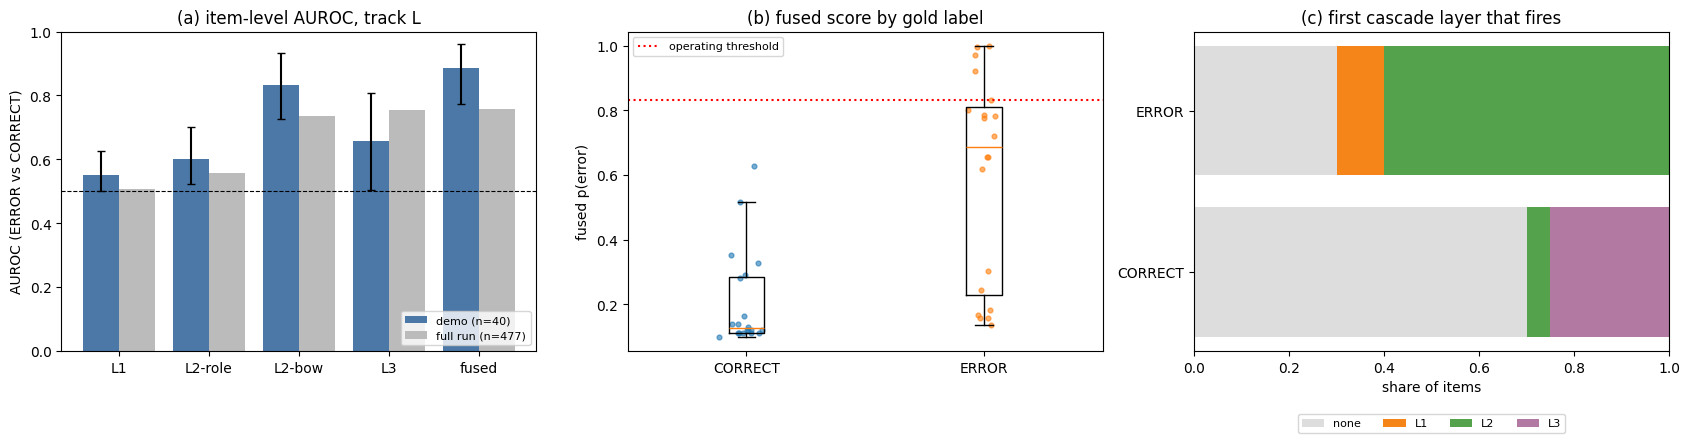

A few scored track-L items (label joined only now):

[ERROR] p_err=1.00  fired=L1  code=BIND  L1=['FREE']  role=[]  unanchored=['Taller']
  TEXT: Peter is shorter than a man in Michael's class.
  FOL : ¬Taller(peter, x) ∧ ∃x (Class(x, michael) ∧ Man(x))

[ERROR] p_err=1.00  fired=L1  code=BIND  L1=['FREE']  role=[]  unanchored=['Win']
  TEXT: The United States won the most medals in Tokyo.
  FOL : Win(unitedStates, x) ∧ Tokyo(x) ∧ Medals(x)

[ERROR] p_err=0.97  fired=L2  code=DROP  L1=[]  role=[]  unanchored=[]
  TEXT: All shows portraying the lives of real people are reality TV shows.
  FOL : ∀x (Real(x) → Reality(x))

[CORRECT] p_err=0.10  fired=none  code=None  L1=[]  role=[]  unanchored=[]
  TEXT: KiKi is terricolous.
  FOL : Terricolous(kiki)

[CORRECT] p_err=0.11  fired=none  code=None  L1=[]  role=[]  unanchored=[]
  TEXT: Some affection is positive.
  FOL : ∃x (Affection(x) ∧ Positive(x))


In [34]:
per_item = [json.loads(l) for l in (RES / "per_item.jsonl").read_text().splitlines() if l.strip()]
Lr = [s for s in per_item if s["track"] == "L" and s["label"] in ("ERROR", "CORRECT")]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
# (a) AUROC per layer, demo vs full run
ax = axes[0]
order = ["l1_any", "l2_role", "l2_bow", "l3_score", "p_fused_H"]
rp = {n: (a, lo, hi) for n, a, lo, hi in rows_plot}
xs = np.arange(len(order))
demo = [rp.get(n, (np.nan, None, None))[0] for n in order]
err = [[(rp[n][0] - rp[n][1]) if n in rp and rp[n][1] is not None else 0 for n in order],
       [(rp[n][2] - rp[n][0]) if n in rp and rp[n][2] is not None else 0 for n in order]]
ax.bar(xs - 0.2, demo, 0.4, yerr=err, capsize=3, color="#4C78A8", label=f"demo (n={ev['n']})")
ax.bar(xs + 0.2, [FULL_RUN[n] for n in order], 0.4, color="#BBBBBB", label="full run (n=477)")
ax.axhline(0.5, ls="--", c="k", lw=0.8)
ax.set_xticks(xs); ax.set_xticklabels(["L1", "L2-role", "L2-bow", "L3", "fused"])
ax.set_ylim(0, 1); ax.set_ylabel("AUROC (ERROR vs CORRECT)"); ax.set_title("(a) item-level AUROC, track L")
ax.legend(loc="lower right", fontsize=8)

# (b) fused p_error by label
ax = axes[1]
pe = [s["p_fused_H"] for s in Lr if s["label"] == "ERROR" and s.get("parse_ok") and s.get("cpu_status") == "OK"]
pc = [s["p_fused_H"] for s in Lr if s["label"] == "CORRECT" and s.get("parse_ok") and s.get("cpu_status") == "OK"]
ax.boxplot([pc, pe], showfliers=False)
for i, v in enumerate([pc, pe]):
    ax.scatter(np.random.default_rng(i).normal(i + 1, 0.05, len(v)), v, s=12, alpha=0.6)
ax.set_xticks([1, 2]); ax.set_xticklabels(["CORRECT", "ERROR"])
ax.axhline(M["calibration"]["fused_threshold_noleak_OOF_10pctFA"], ls=":", c="r", label="operating threshold")
ax.set_ylabel("fused p(error)"); ax.set_title("(b) fused score by gold label"); ax.legend(fontsize=8)

# (c) which layer fired first, by label
ax = axes[2]
layers = ["none", "L1", "L2", "L3"]
for j, lab in enumerate(["CORRECT", "ERROR"]):
    c = Counter(s["fired_layer"] for s in Lr if s["label"] == lab)
    tot = sum(c[l] for l in layers) or 1
    left = 0
    for l, col in zip(layers, ["#DDDDDD", "#F58518", "#54A24B", "#B279A2"]):
        ax.barh(j, c[l] / tot, left=left, color=col, label=l if j == 0 else None)
        left += c[l] / tot
ax.set_yticks([0, 1]); ax.set_yticklabels(["CORRECT", "ERROR"]); ax.set_xlabel("share of items")
ax.set_title("(c) first cascade layer that fires"); ax.legend(ncol=4, fontsize=8, loc="upper center",
                                                            bbox_to_anchor=(0.5, -0.18))
plt.tight_layout(); plt.show()

print("A few scored track-L items (label joined only now):")
for s in sorted(Lr, key=lambda s: -s["p_fused_H"])[:3] + sorted(Lr, key=lambda s: s["p_fused_H"])[:2]:
    print(f"\n[{s['label']}] p_err={s['p_fused_H']:.2f}  fired={s['fired_layer']}  code={s['error_code']}  "
          f"L1={s.get('l1_codes')}  role={s.get('role_codes')}  unanchored={s.get('bow_unanchored')}")
    print("  TEXT:", s["text"]); print("  FOL :", s["candidate_fol"])